In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

def list_directory_tree(root_path, max_files_per_dir=3, indent=""):
    """
    Recursively prints the directory structure starting from root_path.
    Shows only up to `max_files_per_dir` files per directory.
    """
    try:
        # Get all entries in the directory
        entries = sorted(os.listdir(root_path))
    except FileNotFoundError:
        print(f"Error: Directory '{root_path}' not found.")
        return
    except PermissionError:
        print(f"Error: Permission denied for '{root_path}'.")
        return

    # Separate directories and files
    dirs = [d for d in entries if os.path.isdir(os.path.join(root_path, d))]
    files = [f for f in entries if os.path.isfile(os.path.join(root_path, f))]

    # Print directories first
    for d in dirs:
        print(f"{indent}📁 {d}/")
        list_directory_tree(os.path.join(root_path, d), max_files_per_dir, indent + "    ")

    # Print only a few files
    for f in files[:max_files_per_dir]:
        print(f"{indent}📄 {f}")

    # Indicate if there are more files
    if len(files) > max_files_per_dir:
        print(f"{indent}... ({len(files) - max_files_per_dir} more files)")

if __name__ == "__main__":
    # Example usage
    path = input("Enter directory path: ").strip()
    if not os.path.isdir(path):
        print("Invalid directory path.")
    else:
        list_directory_tree(path, max_files_per_dir=3)


Enter directory path: /content/drive/MyDrive/ParkinsonDataset/Module 2
📁 00_dataset_analysis/
    📄 youtube_complete_metadata.csv
    📄 youtube_dataset_report.json
    📄 youtube_metadata.csv
📁 01_preprocessing/
    📄 preprocessing_config.json
    📄 preprocessing_verification.json
    📄 video_decoding_verification.csv
📁 02_splits/
    📄 METHODOLOGY_NOTE.txt
    📄 all_splits.csv
    📄 split_config.json
    ... (5 more files)
📁 03_features/
    📁 audio/
    📁 video/
📁 03_step1_videoswin_ast_crossattention_softmax/
    📁 .ipynb_checkpoints/
    📄 best_model.pt
    📄 step1_results.json
    📄 training_history.csv
📁 04_model/
📁 04_models/
📁 04_step2_first_run_reproduction/
    📄 best_fusion_model_first_run_reproduction.pt
    📄 best_xgboost_model_first_run_reproduction.json
    📄 confusion_matrices.png
    ... (5 more files)
📁 04_step2_optuna_optimized/
    📁 cached_features/
        📄 test_features.pt
        📄 train_features.pt
        📄 validation_features.pt
    📁 models/
    📁 optuna/
  

#Preprocessing

In [ ]:
!pip -q install transformers librosa soundfile torchvision

In [ ]:
import torch
import torchvision
import transformers
import librosa
import cv2

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Librosa     :", librosa.__version__)
print("OpenCV      :", cv2.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ENVIRONMENT
PyTorch     : 2.11.0+cpu
Torchvision : 0.26.0+cpu
Transformers: 5.15.0
Librosa     : 0.11.0
OpenCV      : 5.0.0

CUDA available: False


In [ ]:
from pathlib import Path
import json

# ============================================================
# MODULE 2 PATHS
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/ParkinsonDataset"
)

MODULE2_DIR = BASE_DIR / "Module 2"

SPLIT_DIR = MODULE2_DIR / "02_splits"

PREPROCESS_DIR = MODULE2_DIR / "01_preprocessing"

PREPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# VIDEO CONFIGURATION
# ============================================================

NUM_FRAMES = 32

IMAGE_SIZE = 224

VIDEO_CHANNELS = 3


# ============================================================
# AUDIO CONFIGURATION
# ============================================================

AUDIO_SAMPLE_RATE = 16000

AUDIO_CHANNELS = 1

N_MELS = 128

N_FFT = 1024

HOP_LENGTH = 512

# AST commonly works with approximately 10-second
# audio segments in this experiment.

AUDIO_DURATION = 10.0

AUDIO_NUM_SAMPLES = int(
    AUDIO_SAMPLE_RATE * AUDIO_DURATION
)


# ============================================================
# NORMALIZATION
# ============================================================

VIDEO_MEAN = [
    0.485,
    0.456,
    0.406
]

VIDEO_STD = [
    0.229,
    0.224,
    0.225
]


# ============================================================
# REPRODUCIBILITY
# ============================================================

RANDOM_SEED = 42


# ============================================================
# SAVE CONFIGURATION
# ============================================================

preprocessing_config = {

    "video": {

        "num_frames": NUM_FRAMES,

        "image_size": IMAGE_SIZE,

        "channels": VIDEO_CHANNELS,

        "normalization_mean": VIDEO_MEAN,

        "normalization_std": VIDEO_STD
    },

    "audio": {

        "sample_rate": AUDIO_SAMPLE_RATE,

        "channels": AUDIO_CHANNELS,

        "duration_seconds": AUDIO_DURATION,

        "num_samples": AUDIO_NUM_SAMPLES,

        "n_mels": N_MELS,

        "n_fft": N_FFT,

        "hop_length": HOP_LENGTH
    },

    "random_seed": RANDOM_SEED
}


config_path = (
    PREPROCESS_DIR /
    "preprocessing_config.json"
)

with open(config_path, "w") as f:

    json.dump(
        preprocessing_config,
        f,
        indent=4
    )

print("=" * 70)
print("PREPROCESSING CONFIGURATION")
print("=" * 70)

print(json.dumps(
    preprocessing_config,
    indent=4
))

print("\nSaved to:")
print(config_path)

PREPROCESSING CONFIGURATION
{
    "video": {
        "num_frames": 32,
        "image_size": 224,
        "channels": 3,
        "normalization_mean": [
            0.485,
            0.456,
            0.406
        ],
        "normalization_std": [
            0.229,
            0.224,
            0.225
        ]
    },
    "audio": {
        "sample_rate": 16000,
        "channels": 1,
        "duration_seconds": 10.0,
        "num_samples": 160000,
        "n_mels": 128,
        "n_fft": 1024,
        "hop_length": 512
    },
    "random_seed": 42
}

Saved to:
/content/drive/MyDrive/ParkinsonDataset/Module 2/01_preprocessing/preprocessing_config.json


In [ ]:
import cv2
import numpy as np
import torch

from PIL import Image
from torchvision import transforms


# ============================================================
# VIDEO TRANSFORMATION
# ============================================================

video_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=VIDEO_MEAN,
        std=VIDEO_STD
    )
])


# ============================================================
# TEMPORAL SAMPLING
# ============================================================

def sample_frame_indices(
    total_frames,
    num_frames=NUM_FRAMES
):

    if total_frames <= 0:
        raise ValueError(
            "No frames were decoded from the video."
        )

    if total_frames == 1:

        indices = np.zeros(
            num_frames,
            dtype=int
        )

    else:

        indices = np.linspace(
            0,
            total_frames - 1,
            num_frames
        )

        indices = np.round(
            indices
        ).astype(int)

    return indices


# ============================================================
# ROBUST VIDEO LOADER
# ============================================================

def load_video(
    video_path,
    num_frames=NUM_FRAMES
):

    video_path = str(video_path)

    cap = cv2.VideoCapture(
        video_path
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Unable to open video:\n{video_path}"
        )

    frames = []

    # --------------------------------------------------------
    # Sequentially decode the entire video
    # --------------------------------------------------------

    while True:

        success, frame = cap.read()

        if not success:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

    cap.release()

    # --------------------------------------------------------
    # Validate decoded frames
    # --------------------------------------------------------

    total_decoded = len(frames)

    if total_decoded == 0:

        raise RuntimeError(
            f"No frames could be decoded:\n{video_path}"
        )

    # --------------------------------------------------------
    # Uniform temporal sampling
    # --------------------------------------------------------

    frame_indices = sample_frame_indices(
        total_decoded,
        num_frames
    )

    sampled_frames = []

    for idx in frame_indices:

        frame = frames[int(idx)]

        image = Image.fromarray(
            frame
        )

        image = video_transform(
            image
        )

        sampled_frames.append(
            image
        )

    # --------------------------------------------------------
    # Stack
    #
    # [T, C, H, W]
    # --------------------------------------------------------

    video_tensor = torch.stack(
        sampled_frames
    )

    return video_tensor

In [ ]:
problem_video = (
    BASE_DIR
    / "Youtube dataset"
    / "Positive"
    / "clip_114.mp4"
)

print("=" * 70)
print("TESTING PREVIOUSLY FAILED VIDEO")
print("=" * 70)

print("File:")
print(problem_video)

video_test = load_video(
    problem_video
)

print("\n✓ VIDEO SUCCESSFULLY PROCESSED")

print(
    "Tensor shape:",
    video_test.shape
)

print(
    "Tensor dtype:",
    video_test.dtype
)

print(
    "Tensor device:",
    video_test.device
)

TESTING PREVIOUSLY FAILED VIDEO
File:
/content/drive/MyDrive/ParkinsonDataset/Youtube dataset/Positive/clip_114.mp4

✓ VIDEO SUCCESSFULLY PROCESSED
Tensor shape: torch.Size([32, 3, 224, 224])
Tensor dtype: torch.float32
Tensor device: cpu


In [ ]:
# ============================================================
# TEST POSITIVE
# ============================================================

positive_video = load_video(
    positive_sample["path"]
)


# ============================================================
# TEST NEGATIVE
# ============================================================

negative_video = load_video(
    negative_sample["path"]
)


print("=" * 70)
print("VIDEO PREPROCESSING TEST")
print("=" * 70)

print("\nPositive:")
print("File :", positive_sample["filename"])
print("Shape:", positive_video.shape)
print("Dtype:", positive_video.dtype)

print("\nNegative:")
print("File :", negative_sample["filename"])
print("Shape:", negative_video.shape)
print("Dtype:", negative_video.dtype)

VIDEO PREPROCESSING TEST

Positive:
File : clip_114.mp4
Shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32

Negative:
File : clip_027.mp4
Shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32


In [ ]:
from tqdm.auto import tqdm

# ============================================================
# VERIFY ALL YOUTUBE VIDEOS
# ============================================================

verification_results = []

print("=" * 70)
print("SEQUENTIAL VIDEO DECODING VERIFICATION")
print("=" * 70)

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Checking videos"
):

    path = row["path"]

    cap = cv2.VideoCapture(
        str(path)
    )

    decoded_frames = 0

    if cap.isOpened():

        while True:

            success, frame = cap.read()

            if not success:
                break

            decoded_frames += 1

    cap.release()

    verification_results.append({

        "video_id":
            row["video_id"],

        "filename":
            row["filename"],

        "class":
            row["class"],

        "metadata_frame_count":
            row["frame_count"],

        "decoded_frame_count":
            decoded_frames,

        "decode_success":
            decoded_frames > 0
    })


decode_df = pd.DataFrame(
    verification_results
)


print("\n" + "=" * 70)
print("DECODING VERIFICATION COMPLETE")
print("=" * 70)

print(
    "Videos checked:",
    len(decode_df)
)

print(
    "Videos successfully decoded:",
    decode_df["decode_success"].sum()
)

print(
    "Videos with zero decoded frames:",
    (~decode_df["decode_success"]).sum()
)

SEQUENTIAL VIDEO DECODING VERIFICATION


Checking videos:   0%|          | 0/117 [00:00<?, ?it/s]


DECODING VERIFICATION COMPLETE
Videos checked: 117
Videos successfully decoded: 117
Videos with zero decoded frames: 0


In [ ]:
decode_df["frame_difference"] = (
    decode_df["metadata_frame_count"]
    -
    decode_df["decoded_frame_count"]
)

discrepancies = decode_df[
    decode_df["frame_difference"] != 0
]

print("=" * 70)
print("FRAME COUNT DISCREPANCY CHECK")
print("=" * 70)

print(
    "Videos with frame-count discrepancy:",
    len(discrepancies)
)

if len(discrepancies) > 0:

    display(
        discrepancies[
            [
                "filename",
                "class",
                "metadata_frame_count",
                "decoded_frame_count",
                "frame_difference"
            ]
        ].head(20)
    )

else:

    print(
        "\n✓ No frame-count discrepancies found."
    )

FRAME COUNT DISCREPANCY CHECK
Videos with frame-count discrepancy: 112


,filename,class,metadata_frame_count,decoded_frame_count,frame_difference
0,clip_005.mp4,Negative,384,301,83
1,clip_006.mp4,Negative,428,300,128
2,clip_007.mp4,Negative,279,251,28
3,clip_008.mp4,Negative,338,301,37
4,clip_009.mp4,Negative,433,301,132
5,clip_010.mp4,Negative,349,251,98
6,clip_011.mp4,Negative,417,349,68
7,clip_012.mp4,Negative,303,241,62
8,clip_014.mp4,Negative,374,301,73
9,clip_019.mp4,Negative,392,300,92


In [ ]:
decode_report_path = (
    PREPROCESS_DIR /
    "video_decoding_verification.csv"
)

decode_df.to_csv(
    decode_report_path,
    index=False
)

print("=" * 70)
print("DECODING VERIFICATION SAVED")
print("=" * 70)

print(
    decode_report_path
)

DECODING VERIFICATION SAVED
/content/drive/MyDrive/ParkinsonDataset/Module 2/01_preprocessing/video_decoding_verification.csv


In [ ]:
import pandas as pd

TRAIN_PATH = (
    SPLIT_DIR /
    "train.csv"
)

train_df = pd.read_csv(
    TRAIN_PATH
)

positive_sample = train_df[
    train_df["label"] == 1
].iloc[0]

negative_sample = train_df[
    train_df["label"] == 0
].iloc[0]


# ============================================================
# TEST POSITIVE
# ============================================================

positive_video = load_video(
    positive_sample["path"]
)

# ============================================================
# TEST NEGATIVE
# ============================================================

negative_video = load_video(
    negative_sample["path"]
)


print("=" * 70)
print("VIDEO PREPROCESSING TEST")
print("=" * 70)

print(
    "\nPositive video:",
    positive_sample["filename"]
)

print(
    "Tensor shape:",
    positive_video.shape
)

print(
    "Tensor dtype:",
    positive_video.dtype
)

print(
    "Tensor min:",
    positive_video.min().item()
)

print(
    "Tensor max:",
    positive_video.max().item()
)

print(
    "\nNegative video:",
    negative_sample["filename"]
)

print(
    "Tensor shape:",
    negative_video.shape
)

VIDEO PREPROCESSING TEST

Positive video: clip_114.mp4
Tensor shape: torch.Size([32, 3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -2.1179039478302
Tensor max: 2.640000104904175

Negative video: clip_027.mp4
Tensor shape: torch.Size([32, 3, 224, 224])


Audio Extraction

In [ ]:
import librosa
import numpy as np
import torch


# ============================================================
# LOAD AUDIO
# ============================================================

def load_audio(
    video_path,
    sample_rate=AUDIO_SAMPLE_RATE,
    duration=AUDIO_DURATION
):

    audio, sr = librosa.load(
        str(video_path),
        sr=sample_rate,
        mono=True,
        duration=duration
    )

    target_length = int(
        sample_rate * duration
    )

    # --------------------------------------------------------
    # Padding
    # --------------------------------------------------------

    if len(audio) < target_length:

        audio = np.pad(
            audio,
            (
                0,
                target_length - len(audio)
            ),
            mode="constant"
        )

    # --------------------------------------------------------
    # Truncation
    # --------------------------------------------------------

    elif len(audio) > target_length:

        audio = audio[
            :target_length
        ]

    audio = torch.tensor(
        audio,
        dtype=torch.float32
    )

    return audio

In [ ]:
positive_audio = load_audio(
    positive_sample["path"]
)

negative_audio = load_audio(
    negative_sample["path"]
)


print("=" * 70)
print("AUDIO PREPROCESSING TEST")
print("=" * 70)

print(
    "\nPositive audio:"
)

print(
    "Shape:",
    positive_audio.shape
)

print(
    "dtype:",
    positive_audio.dtype
)

print(
    "Expected samples:",
    AUDIO_NUM_SAMPLES
)

print(
    "\nNegative audio:"
)

print(
    "Shape:",
    negative_audio.shape
)

/tmp/ipykernel_1167/306092591.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


AUDIO PREPROCESSING TEST

Positive audio:
Shape: torch.Size([160000])
dtype: torch.float32
Expected samples: 160000

Negative audio:
Shape: torch.Size([160000])


/tmp/ipykernel_1167/306092591.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
def audio_to_logmel(
    audio,
    sample_rate=AUDIO_SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
):

    # Convert tensor → NumPy

    audio_np = audio.numpy()

    # --------------------------------------------------------
    # Mel spectrogram
    # --------------------------------------------------------

    mel = librosa.feature.melspectrogram(

        y=audio_np,

        sr=sample_rate,

        n_fft=n_fft,

        hop_length=hop_length,

        n_mels=n_mels,

        power=2.0
    )

    # --------------------------------------------------------
    # Convert power → decibels
    # --------------------------------------------------------

    logmel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # --------------------------------------------------------
    # Tensor
    # --------------------------------------------------------

    logmel = torch.tensor(
        logmel,
        dtype=torch.float32
    )

    return logmel

In [ ]:
positive_logmel = audio_to_logmel(
    positive_audio
)

negative_logmel = audio_to_logmel(
    negative_audio
)


print("=" * 70)
print("LOG-MEL SPECTROGRAM TEST")
print("=" * 70)

print(
    "\nPositive:"
)

print(
    "Shape:",
    positive_logmel.shape
)

print(
    "dtype:",
    positive_logmel.dtype
)

print(
    "Min:",
    positive_logmel.min().item()
)

print(
    "Max:",
    positive_logmel.max().item()
)

print(
    "\nNegative:"
)

print(
    "Shape:",
    negative_logmel.shape
)

LOG-MEL SPECTROGRAM TEST

Positive:
Shape: torch.Size([128, 313])
dtype: torch.float32
Min: -80.0
Max: 0.0

Negative:
Shape: torch.Size([128, 313])


In [ ]:
# ============================================================
# COMPLETE SAMPLE
# ============================================================

video_tensor = positive_video

audio_tensor = positive_audio

logmel_tensor = positive_logmel

label = torch.tensor(
    positive_sample["label"],
    dtype=torch.long
)


print("=" * 70)
print("COMPLETE MULTIMODAL SAMPLE")
print("=" * 70)

print(
    "\nFilename:",
    positive_sample["filename"]
)

print(
    "Label:",
    label.item()
)

print(
    "Video tensor:",
    video_tensor.shape
)

print(
    "Audio waveform:",
    audio_tensor.shape
)

print(
    "Log-Mel:",
    logmel_tensor.shape
)

COMPLETE MULTIMODAL SAMPLE

Filename: clip_114.mp4
Label: 1
Video tensor: torch.Size([32, 3, 224, 224])
Audio waveform: torch.Size([160000])
Log-Mel: torch.Size([128, 313])


In [ ]:
verification_report = {

    "video": {

        "shape":
            list(video_tensor.shape),

        "dtype":
            str(video_tensor.dtype),

        "num_frames":
            NUM_FRAMES,

        "channels":
            VIDEO_CHANNELS,

        "height":
            IMAGE_SIZE,

        "width":
            IMAGE_SIZE
    },

    "audio": {

        "waveform_shape":
            list(audio_tensor.shape),

        "sample_rate":
            AUDIO_SAMPLE_RATE,

        "duration_seconds":
            AUDIO_DURATION,

        "channels":
            AUDIO_CHANNELS
    },

    "log_mel": {

        "shape":
            list(logmel_tensor.shape),

        "n_mels":
            N_MELS,

        "n_fft":
            N_FFT,

        "hop_length":
            HOP_LENGTH
    },

    "label":
        int(label.item()),

    "status":
        "PASS"
}


verification_path = (
    PREPROCESS_DIR /
    "preprocessing_verification.json"
)

with open(
    verification_path,
    "w"
) as f:

    json.dump(
        verification_report,
        f,
        indent=4
    )


print("=" * 70)
print("PREPROCESSING VERIFICATION SAVED")
print("=" * 70)

print(
    verification_path
)

print("\nSTATUS: ✓ PASS")

PREPROCESSING VERIFICATION SAVED
/content/drive/MyDrive/ParkinsonDataset/Module 2/01_preprocessing/preprocessing_verification.json

STATUS: ✓ PASS


---

In [ ]:
import torch

print("=" * 70)
print("DEVICE CHECK")
print("=" * 70)

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

    print("CUDA available: True")
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

else:

    DEVICE = torch.device("cpu")

    print("CUDA available: False")
    print("Using CPU")

print("\nSelected device:", DEVICE)

DEVICE CHECK
CUDA available: False
Using CPU

Selected device: cpu


In [ ]:
!pip -q install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 113.3 MB/s eta 0:00:00


In [ ]:
import transformers

print("=" * 70)
print("SEARCHING TRANSFORMERS FOR SWIN IMPLEMENTATIONS")
print("=" * 70)

modules = [
    x for x in dir(transformers)
    if "Swin" in x or "swin" in x
]

for x in modules:
    print(x)

print("\nTotal matches:", len(modules))

SEARCHING TRANSFORMERS FOR SWIN IMPLEMENTATIONS
DonutSwinConfig
DonutSwinForImageClassification
DonutSwinModel
DonutSwinPreTrainedModel
MaskFormerSwinBackbone
MaskFormerSwinConfig
MaskFormerSwinModel
MaskFormerSwinPreTrainedModel
Swin2SRConfig
Swin2SRForImageSuperResolution
Swin2SRImageProcessor
Swin2SRImageProcessorPil
Swin2SRModel
Swin2SRPreTrainedModel
SwinBackbone
SwinConfig
SwinForImageClassification
SwinForMaskedImageModeling
SwinModel
SwinPreTrainedModel
Swinv2Backbone
Swinv2Config
Swinv2ForImageClassification
Swinv2ForMaskedImageModeling
Swinv2Model
Swinv2PreTrainedModel
image_processing_pil_swin2sr_fast
image_processing_swin2sr_fast
models.donut.configuration_donut_swin
models.donut.modeling_donut_swin
models.maskformer.configuration_maskformer_swin
models.maskformer.modeling_maskformer_swin
models.swin
models.swin.configuration_swin
models.swin.modeling_swin
models.swin2sr
models.swin2sr.configuration_swin2sr
models.swin2sr.image_processing_pil_swin2sr
models.swin2sr.image_pr

In [ ]:
!pip install -q -U transformers

In [ ]:
import transformers

print(
    "Transformers version:",
    transformers.__version__
)

print(
    "Transformers path:",
    transformers.__file__
)

Transformers version: 5.15.1
Transformers path: /usr/local/lib/python3.13/dist-packages/transformers/__init__.py


In [ ]:
print("=" * 70)
print("VIDEO SWIN AVAILABILITY TEST")
print("=" * 70)

try:

    from transformers import VideoSwinModel

    print("✓ VideoSwinModel imported successfully")

except Exception as e:

    print("✗ VideoSwinModel still unavailable")

    print(
        "Error:",
        repr(e)
    )

VIDEO SWIN AVAILABILITY TEST
✗ VideoSwinModel still unavailable
Error: ImportError("cannot import name 'VideoSwinModel' from 'transformers' (/usr/local/lib/python3.13/dist-packages/transformers/__init__.py)")


In [ ]:
!nvidia-smi


Thu Sep  3 14:08:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("=" * 70)
print("PYTORCH GPU CHECK")
print("=" * 70)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "CUDA version:",
        torch.version.cuda
    )

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

else:

    print("WARNING: CUDA is NOT available.")

PYTORCH GPU CHECK
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4
GPU memory: 14.56 GB


In [ ]:
import torchvision

print("=" * 70)
print("TORCHVISION CHECK")
print("=" * 70)

print("Torchvision:", torchvision.__version__)

print("\nAvailable video models:")

import torchvision.models.video as video_models

for name in dir(video_models):

    if not name.startswith("_"):

        print(name)

TORCHVISION CHECK
Torchvision: 0.26.0+cu128

Available video models:
MC3_18_Weights
MViT
MViT_V1_B_Weights
MViT_V2_S_Weights
R2Plus1D_18_Weights
R3D_18_Weights
S3D
S3D_Weights
Swin3D_B_Weights
Swin3D_S_Weights
Swin3D_T_Weights
SwinTransformer3d
VideoResNet
mc3_18
mvit
mvit_v1_b
mvit_v2_s
r2plus1d_18
r3d_18
resnet
s3d
swin3d_b
swin3d_s
swin3d_t
swin_transformer


In [ ]:
# ============================================================
# MODULE 2 — ENVIRONMENT RECONSTRUCTION
# ============================================================

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import torch
import torchvision

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# Base paths
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/drive/MyDrive/ParkinsonDataset"
)

MODULE2_DIR = BASE_DIR / "Module 2"

DATASET_ANALYSIS_DIR = (
    MODULE2_DIR / "00_dataset_analysis"
)

PREPROCESS_DIR = (
    MODULE2_DIR / "01_preprocessing"
)

SPLIT_DIR = (
    MODULE2_DIR / "02_splits"
)

FEATURE_DIR = (
    MODULE2_DIR / "03_features"
)

MODEL_DIR = (
    MODULE2_DIR / "04_model"
)

TRAINING_DIR = (
    MODULE2_DIR / "05_training"
)

EVALUATION_DIR = (
    MODULE2_DIR / "06_evaluation"
)

RESULTS_DIR = (
    MODULE2_DIR / "07_results"
)

LOG_DIR = (
    MODULE2_DIR / "08_logs"
)


# ------------------------------------------------------------
# Create directories
# ------------------------------------------------------------

for directory in [
    FEATURE_DIR,
    MODEL_DIR,
    TRAINING_DIR,
    EVALUATION_DIR,
    RESULTS_DIR,
    LOG_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Video configuration
# ------------------------------------------------------------

NUM_FRAMES = 32

IMAGE_SIZE = 224

VIDEO_CHANNELS = 3

VIDEO_MEAN = [
    0.485,
    0.456,
    0.406
]

VIDEO_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------------------------------------
# Audio configuration
# ------------------------------------------------------------

AUDIO_SAMPLE_RATE = 16000

AUDIO_DURATION = 10.0

AUDIO_NUM_SAMPLES = int(
    AUDIO_SAMPLE_RATE * AUDIO_DURATION
)

N_MELS = 128

N_FFT = 1024

HOP_LENGTH = 512


# ------------------------------------------------------------
# Print environment
# ------------------------------------------------------------

print("=" * 70)
print("MODULE 2 ENVIRONMENT RECONSTRUCTED")
print("=" * 70)

print("Device          :", DEVICE)
print("PyTorch         :", torch.__version__)
print("Torchvision     :", torchvision.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory      :",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

print("\nModule 2:")
print(MODULE2_DIR)

MODULE 2 ENVIRONMENT RECONSTRUCTED
Device          : cuda
PyTorch         : 2.11.0+cu128
Torchvision     : 0.26.0+cu128
CUDA available  : True
GPU             : Tesla T4
GPU memory      : 14.56 GB

Module 2:
/content/drive/MyDrive/ParkinsonDataset/Module 2


In [ ]:
# ============================================================
# LOAD DATASET METADATA
# ============================================================

METADATA_PATH = (
    DATASET_ANALYSIS_DIR /
    "youtube_complete_metadata.csv"
)

df = pd.read_csv(
    METADATA_PATH
)

print("=" * 70)
print("YOUTUBE METADATA RELOADED")
print("=" * 70)

print("Total videos:", len(df))

print("\nClass distribution:")
print(
    df["class"].value_counts()
)

print("\nAudio:")
print(
    df["has_audio"].value_counts()
)

print("\nReadable:")
print(
    df["video_readable"].value_counts()
)

print("\nColumns:")
print(
    list(df.columns)
)

YOUTUBE METADATA RELOADED
Total videos: 117

Class distribution:
class
Positive    66
Negative    51
Name: count, dtype: int64

Audio:
has_audio
True    117
Name: count, dtype: int64

Readable:
video_readable
True    117
Name: count, dtype: int64

Columns:
['video_id', 'filename', 'path', 'label', 'class', 'dataset', 'video_readable', 'fps', 'frame_count', 'duration_sec', 'width', 'height', 'has_audio', 'audio_codec', 'audio_sample_rate', 'audio_channels', 'audio_duration_sec']


In [ ]:
print("=" * 70)
print("SPLIT FILES")
print("=" * 70)

for file in sorted(SPLIT_DIR.glob("*")):

    print(file.name)

SPLIT FILES
METHODOLOGY_NOTE.txt
all_splits.csv
split_config.json
split_report.json
split_summary.csv
test.csv
train.csv
validation.csv


In [ ]:
TRAIN_PATH = SPLIT_DIR / "train.csv"
VAL_PATH = SPLIT_DIR / "validation.csv"
TEST_PATH = SPLIT_DIR / "test.csv"

train_df = pd.read_csv(
    TRAIN_PATH
)

val_df = pd.read_csv(
    VAL_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)

print("=" * 70)
print("DATA SPLITS")
print("=" * 70)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

DATA SPLITS
Train: 81
Validation: 18
Test: 18

Train labels:
label
1    46
0    35
Name: count, dtype: int64

Validation labels:
label
1    10
0     8
Name: count, dtype: int64

Test labels:
label
1    10
0     8
Name: count, dtype: int64


In [ ]:
import cv2
from PIL import Image
from torchvision import transforms


# ============================================================
# VIDEO TRANSFORMATION
# ============================================================

video_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=VIDEO_MEAN,
        std=VIDEO_STD
    )
])


# ============================================================
# FRAME SAMPLING
# ============================================================

def sample_frame_indices(
    total_frames,
    num_frames=NUM_FRAMES
):

    if total_frames <= 0:

        raise ValueError(
            "No frames available."
        )

    if total_frames == 1:

        return np.zeros(
            num_frames,
            dtype=int
        )

    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    )

    return np.round(
        indices
    ).astype(int)


# ============================================================
# ROBUST VIDEO LOADER
# ============================================================

def load_video(
    video_path,
    num_frames=NUM_FRAMES
):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Unable to open video:\n{video_path}"
        )

    frames = []

    while True:

        success, frame = cap.read()

        if not success:
            break

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

    cap.release()

    if len(frames) == 0:

        raise RuntimeError(
            f"No frames decoded:\n{video_path}"
        )

    indices = sample_frame_indices(
        len(frames),
        num_frames
    )

    sampled = []

    for idx in indices:

        image = Image.fromarray(
            frames[int(idx)]
        )

        image = video_transform(
            image
        )

        sampled.append(
            image
        )

    return torch.stack(
        sampled
    )

In [ ]:
problem_video = (
    BASE_DIR
    / "Youtube dataset"
    / "Positive"
    / "clip_114.mp4"
)

test_video = load_video(
    problem_video
)

print("=" * 70)
print("VIDEO PREPROCESSING TEST")
print("=" * 70)

print(
    "File:",
    problem_video.name
)

print(
    "Shape:",
    test_video.shape
)

print(
    "Dtype:",
    test_video.dtype
)

VIDEO PREPROCESSING TEST
File: clip_114.mp4
Shape: torch.Size([32, 3, 224, 224])
Dtype: torch.float32


In [ ]:
torchvision.models.video.swin3d_t

<function torchvision.models.video.swin_transformer.swin3d_t(*, weights: Optional[torchvision.models.video.swin_transformer.Swin3D_T_Weights] = None, progress: bool = True, **kwargs: Any) -> torchvision.models.video.swin_transformer.SwinTransformer3d>

In [ ]:
from torchvision.models.video import (
    swin3d_t,
    Swin3D_T_Weights
)

print("=" * 70)
print("VIDEO SWIN 3D — TINY")
print("=" * 70)

VIDEO_WEIGHTS = (
    Swin3D_T_Weights.DEFAULT
)

print(
    "Weights:",
    VIDEO_WEIGHTS
)

VIDEO SWIN 3D — TINY
Weights: Swin3D_T_Weights.KINETICS400_V1


In [ ]:
video_swin = swin3d_t(
    weights=VIDEO_WEIGHTS
)

video_swin = video_swin.to(
    DEVICE
)

video_swin.eval()

print("=" * 70)
print("VIDEO SWIN LOADED")
print("=" * 70)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in video_swin.parameters()
    )
)

print(
    "Device:",
    next(
        video_swin.parameters()
    ).device
)

Downloading: "https://download.pytorch.org/models/swin3d_t-7615ae03.pth" to /root/.cache/torch/hub/checkpoints/swin3d_t-7615ae03.pth


100%|██████████| 122M/122M [00:00<00:00, 233MB/s]


VIDEO SWIN LOADED
Parameters: 28158070
Device: cuda:0


In [ ]:
print(
    video_swin.head
    )

Identity()


In [ ]:
print(video_swin)

SwinTransformer3d(
  (patch_embed): PatchEmbed3d(
    (proj): Conv3d(3, 96, kernel_size=(2, 4, 4), stride=(2, 4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (features): Sequential(
    (0): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention3d(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
     

In [ ]:
import torch.nn as nn

# Save the input dimension of the original classifier
VIDEO_FEATURE_DIM = (
    video_swin.head.in_features
)

print(
    "Video Swin feature dimension:",
    VIDEO_FEATURE_DIM
)

# Remove classification head
video_swin.head = nn.Identity()

print(
    "New head:",
    video_swin.head
)

Video Swin feature dimension: 768
New head: Identity()


In [ ]:
# ============================================================
# PREPARE SINGLE VIDEO
# ============================================================

video_input = test_video.unsqueeze(0)

video_input = video_input.to(
    DEVICE
)

print(
    "Input shape:",
    video_input.shape
)

print(
    "Input device:",
    video_input.device
)

Input shape: torch.Size([1, 32, 3, 224, 224])
Input device: cuda:0


In [ ]:
video_input = test_video.permute(
    1, 0, 2, 3
).unsqueeze(0)

video_input = video_input.to(
    DEVICE
)

print(
    "Video input shape:",
    video_input.shape
)

print(
    "Video input device:",
    video_input.device
)

Video input shape: torch.Size([1, 3, 32, 224, 224])
Video input device: cuda:0


In [ ]:
with torch.inference_mode():

    video_features = video_swin(
        video_input
    )

print("=" * 70)
print("VIDEO SWIN FORWARD PASS")
print("=" * 70)

print(
    "Output shape:",
    video_features.shape
)

print(
    "Output dtype:",
    video_features.dtype
)

print(
    "Output device:",
    video_features.device
)

VIDEO SWIN FORWARD PASS
Output shape: torch.Size([1, 768])
Output dtype: torch.float32
Output device: cuda:0


In [ ]:
# ============================================================
# STEP 9.1 — INSPECT SWIN3D FEATURE MAP
# ============================================================

video_swin.eval()

with torch.inference_mode():

    x = video_input

    # Patch embedding
    x = video_swin.patch_embed(x)

    print("After patch embedding:")
    print(x.shape)

    # Positional dropout
    x = video_swin.pos_drop(x)

    # Swin stages
    for stage_idx, stage in enumerate(
        video_swin.features
    ):

        x = stage(x)

        print(
            f"After feature stage {stage_idx}:",
            x.shape
        )

    # Final normalization
    x = video_swin.norm(x)

    print(
        "After final normalization:",
        x.shape
    )

After patch embedding:
torch.Size([1, 16, 56, 56, 96])
After feature stage 0: torch.Size([1, 16, 56, 56, 96])
After feature stage 1: torch.Size([1, 16, 28, 28, 192])
After feature stage 2: torch.Size([1, 16, 28, 28, 192])
After feature stage 3: torch.Size([1, 16, 14, 14, 384])
After feature stage 4: torch.Size([1, 16, 14, 14, 384])
After feature stage 5: torch.Size([1, 16, 7, 7, 768])
After feature stage 6: torch.Size([1, 16, 7, 7, 768])
After final normalization: torch.Size([1, 16, 7, 7, 768])


In [ ]:
# ============================================================
# STEP 9.2 — CONVERT VIDEO FEATURE MAP TO TOKENS
# ============================================================

with torch.inference_mode():

    x = video_swin.patch_embed(
        video_input
    )

    x = video_swin.pos_drop(x)

    for stage in video_swin.features:

        x = stage(x)

    x = video_swin.norm(x)

    print("Feature map:", x.shape)

    # Flatten all spatial/temporal locations
    video_tokens = x.flatten(
        1,
        -2
    )

    print(
        "Video tokens:",
        video_tokens.shape
    )

Feature map: torch.Size([1, 16, 7, 7, 768])
Video tokens: torch.Size([1, 784, 768])


AST

In [ ]:
# ============================================================
# AST DEPENDENCIES
# ============================================================

import transformers
import torchaudio

print("=" * 70)
print("AST ENVIRONMENT CHECK")
print("=" * 70)

print("Transformers :", transformers.__version__)
print("TorchAudio   :", torchaudio.__version__)
print("CUDA         :", torch.cuda.is_available())

AST ENVIRONMENT CHECK
Transformers : 5.15.0
TorchAudio   : 2.11.0+cu128
CUDA         : True


In [ ]:
# ============================================================
# CHECK AST
# ============================================================

from transformers import (
    ASTModel,
    ASTConfig
)

print("=" * 70)
print("AST AVAILABLE")
print("=" * 70)

print("ASTModel:", ASTModel)
print("ASTConfig:", ASTConfig)

AST AVAILABLE
ASTModel: <class 'transformers.models.audio_spectrogram_transformer.modeling_audio_spectrogram_transformer.ASTModel'>
ASTConfig: <class 'transformers.models.audio_spectrogram_transformer.configuration_audio_spectrogram_transformer.ASTConfig'>


In [ ]:
# ============================================================
# STEP 10.3 — LOAD PRETRAINED AST
# ============================================================

from transformers import ASTModel

AST_CHECKPOINT = (
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

print("=" * 70)
print("LOADING AUDIO SPECTROGRAM TRANSFORMER")
print("=" * 70)

ast_model = ASTModel.from_pretrained(
    AST_CHECKPOINT
)

ast_model = ast_model.to(
    DEVICE
)

ast_model.eval()

print("\nAST loaded successfully.")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in ast_model.parameters()
    )
)

print(
    "Device:",
    next(
        ast_model.parameters()
    ).device
)

LOADING AUDIO SPECTROGRAM TRANSFORMER


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



AST loaded successfully.
Parameters: 86187264
Device: cuda:0


In [ ]:
# ============================================================
# STEP 10.4 — EXTRACT AUDIO
# ============================================================

import torchaudio

def load_audio(
    video_path,
    sample_rate=AUDIO_SAMPLE_RATE,
    duration=AUDIO_DURATION
):

    waveform, original_sr = torchaudio.load(
        str(video_path)
    )

    # Convert to mono
    if waveform.shape[0] > 1:

        waveform = waveform.mean(
            dim=0,
            keepdim=True
        )

    # Resample if necessary
    if original_sr != sample_rate:

        resampler = torchaudio.transforms.Resample(
            orig_freq=original_sr,
            new_freq=sample_rate
        )

        waveform = resampler(
            waveform
        )

    # Exactly 10 seconds
    target_length = int(
        sample_rate * duration
    )

    if waveform.shape[1] >= target_length:

        waveform = waveform[
            :, :target_length
        ]

    else:

        padding = (
            target_length
            - waveform.shape[1]
        )

        waveform = torch.nn.functional.pad(
            waveform,
            (0, padding)
        )

    return waveform.squeeze(0)

In [ ]:
audio_waveform = load_audio(
    problem_video
)

print("=" * 70)
print("AUDIO TEST")
print("=" * 70)

print(
    "Shape:",
    audio_waveform.shape
)

print(
    "Duration:",
    audio_waveform.shape[0]
    / AUDIO_SAMPLE_RATE,
    "seconds"
)

print(
    "Sample rate:",
    AUDIO_SAMPLE_RATE
)

print(
    "Dtype:",
    audio_waveform.dtype
)

AUDIO TEST
Shape: torch.Size([160000])
Duration: 10.0 seconds
Sample rate: 16000
Dtype: torch.float32


In [ ]:
# ============================================================
#  AST PROCESSOR
# ============================================================

from transformers import AutoProcessor

ast_processor = AutoProcessor.from_pretrained(
    AST_CHECKPOINT
)

print("=" * 70)
print("AST PROCESSOR LOADED")
print("=" * 70)

print(
    ast_processor
)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

AST PROCESSOR LOADED
ASTFeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "ASTFeatureExtractor",
  "feature_size": 1,
  "max_length": 1024,
  "mean": -4.2677393,
  "num_mel_bins": 128,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": false,
  "sampling_rate": 16000,
  "std": 4.5689974
}



In [ ]:
# ============================================================
# AST INPUT
# ============================================================

audio_input = ast_processor(
    audio_waveform.numpy(),
    sampling_rate=AUDIO_SAMPLE_RATE,
    return_tensors="pt"
)

print("=" * 70)
print("AST INPUT")
print("=" * 70)

for key, value in audio_input.items():

    print(
        key,
        ":",
        value.shape,
        value.dtype
    )

AST INPUT
input_values : torch.Size([1, 1024, 128]) torch.float32


In [ ]:
# ============================================================
# STEP 10.7 — MOVE AST INPUT TO GPU
# ============================================================

audio_input = {
    key: value.to(DEVICE)
    for key, value in audio_input.items()
}

for key, value in audio_input.items():

    print(
        key,
        ":",
        value.shape,
        value.device
    )

input_values : torch.Size([1, 1024, 128]) cuda:0


In [ ]:
# ============================================================
# STEP 10.8 — AST FORWARD PASS
# ============================================================

with torch.inference_mode():

    ast_output = ast_model(
        **audio_input
    )

print("=" * 70)
print("AST FORWARD PASS")
print("=" * 70)

print(
    "Last hidden state:",
    ast_output.last_hidden_state.shape
)

print(
    "Dtype:",
    ast_output.last_hidden_state.dtype
)

print(
    "Device:",
    ast_output.last_hidden_state.device
)

AST FORWARD PASS
Last hidden state: torch.Size([1, 1214, 768])
Dtype: torch.float32
Device: cuda:0


In [ ]:
# ============================================================
#  FUSION CONFIGURATION
# ============================================================

FUSION_DIM = 512

NUM_HEADS = 8

DROPOUT = 0.1

NUM_FUSION_LAYERS = 1

print("=" * 70)
print("CROSS-ATTENTION CONFIGURATION")
print("=" * 70)

print("Video feature dimension :", 768)
print("Audio feature dimension :", 768)
print("Fusion dimension        :", FUSION_DIM)
print("Attention heads         :", NUM_HEADS)
print("Fusion layers           :", NUM_FUSION_LAYERS)
print("Dropout                 :", DROPOUT)

CROSS-ATTENTION CONFIGURATION
Video feature dimension : 768
Audio feature dimension : 768
Fusion dimension        : 512
Attention heads         : 8
Fusion layers           : 1
Dropout                 : 0.1


In [ ]:
import torch.nn as nn

# ============================================================
# MODALITY PROJECTIONS
# ============================================================

video_projection = nn.Sequential(

    nn.Linear(
        768,
        FUSION_DIM
    ),

    nn.LayerNorm(
        FUSION_DIM
    )
)


audio_projection = nn.Sequential(

    nn.Linear(
        768,
        FUSION_DIM
    ),

    nn.LayerNorm(
        FUSION_DIM
    )
)

video_projection = video_projection.to(
    DEVICE
)

audio_projection = audio_projection.to(
    DEVICE
)

print("=" * 70)
print("PROJECTION LAYERS CREATED")
print("=" * 70)

print(video_projection)
print()
print(audio_projection)

PROJECTION LAYERS CREATED
Sequential(
  (0): Linear(in_features=768, out_features=512, bias=True)
  (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)

Sequential(
  (0): Linear(in_features=768, out_features=512, bias=True)
  (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)


In [ ]:
# ============================================================
#  CROSS-ATTENTION BLOCK
# ============================================================

class CrossAttentionBlock(nn.Module):

    def __init__(
        self,
        embed_dim=512,
        num_heads=8,
        dropout=0.1
    ):

        super().__init__()

        # Video queries -> Audio keys/values
        self.video_to_audio = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Audio queries -> Video keys/values
        self.audio_to_video = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Video branch normalization
        self.video_norm1 = nn.LayerNorm(
            embed_dim
        )

        # Audio branch normalization
        self.audio_norm1 = nn.LayerNorm(
            embed_dim
        )

        # Feed-forward networks
        self.video_ffn = nn.Sequential(

            nn.Linear(
                embed_dim,
                embed_dim * 4
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                embed_dim * 4,
                embed_dim
            )
        )

        self.audio_ffn = nn.Sequential(

            nn.Linear(
                embed_dim,
                embed_dim * 4
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                embed_dim * 4,
                embed_dim
            )
        )

        self.video_norm2 = nn.LayerNorm(
            embed_dim
        )

        self.audio_norm2 = nn.LayerNorm(
            embed_dim
        )


    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        # ----------------------------------------------------
        # Video attends to Audio
        # ----------------------------------------------------

        video_attended, _ = (
            self.video_to_audio(
                query=video_tokens,
                key=audio_tokens,
                value=audio_tokens,
                need_weights=False
            )
        )

        video_tokens = (
            self.video_norm1(
                video_tokens
                + video_attended
            )
        )

        video_ffn = self.video_ffn(
            video_tokens
        )

        video_tokens = (
            self.video_norm2(
                video_tokens
                + video_ffn
            )
        )


        # ----------------------------------------------------
        # Audio attends to Video
        # ----------------------------------------------------

        audio_attended, _ = (
            self.audio_to_video(
                query=audio_tokens,
                key=video_tokens,
                value=video_tokens,
                need_weights=False
            )
        )

        audio_tokens = (
            self.audio_norm1(
                audio_tokens
                + audio_attended
            )
        )

        audio_ffn = self.audio_ffn(
            audio_tokens
        )

        audio_tokens = (
            self.audio_norm2(
                audio_tokens
                + audio_ffn
            )
        )

        return (
            video_tokens,
            audio_tokens
        )

In [ ]:
cross_attention = CrossAttentionBlock(
    embed_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(DEVICE)

print("=" * 70)
print("CROSS-ATTENTION BLOCK CREATED")
print("=" * 70)

print(cross_attention)

CROSS-ATTENTION BLOCK CREATED
CrossAttentionBlock(
  (video_to_audio): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (audio_to_video): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (video_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (audio_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (video_ffn): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=2048, out_features=512, bias=True)
  )
  (audio_ffn): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=2048, out_features=512, bias=True)
  )
  (video_norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)


In [ ]:
# ============================================================
#  SOFTMAX CLASSIFIER
# ============================================================

classifier = nn.Sequential(

    nn.Linear(
        FUSION_DIM * 2,
        FUSION_DIM
    ),

    nn.LayerNorm(
        FUSION_DIM
    ),

    nn.GELU(),

    nn.Dropout(
        0.3
    ),

    nn.Linear(
        FUSION_DIM,
        2
    )
).to(DEVICE)


print("=" * 70)
print("CLASSIFIER CREATED")
print("=" * 70)

print(classifier)

CLASSIFIER CREATED
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=512, out_features=2, bias=True)
)


In [ ]:
# ============================================================
#  MULTIMODAL FUSION MODEL
# ============================================================

class CrossAttentionFusion(nn.Module):

    def __init__(
        self,
        input_dim=768,
        fusion_dim=512,
        num_heads=8,
        dropout=0.1
    ):

        super().__init__()

        self.video_projection = nn.Sequential(

            nn.Linear(
                input_dim,
                fusion_dim
            ),

            nn.LayerNorm(
                fusion_dim
            )
        )

        self.audio_projection = nn.Sequential(

            nn.Linear(
                input_dim,
                fusion_dim
            ),

            nn.LayerNorm(
                fusion_dim
            )
        )

        self.cross_attention = (
            CrossAttentionBlock(
                embed_dim=fusion_dim,
                num_heads=num_heads,
                dropout=dropout
            )
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            ),

            nn.LayerNorm(
                fusion_dim
            ),

            nn.GELU(),

            nn.Dropout(
                0.3
            ),

            nn.Linear(
                fusion_dim,
                2
            )
        )


    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        # Project modalities
        video_tokens = (
            self.video_projection(
                video_tokens
            )
        )

        audio_tokens = (
            self.audio_projection(
                audio_tokens
            )
        )

        # Cross-attention
        video_tokens, audio_tokens = (
            self.cross_attention(
                video_tokens,
                audio_tokens
            )
        )

        # Mean pooling
        video_embedding = (
            video_tokens.mean(
                dim=1
            )
        )

        audio_embedding = (
            audio_tokens.mean(
                dim=1
            )
        )

        # Fusion
        fused = torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )

        # Classification
        logits = self.classifier(
            fused
        )

        return {
            "video_tokens": video_tokens,
            "audio_tokens": audio_tokens,
            "video_embedding": video_embedding,
            "audio_embedding": audio_embedding,
            "fused": fused,
            "logits": logits
        }

In [ ]:
fusion_model = CrossAttentionFusion(
    input_dim=768,
    fusion_dim=512,
    num_heads=8,
    dropout=0.1
).to(DEVICE)

print("=" * 70)
print("MULTIMODAL FUSION MODEL CREATED")
print("=" * 70)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in fusion_model.parameters()
        if p.requires_grad
    )
)

MULTIMODAL FUSION MODEL CREATED
Trainable parameters: 7621122


In [ ]:
video_tokens = video_tokens.to(
    DEVICE
)

audio_tokens = (
    ast_output.last_hidden_state
    .to(DEVICE)
)

In [ ]:
# ============================================================
#  CROSS-ATTENTION FORWARD PASS
# ============================================================

fusion_model.eval()

with torch.inference_mode():

    fusion_output = fusion_model(
        video_tokens,
        audio_tokens
    )

print("=" * 70)
print("CROSS-ATTENTION FUSION TEST")
print("=" * 70)

for key, value in fusion_output.items():

    print(
        f"{key:20s}: {tuple(value.shape)}"
    )

CROSS-ATTENTION FUSION TEST
video_tokens        : (1, 784, 512)
audio_tokens        : (1, 1214, 512)
video_embedding     : (1, 512)
audio_embedding     : (1, 512)
fused               : (1, 1024)
logits              : (1, 2)


In [ ]:
probabilities = torch.softmax(
    fusion_output["logits"],
    dim=1
)

print(
    "\nSoftmax probabilities:",
    probabilities
)

print(
    "Probability sum:",
    probabilities.sum(dim=1)
)


Softmax probabilities: tensor([[0.3717, 0.6283]], device='cuda:0')
Probability sum: tensor([1.], device='cuda:0')


In [ ]:
# ============================================================
# STEP 12.2 — LOAD YOUTUBE METADATA
# ============================================================

df = pd.read_csv(
    METADATA_PATH
)

print("=" * 70)
print("YOUTUBE DATASET")
print("=" * 70)

print(
    "Total videos:",
    len(df)
)

print("\nClass distribution:")
print(
    df["class"].value_counts()
)

print("\nReadable:")
print(
    df["video_readable"].value_counts()
)

print("\nAudio:")
print(
    df["has_audio"].value_counts()
)

print("\nColumns:")
print(
    df.columns.tolist()
)

YOUTUBE DATASET
Total videos: 117

Class distribution:
class
Positive    66
Negative    51
Name: count, dtype: int64

Readable:
video_readable
True    117
Name: count, dtype: int64

Audio:
has_audio
True    117
Name: count, dtype: int64

Columns:
['video_id', 'filename', 'path', 'label', 'class', 'dataset', 'video_readable', 'fps', 'frame_count', 'duration_sec', 'width', 'height', 'has_audio', 'audio_codec', 'audio_sample_rate', 'audio_channels', 'audio_duration_sec']


In [ ]:
# ============================================================
# STEP 12.3 — DATASET INTEGRITY BEFORE SPLITTING
# ============================================================

assert len(df) == 117, (
    f"Expected 117 videos, found {len(df)}"
)

assert df["path"].notna().all(), (
    "Missing video paths detected."
)

assert df["class"].notna().all(), (
    "Missing labels detected."
)

assert df["path"].duplicated().sum() == 0, (
    "Duplicate video paths detected."
)

assert df["video_readable"].all(), (
    "Unreadable videos detected."
)

assert df["has_audio"].all(), (
    "Videos without audio detected."
)

print("=" * 70)
print("DATASET INTEGRITY CHECK PASSED")
print("=" * 70)

print("✓ 117 videos")
print("✓ No duplicate paths")
print("✓ No missing paths")
print("✓ No missing labels")
print("✓ All videos readable")
print("✓ All videos have audio")

DATASET INTEGRITY CHECK PASSED
✓ 117 videos
✓ No duplicate paths
✓ No missing paths
✓ No missing labels
✓ All videos readable
✓ All videos have audio


In [ ]:
# ============================================================
# STEP 12.4 — STRATIFIED TRAIN / VAL / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=SEED
)

# ------------------------------------------------------------
# Second split:
# Half of temporary -> validation
# Half of temporary -> test
#
# Therefore:
# Train      ≈ 70%
# Validation ≈ 15%
# Test       ≈ 15%
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=SEED
)

# ------------------------------------------------------------
# Reset indexes
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)


print("=" * 70)
print("STRATIFIED SPLIT CREATED")
print("=" * 70)

print(
    f"Training   : {len(train_df)}"
)

print(
    f"Validation : {len(val_df)}"
)

print(
    f"Testing    : {len(test_df)}"
)

STRATIFIED SPLIT CREATED
Training   : 81
Validation : 18
Testing    : 18


In [ ]:
# ============================================================
# STEP 12.5 — VERIFY CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("CLASS DISTRIBUTION BY SPLIT")
print("=" * 70)

print("\nTRAINING")
print(
    train_df["class"].value_counts()
)

print("\nVALIDATION")
print(
    val_df["class"].value_counts()
)

print("\nTESTING")
print(
    test_df["class"].value_counts()
)

CLASS DISTRIBUTION BY SPLIT

TRAINING
class
Positive    46
Negative    35
Name: count, dtype: int64

VALIDATION
class
Positive    10
Negative     8
Name: count, dtype: int64

TESTING
class
Positive    10
Negative     8
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 12.6 — NUMERIC LABELS
# ============================================================

LABEL_MAP = {
    "Negative": 0,
    "Positive": 1
}

for split_df in [
    train_df,
    val_df,
    test_df
]:

    split_df["label"] = (
        split_df["class"]
        .map(LABEL_MAP)
        .astype(int)
    )

print("=" * 70)
print("LABEL MAPPING")
print("=" * 70)

print(LABEL_MAP)

print("\nTraining labels:")
print(
    train_df["label"].value_counts()
)

LABEL MAPPING
{'Negative': 0, 'Positive': 1}

Training labels:
label
1    46
0    35
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 12.7 — SPLIT OVERLAP CHECK
# ============================================================

train_paths = set(
    train_df["path"]
)

val_paths = set(
    val_df["path"]
)

test_paths = set(
    test_df["path"]
)

train_val_overlap = (
    train_paths & val_paths
)

train_test_overlap = (
    train_paths & test_paths
)

val_test_overlap = (
    val_paths & test_paths
)

print("=" * 70)
print("SPLIT OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ NO VIDEO PATH OVERLAP")

SPLIT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ NO VIDEO PATH OVERLAP


In [ ]:
# ============================================================
# STEP 12.8 — SAVE SPLITS
# ============================================================

TRAIN_SPLIT_PATH = (
    SPLIT_DIR / "train.csv"
)

VAL_SPLIT_PATH = (
    SPLIT_DIR / "validation.csv"
)

TEST_SPLIT_PATH = (
    SPLIT_DIR / "test.csv"
)

train_df.to_csv(
    TRAIN_SPLIT_PATH,
    index=False
)

val_df.to_csv(
    VAL_SPLIT_PATH,
    index=False
)

test_df.to_csv(
    TEST_SPLIT_PATH,
    index=False
)

print("=" * 70)
print("SPLITS SAVED")
print("=" * 70)

print(
    "Training:",
    TRAIN_SPLIT_PATH
)

print(
    "Validation:",
    VAL_SPLIT_PATH
)

print(
    "Testing:",
    TEST_SPLIT_PATH
)

SPLITS SAVED
Training: /content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits/train.csv
Validation: /content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits/validation.csv
Testing: /content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits/test.csv


In [ ]:
# ============================================================
# STEP 12.9 — SAVE SPLIT REPORT
# ============================================================

split_report = {

    "dataset": "YouTube",

    "dataset_role": "Model development",

    "random_seed": SEED,

    "total_samples": len(df),

    "train_samples": len(train_df),

    "validation_samples": len(val_df),

    "test_samples": len(test_df),

    "label_mapping": LABEL_MAP,

    "train_distribution":
        train_df["class"]
        .value_counts()
        .to_dict(),

    "validation_distribution":
        val_df["class"]
        .value_counts()
        .to_dict(),

    "test_distribution":
        test_df["class"]
        .value_counts()
        .to_dict(),

    "train_validation_overlap": len(
        train_val_overlap
    ),

    "train_test_overlap": len(
        train_test_overlap
    ),

    "validation_test_overlap": len(
        val_test_overlap
    )
}

SPLIT_REPORT_PATH = (
    SPLIT_DIR /
    "split_report.json"
)

with open(
    SPLIT_REPORT_PATH,
    "w"
) as f:

    json.dump(
        split_report,
        f,
        indent=4
    )

print("=" * 70)
print("SPLIT REPORT SAVED")
print("=" * 70)

print(SPLIT_REPORT_PATH)

SPLIT REPORT SAVED
/content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits/split_report.json


In [ ]:
# ============================================================
# STEP 13.4 — ROBUST VIDEO LOADER
# ============================================================

def load_video_frames(
    video_path,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE
):

    video_path = str(video_path)

    try:

        video, _, info = read_video(
            video_path,
            pts_unit="sec"
        )

    except Exception as e:

        raise RuntimeError(
            f"Unable to decode video:\n"
            f"{video_path}\n"
            f"Error: {repr(e)}"
        )

    if video is None or len(video) == 0:

        raise RuntimeError(
            f"No frames decoded from:\n"
            f"{video_path}"
        )

    # --------------------------------------------------------
    # video shape:
    # [T, H, W, C]
    # --------------------------------------------------------

    total_frames = video.shape[0]

    # --------------------------------------------------------
    # Uniformly sample exactly NUM_FRAMES
    # --------------------------------------------------------

    if total_frames >= num_frames:

        indices = torch.linspace(
            0,
            total_frames - 1,
            num_frames
        ).long()

    else:

        # Repeat frames if video has fewer than 32
        indices = torch.linspace(
            0,
            total_frames - 1,
            num_frames
        )

        indices = indices.round().long()

    video = video[indices]

    # --------------------------------------------------------
    # [T,H,W,C] → [T,C,H,W]
    # --------------------------------------------------------

    video = video.permute(
        0, 3, 1, 2
    )

    # uint8 → float
    video = video.float() / 255.0

    # --------------------------------------------------------
    # Resize each frame
    # --------------------------------------------------------

    video = torch.stack([
        TF.resize(
            frame,
            [image_size, image_size],
            antialias=True
        )
        for frame in video
    ])

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    video = (
        video
        - VIDEO_MEAN
    ) / VIDEO_STD

    # --------------------------------------------------------
    # Swin3D expects:
    #
    # [C,T,H,W]
    # --------------------------------------------------------

    video = video.permute(
        1, 0, 2, 3
    )

    return video

In [ ]:
# ============================================================
# STEP 13.5 — ROBUST AUDIO LOADER
# ============================================================

def load_audio_waveform(
    video_path,
    sample_rate=AUDIO_SAMPLE_RATE,
    duration=AUDIO_DURATION
):

    video_path = str(video_path)

    try:

        waveform, original_sr = (
            torchaudio.load(video_path)
        )

    except Exception as e:

        raise RuntimeError(
            f"Unable to decode audio:\n"
            f"{video_path}\n"
            f"Error: {repr(e)}"
        )

    # --------------------------------------------------------
    # Stereo → mono
    # --------------------------------------------------------

    if waveform.shape[0] > 1:

        waveform = waveform.mean(
            dim=0,
            keepdim=True
        )

    # --------------------------------------------------------
    # Resample
    # --------------------------------------------------------

    if original_sr != sample_rate:

        resampler = (
            torchaudio.transforms.Resample(
                orig_freq=original_sr,
                new_freq=sample_rate
            )
        )

        waveform = resampler(
            waveform
        )

    # --------------------------------------------------------
    # Exactly 10 seconds
    # --------------------------------------------------------

    target_samples = int(
        sample_rate * duration
    )

    current_samples = waveform.shape[1]

    if current_samples >= target_samples:

        waveform = waveform[
            :,
            :target_samples
        ]

    else:

        padding = (
            target_samples
            - current_samples
        )

        waveform = torch.nn.functional.pad(
            waveform,
            (0, padding)
        )

    # --------------------------------------------------------
    # [1, samples] → [samples]
    # --------------------------------------------------------

    waveform = waveform.squeeze(0)

    return waveform

In [ ]:
# ============================================================
# STEP 13.6 — MULTIMODAL DATASET
# ============================================================

class ParkinsonYouTubeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        training=False
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.training = training

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        video_path = row["path"]

        label = int(
            row["label"]
        )

        video = load_video_frames(
            video_path
        )

        audio = load_audio_waveform(
            video_path
        )

        return {

            "video": video,

            "audio": audio,

            "label": torch.tensor(
                label,
                dtype=torch.long
            ),

            "video_id": row[
                "video_id"
            ],

            "path": video_path
        }

#MODEL TRAINING

In [ ]:
# ================================================================
# STEP 1 — YOUTUBE ONLY
#
# Video Swin 3D-Tiny
#        +
# AST
#        +
# Bidirectional Cross-Attention
#        +
# Softmax Classifier
#
# IMPORTANT:
#   YouTube = training / validation / testing
#   Turning = completely untouched external validation
# ================================================================

import os
import json
import time
import random
import subprocess
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models.video import swin3d_t, Swin3D_T_Weights

from transformers import (
    AutoFeatureExtractor,
    ASTModel
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# ================================================================
# 1. GOOGLE DRIVE
# ================================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


# ================================================================
# 3. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("STEP 1 — VIDEO SWIN + AST + BIDIRECTIONAL CROSS-ATTENTION + SOFTMAX")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )


# ================================================================
# 4. PATHS
# ================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/ParkinsonDataset"
)

YOUTUBE_DIR = (
    BASE_DIR / "Youtube dataset"
)

# Turning is deliberately NOT loaded in this experiment.
TURNING_DIR = (
    BASE_DIR / "Turning dataset"
)

SPLIT_DIR = (
    BASE_DIR
    / "Module 2"
    / "02_splits"
)

OUTPUT_DIR = (
    BASE_DIR
    / "Module 2"
    / "03_step1_videoswin_ast_crossattention_softmax"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = (
    SPLIT_DIR / "train.csv"
)

VAL_CSV = (
    SPLIT_DIR / "validation.csv"
)

TEST_CSV = (
    SPLIT_DIR / "test.csv"
)

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_model.pt"
)

RESULTS_PATH = (
    OUTPUT_DIR / "step1_results.json"
)

HISTORY_PATH = (
    OUTPUT_DIR / "training_history.csv"
)


# ================================================================
# 5. CONFIGURATION
# ================================================================

NUM_FRAMES = 32

IMAGE_SIZE = 224

SAMPLE_RATE = 16000

AUDIO_SECONDS = 10

MAX_AUDIO_SAMPLES = (
    SAMPLE_RATE * AUDIO_SECONDS
)

VIDEO_FEATURE_DIM = 768

AUDIO_FEATURE_DIM = 768

FUSION_DIM = 256

NUM_HEADS = 8

DROPOUT = 0.30

BATCH_SIZE = 1

EPOCHS = 10

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0


# ================================================================
# 6. VERIFY FILES
# ================================================================

assert YOUTUBE_DIR.exists(), (
    f"YouTube dataset not found:\n{YOUTUBE_DIR}"
)

assert TRAIN_CSV.exists(), (
    f"Train CSV not found:\n{TRAIN_CSV}"
)

assert VAL_CSV.exists(), (
    f"Validation CSV not found:\n{VAL_CSV}"
)

assert TEST_CSV.exists(), (
    f"Test CSV not found:\n{TEST_CSV}"
)

print()
print("YouTube directory:", YOUTUBE_DIR)
print("Split directory:", SPLIT_DIR)
print("Output directory:", OUTPUT_DIR)


# ================================================================
# 7. LOAD SPLITS
# ================================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

print()
print("=" * 80)
print("DATASET SPLITS")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print()
print("Train labels:")
print(
    train_df["label"].value_counts()
)

print()
print("Validation labels:")
print(
    val_df["label"].value_counts()
)

print()
print("Test labels:")
print(
    test_df["label"].value_counts()
)


# ================================================================
# 8. RESOLVE VIDEO PATH
# ================================================================

def resolve_video_path(row):

    possible_columns = [
        "path",
        "video_path",
        "filepath",
        "file_path",
        "video",
        "filename"
    ]

    for column in possible_columns:

        if column not in row.index:
            continue

        value = row[column]

        if pd.isna(value):
            continue

        value = str(value)

        # --------------------------------
        # Absolute path
        # --------------------------------

        path = Path(value)

        if path.exists():

            return str(path)

        # --------------------------------
        # Relative to YouTube directory
        # --------------------------------

        path = YOUTUBE_DIR / value

        if path.exists():

            return str(path)

        # --------------------------------
        # Search by filename
        # --------------------------------

        filename = Path(value).name

        matches = list(
            YOUTUBE_DIR.rglob(filename)
        )

        if len(matches) > 0:

            return str(matches[0])

    raise FileNotFoundError(
        "Unable to resolve video path:\n"
        + str(row.to_dict())
    )


for dataframe in [
    train_df,
    val_df,
    test_df
]:

    dataframe["resolved_path"] = dataframe.apply(
        resolve_video_path,
        axis=1
    )


print()
print(
    "Example video:",
    train_df.iloc[0]["resolved_path"]
)


# ================================================================
# 9. LABEL STANDARDIZATION
# ================================================================

def normalize_label(value):

    if isinstance(value, str):

        value = value.lower().strip()

        if value in [
            "positive",
            "pd",
            "parkinson",
            "1"
        ]:

            return 1

        if value in [
            "negative",
            "control",
            "healthy",
            "hc",
            "0"
        ]:

            return 0

    return int(value)


for dataframe in [
    train_df,
    val_df,
    test_df
]:

    dataframe["label"] = (
        dataframe["label"]
        .apply(normalize_label)
        .astype(int)
    )


# ================================================================
# 10. VIDEO SWIN 3D-TINY
# ================================================================

print()
print("=" * 80)
print("LOADING VIDEO SWIN 3D-TINY")
print("=" * 80)

video_weights = (
    Swin3D_T_Weights.DEFAULT
)

video_encoder = swin3d_t(
    weights=video_weights
)

# Remove ImageNet classification head
video_encoder.head = nn.Identity()

video_encoder = (
    video_encoder
    .to(DEVICE)
)

# Freeze pretrained encoder
for parameter in video_encoder.parameters():

    parameter.requires_grad = False

video_encoder.eval()

print(
    "Video Swin loaded."
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in video_encoder.parameters()
    )
)

print(
    "Feature dimension:",
    VIDEO_FEATURE_DIM
)


# ================================================================
# 11. AST
# ================================================================

print()
print("=" * 80)
print("LOADING AST")
print("=" * 80)

AST_NAME = (
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

ast_extractor = (
    AutoFeatureExtractor.from_pretrained(
        AST_NAME
    )
)

audio_encoder = (
    ASTModel.from_pretrained(
        AST_NAME
    )
)

audio_encoder = (
    audio_encoder
    .to(DEVICE)
)

# Freeze AST
for parameter in audio_encoder.parameters():

    parameter.requires_grad = False

audio_encoder.eval()

print(
    "AST loaded."
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in audio_encoder.parameters()
    )
)

print(
    "Feature dimension:",
    AUDIO_FEATURE_DIM
)


# ================================================================
# 12. CHECK FFMPEG
# ================================================================

print()
print("=" * 80)
print("CHECKING FFMPEG")
print("=" * 80)

ffmpeg_check = subprocess.run(
    [
        "ffmpeg",
        "-version"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

if ffmpeg_check.returncode != 0:

    raise RuntimeError(
        "FFmpeg is not available in this runtime."
    )

print("FFmpeg available.")


# ================================================================
# 13. VIDEO DECODER
#
# IMPORTANT:
# We do NOT use torchvision.io.read_video.
#
# OpenCV reads the video sequentially.
# This avoids the previous random-frame decoding problem.
# ================================================================

def load_video_frames(
    video_path,
    num_frames=32
):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open video:\n{video_path}"
        )

    frames = []

    while True:

        success, frame = cap.read()

        if not success:
            break

        # OpenCV BGR → RGB
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

    cap.release()

    if len(frames) == 0:

        raise RuntimeError(
            f"No frames decoded:\n{video_path}"
        )

    total_frames = len(frames)

    # Uniform temporal sampling
    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    selected_frames = [
        frames[i]
        for i in indices
    ]

    selected_frames = np.stack(
        selected_frames
    )

    # [T,H,W,C]
    # → [T,C,H,W]
    selected_frames = torch.from_numpy(
        selected_frames
    ).permute(
        0,
        3,
        1,
        2
    )

    return selected_frames


# ================================================================
# 14. VIDEO PREPROCESSING
# ================================================================

video_transform = (
    video_weights.transforms()
)


def preprocess_video(
    video_path
):

    frames = load_video_frames(
        video_path,
        NUM_FRAMES
    )

    # torchvision video transform
    #
    # Input:
    # [T,C,H,W]
    #
    # Output:
    # [C,T,H,W]

    video = video_transform(
        frames
    )

    return video


# ================================================================
# 15. AUDIO EXTRACTION USING FFMPEG
#
# This avoids torchvision audio/video backend problems.
# ================================================================

def extract_audio_ffmpeg(
    video_path
):

    command = [
        "ffmpeg",
        "-nostdin",
        "-loglevel",
        "error",
        "-i",
        str(video_path),

        # mono
        "-ac",
        "1",

        # 16 kHz
        "-ar",
        str(SAMPLE_RATE),

        # raw signed 16-bit PCM
        "-f",
        "s16le",

        "pipe:1"
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:

        raise RuntimeError(
            "FFmpeg audio extraction failed:\n"
            + str(video_path)
            + "\n"
            + result.stderr.decode(
                errors="ignore"
            )
        )

    audio = np.frombuffer(
        result.stdout,
        dtype=np.int16
    ).astype(
        np.float32
    )

    # Normalize int16 → [-1,1]
    audio = audio / 32768.0

    if len(audio) == 0:

        raise RuntimeError(
            f"No audio found in:\n{video_path}"
        )

    # ------------------------------------------------
    # Fixed 10-second audio
    # ------------------------------------------------

    if len(audio) > MAX_AUDIO_SAMPLES:

        audio = audio[
            :MAX_AUDIO_SAMPLES
        ]

    elif len(audio) < MAX_AUDIO_SAMPLES:

        audio = np.pad(
            audio,
            (
                0,
                MAX_AUDIO_SAMPLES
                - len(audio)
            )
        )

    return audio


# ================================================================
# 16. AST PREPROCESSING
# ================================================================

def preprocess_audio(
    audio
):

    inputs = ast_extractor(
        audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt"
    )

    return inputs[
        "input_values"
    ].squeeze(0)


# ================================================================
# 17. DATASET
# ================================================================

class YouTubeParkinsonDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        video_path = row[
            "resolved_path"
        ]

        label = int(
            row["label"]
        )

        # --------------------------------
        # Video
        # --------------------------------

        video = preprocess_video(
            video_path
        )

        # --------------------------------
        # Audio
        # --------------------------------

        audio = extract_audio_ffmpeg(
            video_path
        )

        audio = preprocess_audio(
            audio
        )

        return {
            "video": video,
            "audio": audio,
            "label": torch.tensor(
                label,
                dtype=torch.long
            ),
            "path": video_path
        }


# ================================================================
# 18. DATALOADERS
# ================================================================

train_dataset = (
    YouTubeParkinsonDataset(
        train_df
    )
)

val_dataset = (
    YouTubeParkinsonDataset(
        val_df
    )
)

test_dataset = (
    YouTubeParkinsonDataset(
        test_df
    )
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print()
print(
    "DataLoaders created."
)


# ================================================================
# 19. BIDIRECTIONAL CROSS-ATTENTION
# ================================================================

class BidirectionalCrossAttention(
    nn.Module
):

    def __init__(
        self,
        video_dim=768,
        audio_dim=768,
        fusion_dim=256,
        num_heads=8,
        dropout=0.3
    ):

        super().__init__()

        # ------------------------------------------------
        # Project both modalities to same dimension
        # ------------------------------------------------

        self.video_projection = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_projection = nn.Linear(
            audio_dim,
            fusion_dim
        )

        # ------------------------------------------------
        # VIDEO → AUDIO
        #
        # Video queries Audio
        # ------------------------------------------------

        self.video_to_audio = (
            nn.MultiheadAttention(
                embed_dim=fusion_dim,
                num_heads=num_heads,
                dropout=dropout,
                batch_first=True
            )
        )

        # ------------------------------------------------
        # AUDIO → VIDEO
        #
        # Audio queries Video
        # ------------------------------------------------

        self.audio_to_video = (
            nn.MultiheadAttention(
                embed_dim=fusion_dim,
                num_heads=num_heads,
                dropout=dropout,
                batch_first=True
            )
        )

        # ------------------------------------------------
        # Normalization
        # ------------------------------------------------

        self.video_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        self.audio_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        # ------------------------------------------------
        # Feed-forward networks
        # ------------------------------------------------

        self.video_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.audio_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.video_ffn_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        self.audio_ffn_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        # ------------------------------------------------
        # Common embedding space
        # ------------------------------------------------

        video_tokens = (
            self.video_projection(
                video_tokens
            )
        )

        audio_tokens = (
            self.audio_projection(
                audio_tokens
            )
        )

        # ------------------------------------------------
        # VIDEO → AUDIO
        # ------------------------------------------------

        video_cross, _ = (
            self.video_to_audio(
                query=video_tokens,
                key=audio_tokens,
                value=audio_tokens
            )
        )

        video_tokens = (
            self.video_norm(
                video_tokens
                + video_cross
            )
        )

        # ------------------------------------------------
        # AUDIO → VIDEO
        # ------------------------------------------------

        audio_cross, _ = (
            self.audio_to_video(
                query=audio_tokens,
                key=video_tokens,
                value=video_tokens
            )
        )

        audio_tokens = (
            self.audio_norm(
                audio_tokens
                + audio_cross
            )
        )

        # ------------------------------------------------
        # Feed-forward refinement
        # ------------------------------------------------

        video_tokens = (
            self.video_ffn_norm(
                video_tokens
                + self.video_ffn(
                    video_tokens
                )
            )
        )

        audio_tokens = (
            self.audio_ffn_norm(
                audio_tokens
                + self.audio_ffn(
                    audio_tokens
                )
            )
        )

        # ------------------------------------------------
        # Global average pooling
        # ------------------------------------------------

        video_embedding = (
            video_tokens.mean(
                dim=1
            )
        )

        audio_embedding = (
            audio_tokens.mean(
                dim=1
            )
        )

        # ------------------------------------------------
        # Final fused representation
        # ------------------------------------------------

        fused = torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )

        return (
            video_embedding,
            audio_embedding,
            fused
        )


# ================================================================
# 20. COMPLETE MODEL
# ================================================================

class VideoSwinASTModel(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.cross_attention = (
            BidirectionalCrossAttention(
                video_dim=VIDEO_FEATURE_DIM,
                audio_dim=AUDIO_FEATURE_DIM,
                fusion_dim=FUSION_DIM,
                num_heads=NUM_HEADS,
                dropout=DROPOUT
            )
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                FUSION_DIM * 2,
                256
            ),

            nn.LayerNorm(
                256
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )

    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        (
            video_embedding,
            audio_embedding,
            fused
        ) = self.cross_attention(
            video_tokens,
            audio_tokens
        )

        logits = (
            self.classifier(
                fused
            )
        )

        return (
            logits,
            fused,
            video_embedding,
            audio_embedding
        )


model = VideoSwinASTModel()

model = model.to(
    DEVICE
)

print()
print("=" * 80)
print("MODEL PARAMETERS")
print("=" * 80)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total trainable pipeline parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)



# ================================================================
# 21. FEATURE EXTRACTION
# ================================================================

@torch.no_grad()
def extract_features(
    video,
    audio
):

    # ------------------------------------------------
    # Move inputs to GPU
    # ------------------------------------------------

    video = video.to(
        DEVICE,
        non_blocking=True
    )

    audio = audio.to(
        DEVICE,
        non_blocking=True
    )

    # ------------------------------------------------
    # VIDEO SWIN 3D-TINY
    #
    # IMPORTANT:
    # Swin3D is composed of:
    #
    # video
    #   ↓
    # patch_embed
    #   ↓
    # positional dropout
    #   ↓
    # Swin Transformer stages
    #   ↓
    # final normalization
    #
    # DO NOT call:
    #
    # video_encoder.features(video)
    #
    # directly because that bypasses patch_embed.
    # ------------------------------------------------

    video_features = video_encoder.patch_embed(
        video
    )

    video_features = video_encoder.pos_drop(
        video_features
    )

    video_features = video_encoder.features(
        video_features
    )

    video_features = video_encoder.norm(
        video_features
    )

    # ------------------------------------------------
    # Expected Video Swin output
    #
    # [B, T', H', W', C]
    #
    # For 32 × 224 × 224 input:
    #
    # approximately:
    # [B, 16, 7, 7, 768]
    #
    # Therefore:
    #
    # 16 × 7 × 7 = 784 visual tokens
    # ------------------------------------------------

    if video_features.ndim != 5:

        raise RuntimeError(
            "Unexpected Video Swin output shape: "
            + str(video_features.shape)
        )

    B, T, H, W, C = (
        video_features.shape
    )

    # ------------------------------------------------
    # Convert feature map to visual tokens
    #
    # [B,T,H,W,C]
    #       ↓
    # [B,T*H*W,C]
    # ------------------------------------------------

    video_tokens = (
        video_features.reshape(
            B,
            T * H * W,
            C
        )
    )

    # ------------------------------------------------
    # Verify Video Swin feature dimension
    # ------------------------------------------------

    if C != VIDEO_FEATURE_DIM:

        raise RuntimeError(
            f"Unexpected Video Swin feature dimension: "
            f"{C}. Expected {VIDEO_FEATURE_DIM}."
        )

    # ------------------------------------------------
    # AST
    # ------------------------------------------------

    audio_output = audio_encoder(
        input_values=audio
    )

    audio_tokens = (
        audio_output.last_hidden_state
    )

    # ------------------------------------------------
    # Verify AST feature dimension
    # ------------------------------------------------

    if audio_tokens.shape[-1] != AUDIO_FEATURE_DIM:

        raise RuntimeError(
            f"Unexpected AST feature dimension: "
            f"{audio_tokens.shape[-1]}. "
            f"Expected {AUDIO_FEATURE_DIM}."
        )

    # ------------------------------------------------
    # Return multimodal tokens
    # ------------------------------------------------

    return (
        video_tokens,
        audio_tokens
    )
# ================================================================
# 22. FORWARD PASS TEST
# ================================================================

print()
print("=" * 80)
print("FORWARD PASS TEST")
print("=" * 80)

sample_batch = next(
    iter(train_loader)
)

sample_video = (
    sample_batch["video"]
)

sample_audio = (
    sample_batch["audio"]
)

print(
    "Input video:",
    sample_video.shape
)

print(
    "Input audio:",
    sample_audio.shape
)

with torch.no_grad():

    video_tokens, audio_tokens = (
        extract_features(
            sample_video,
            sample_audio
        )
    )

print(
    "Video tokens:",
    video_tokens.shape
)

print(
    "Audio tokens:",
    audio_tokens.shape
)

with torch.no_grad():

    (
        sample_logits,
        sample_fused,
        sample_video_embedding,
        sample_audio_embedding
    ) = model(
        video_tokens,
        audio_tokens
    )

print(
    "Video embedding:",
    sample_video_embedding.shape
)

print(
    "Audio embedding:",
    sample_audio_embedding.shape
)

print(
    "Fused representation:",
    sample_fused.shape
)

print(
    "Logits:",
    sample_logits.shape
)

sample_probabilities = (
    torch.softmax(
        sample_logits,
        dim=1
    )
)

print(
    "Probabilities:",
    sample_probabilities
)

assert (
    video_tokens.shape[-1]
    == VIDEO_FEATURE_DIM
)

assert (
    audio_tokens.shape[-1]
    == AUDIO_FEATURE_DIM
)

assert (
    sample_fused.shape[-1]
    == FUSION_DIM * 2
)

assert (
    sample_logits.shape[-1]
    == 2
)

print()
print("✓ FORWARD PASS SUCCESSFUL")


# ================================================================
# 23. CLASS WEIGHTS
# ================================================================

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

num_negative = (
    class_counts.get(0, 0)
)

num_positive = (
    class_counts.get(1, 0)
)

total_train = len(
    train_df
)

weight_negative = (
    total_train
    / (2 * max(num_negative, 1))
)

weight_positive = (
    total_train
    / (2 * max(num_positive, 1))
)

class_weights = torch.tensor(
    [
        weight_negative,
        weight_positive
    ],
    dtype=torch.float32,
    device=DEVICE
)

print()
print(
    "Class weights:",
    class_weights
)


# ================================================================
# 24. LOSS + OPTIMIZER
# ================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ================================================================
# 25. METRICS
# ================================================================

def calculate_metrics(
    labels,
    predictions,
    probabilities
):

    labels = np.asarray(
        labels
    )

    predictions = np.asarray(
        predictions
    )

    probabilities = np.asarray(
        probabilities
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    try:

        auroc = roc_auc_score(
            labels,
            probabilities[:, 1]
        )

    except Exception:

        auroc = float("nan")

    tn, fp, fn, tp = (
        confusion_matrix(
            labels,
            predictions,
            labels=[0, 1]
        ).ravel()
    )

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    return {

        "accuracy":
            float(accuracy),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "f1":
            float(f1),

        "tpr":
            float(tpr),

        "fpr":
            float(fpr),

        "auroc":
            float(auroc)
    }


# ================================================================
# 26. EPOCH FUNCTION
# ================================================================

def run_epoch(
    loader,
    training=False
):

    if training:

        model.train()

    else:

        model.eval()

    total_loss = 0.0

    all_labels = []

    all_predictions = []

    all_probabilities = []

    start_time = time.time()

    for batch_index, batch in enumerate(
        loader
    ):

        videos = (
            batch["video"]
        )

        audios = (
            batch["audio"]
        )

        labels = (
            batch["label"]
            .to(DEVICE)
        )

        # ------------------------------------------------
        # Frozen feature extraction
        # ------------------------------------------------

        with torch.no_grad():

            video_tokens, audio_tokens = (
                extract_features(
                    videos,
                    audios
                )
            )

        # ------------------------------------------------
        # Optimization
        # ------------------------------------------------

        if training:

            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            (
                logits,
                fused,
                video_embedding,
                audio_embedding
            ) = model(
                video_tokens,
                audio_tokens
            )

            loss = criterion(
                logits,
                labels
            )

            if training:

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        # ------------------------------------------------
        # Predictions
        # ------------------------------------------------

        probabilities = (
            torch.softmax(
                logits,
                dim=1
            )
        )

        predictions = (
            torch.argmax(
                probabilities,
                dim=1
            )
        )

        total_loss += (
            loss.item()
        )

        all_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        if training:

            if (
                (batch_index + 1) % 10
                == 0
            ):

                print(
                    f"    Batch "
                    f"{batch_index + 1}/"
                    f"{len(loader)}"
                )

    elapsed_time = (
        time.time()
        - start_time
    )

    average_loss = (
        total_loss
        / max(len(loader), 1)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
        np.asarray(
            all_probabilities
        )
    )

    metrics["loss"] = float(
        average_loss
    )

    metrics["time_seconds"] = float(
        elapsed_time
    )

    return metrics


# ================================================================
# 27. TRAINING
# ================================================================

print()
print("=" * 80)
print("STARTING STEP 1 TRAINING")
print("=" * 80)

history = []

best_val_auroc = -np.inf

overall_training_start = (
    time.time()
)

for epoch in range(
    1,
    EPOCHS + 1
):

    print()
    print(
        "=" * 30,
        f"EPOCH {epoch}/{EPOCHS}",
        "=" * 30
    )

    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    train_metrics = run_epoch(
        train_loader,
        training=True
    )

    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    validation_metrics = run_epoch(
        val_loader,
        training=False
    )

    # ------------------------------------------------
    # Print
    # ------------------------------------------------

    print()
    print(
        "TRAIN"
    )

    print(
        f"Loss       : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy   : "
        f"{train_metrics['accuracy']:.4f}"
    )

    print(
        f"Precision  : "
        f"{train_metrics['precision']:.4f}"
    )

    print(
        f"Recall     : "
        f"{train_metrics['recall']:.4f}"
    )

    print(
        f"F1         : "
        f"{train_metrics['f1']:.4f}"
    )

    print(
        f"TPR        : "
        f"{train_metrics['tpr']:.4f}"
    )

    print(
        f"FPR        : "
        f"{train_metrics['fpr']:.4f}"
    )

    print(
        f"AUROC      : "
        f"{train_metrics['auroc']:.4f}"
    )

    print(
        f"Time       : "
        f"{train_metrics['time_seconds']:.2f}s"
    )

    print()
    print(
        "VALIDATION"
    )

    print(
        f"Loss       : "
        f"{validation_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy   : "
        f"{validation_metrics['accuracy']:.4f}"
    )

    print(
        f"Precision  : "
        f"{validation_metrics['precision']:.4f}"
    )

    print(
        f"Recall     : "
        f"{validation_metrics['recall']:.4f}"
    )

    print(
        f"F1         : "
        f"{validation_metrics['f1']:.4f}"
    )

    print(
        f"TPR        : "
        f"{validation_metrics['tpr']:.4f}"
    )

    print(
        f"FPR        : "
        f"{validation_metrics['fpr']:.4f}"
    )

    print(
        f"AUROC      : "
        f"{validation_metrics['auroc']:.4f}"
    )

    print(
        f"Time       : "
        f"{validation_metrics['time_seconds']:.2f}s"
    )

    # ------------------------------------------------
    # Save history
    # ------------------------------------------------

    history.append({

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_precision":
            train_metrics["precision"],

        "train_recall":
            train_metrics["recall"],

        "train_f1":
            train_metrics["f1"],

        "train_tpr":
            train_metrics["tpr"],

        "train_fpr":
            train_metrics["fpr"],

        "train_auroc":
            train_metrics["auroc"],

        "train_time":
            train_metrics["time_seconds"],

        "val_loss":
            validation_metrics["loss"],

        "val_accuracy":
            validation_metrics["accuracy"],

        "val_precision":
            validation_metrics["precision"],

        "val_recall":
            validation_metrics["recall"],

        "val_f1":
            validation_metrics["f1"],

        "val_tpr":
            validation_metrics["tpr"],

        "val_fpr":
            validation_metrics["fpr"],

        "val_auroc":
            validation_metrics["auroc"],

        "val_time":
            validation_metrics["time_seconds"]
    })

    # ------------------------------------------------
    # Save best model
    # ------------------------------------------------

    if (
        validation_metrics["auroc"]
        > best_val_auroc
    ):

        best_val_auroc = (
            validation_metrics["auroc"]
        )

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "epoch":
                    epoch,

                "val_metrics":
                    validation_metrics,

                "seed":
                    SEED
            },
            BEST_MODEL_PATH
        )

        print()
        print(
            "✓ BEST MODEL SAVED"
        )

    # ------------------------------------------------
    # Save history after every epoch
    # ------------------------------------------------

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


overall_training_time = (
    time.time()
    - overall_training_start
)


# ================================================================
# 28. LOAD BEST MODEL
# ================================================================

print()
print("=" * 80)
print("LOADING BEST MODEL")
print("=" * 80)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

best_epoch = int(
    checkpoint["epoch"]
)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation AUROC:",
    checkpoint[
        "val_metrics"
    ]["auroc"]
)


# ================================================================
# 29. FINAL TEST
# ================================================================

print()
print("=" * 80)
print("FINAL TESTING")
print("=" * 80)

test_start_time = (
    time.time()
)

test_metrics = run_epoch(
    test_loader,
    training=False
)

test_total_time = (
    time.time()
    - test_start_time
)

test_metrics[
    "total_test_time_seconds"
] = float(
    test_total_time
)

print()
print(
    "=" * 50
)

print(
    "FINAL TEST RESULTS"
)

print(
    "=" * 50
)

print(
    f"Loss       : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Accuracy   : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision  : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Recall     : "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"F1         : "
    f"{test_metrics['f1']:.4f}"
)

print(
    f"TPR        : "
    f"{test_metrics['tpr']:.4f}"
)

print(
    f"FPR        : "
    f"{test_metrics['fpr']:.4f}"
)

print(
    f"AUROC      : "
    f"{test_metrics['auroc']:.4f}"
)

print(
    f"Testing time: "
    f"{test_metrics['time_seconds']:.2f}s"
)


# ================================================================
# 30. SAVE RESULTS
# ================================================================

results = {

    "experiment": {

        "name":
            "Video Swin + AST + "
            "Bidirectional Cross-Attention + Softmax",

        "dataset":
            "YouTube",

        "dataset_type":
            "Talking / speech videos",

        "turning_dataset_used":
            False,

        "poseformer_used":
            False,

        "seed":
            SEED,

        "epochs":
            EPOCHS,

        "batch_size":
            BATCH_SIZE,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "fusion_dimension":
            FUSION_DIM,

        "attention_heads":
            NUM_HEADS
    },

    "dataset_sizes": {

        "train":
            len(train_df),

        "validation":
            len(val_df),

        "test":
            len(test_df)
    },

    "best_epoch":
        best_epoch,

    "best_validation_auroc":
        float(
            best_val_auroc
        ),

    "overall_training_time_seconds":
        float(
            overall_training_time
        ),

    "test_metrics":
        test_metrics,

    "history":
        history
}

with open(
    RESULTS_PATH,
    "w"
) as file:

    json.dump(
        results,
        file,
        indent=4
    )


# ================================================================
# 31. FINAL SUMMARY
# ================================================================

print()
print("=" * 80)
print("STEP 1 COMPLETE")
print("=" * 80)

print()
print(
    "Architecture:"
)

print(
    "YouTube Video"
)

print(
    "    ↓"
)

print(
    "Video Swin 3D-Tiny"
)

print(
    "    ↓"
)

print(
    "Visual Tokens"
)

print(
    "                 ↘"
)

print(
    "                  Bidirectional Cross-Attention"
)

print(
    "                 ↗"
)

print(
    "Audio → AST → Audio Tokens"
)

print(
    "    ↓"
)

print(
    "Fused Representation"
)

print(
    "    ↓"
)

print(
    "Softmax Classifier"
)

print()
print(
    "Turning dataset used: NO"
)

print(
    "PoseFormer used: NO"
)

print()
print(
    "Best validation AUROC:",
    f"{best_val_auroc:.4f}"
)

print()
print(
    "Final Test AUROC:",
    f"{test_metrics['auroc']:.4f}"
)

print(
    "Final Test Accuracy:",
    f"{test_metrics['accuracy']:.4f}"
)

print()
print(
    "Model saved:"
)

print(
    BEST_MODEL_PATH
)

print()
print(
    "Results saved:"
)

print(
    RESULTS_PATH
)

print()
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
STEP 1 — VIDEO SWIN + AST + BIDIRECTIONAL CROSS-ATTENTION + SOFTMAX
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB

YouTube directory: /content/drive/MyDrive/ParkinsonDataset/Youtube dataset
Split directory: /content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits
Output directory: /content/drive/MyDrive/ParkinsonDataset/Module 2/03_step1_videoswin_ast_crossattention_softmax

DATASET SPLITS
Train: 81
Validation: 18
Test: 18

Train labels:
label
1    46
0    35
Name: count, dtype: int64

Validation labels:
label
1    10
0     8
Name: count, dtype: int64

Test labels:
label
1    10
0     8
Name: count, dtype: int64

Example video: /content/drive/MyDrive/ParkinsonDataset/Youtube dataset/Negative/clip_027.mp4

LOADING VIDEO SWIN 3D-TINY
Video Swin loaded.
Parameters: 27850470
Feature dimension: 768

LOADING AST


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST loaded.
Parameters: 86187264
Feature dimension: 768

CHECKING FFMPEG
FFmpeg available.

DataLoaders created.

MODEL PARAMETERS
Total trainable pipeline parameters: 1580290
Trainable parameters: 1580290

FORWARD PASS TEST
Input video: torch.Size([1, 3, 32, 224, 224])
Input audio: torch.Size([1, 1024, 128])
Video tokens: torch.Size([1, 784, 768])
Audio tokens: torch.Size([1, 1214, 768])
Video embedding: torch.Size([1, 256])
Audio embedding: torch.Size([1, 256])
Fused representation: torch.Size([1, 512])
Logits: torch.Size([1, 2])
Probabilities: tensor([[0.5367, 0.4633]], device='cuda:0')

✓ FORWARD PASS SUCCESSFUL

Class weights: tensor([1.1571, 0.8804], device='cuda:0')

STARTING STEP 1 TRAINING

============================== EPOCH 1/10 ==============================
    Batch 10/81
    Batch 20/81
    Batch 30/81
    Batch 40/81
    Batch 50/81
    Batch 60/81
    Batch 70/81
    Batch 80/81

TRAIN
Loss       : 1.1954
Accuracy   : 0.4938
Precision  : 0.5362
Recall     : 0.8043
F1 

In [ ]:
# ================================================================
# STEP 1 — YOUTUBE ONLY
#
# Video Swin 3D-Tiny
#        +
# AST
#        +
# Bidirectional Cross-Attention
#        +
# Softmax Classifier
#
# IMPORTANT:
#   YouTube = training / validation / testing
#   Turning = completely untouched external validation
# ================================================================

import os
import json
import time
import random
import subprocess
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models.video import swin3d_t, Swin3D_T_Weights

from transformers import (
    AutoFeatureExtractor,
    ASTModel
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# ================================================================
# 1. GOOGLE DRIVE
# ================================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


# ================================================================
# 3. DEVICE
# ================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("STEP 1 — VIDEO SWIN + AST + BIDIRECTIONAL CROSS-ATTENTION + SOFTMAX")
print("=" * 80)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )


# ================================================================
# 4. PATHS
# ================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/ParkinsonDataset"
)

YOUTUBE_DIR = (
    BASE_DIR / "Youtube dataset"
)

# Turning is deliberately NOT loaded in this experiment.
TURNING_DIR = (
    BASE_DIR / "Turning dataset"
)

SPLIT_DIR = (
    BASE_DIR
    / "Module 2"
    / "02_splits"
)

OUTPUT_DIR = (
    BASE_DIR
    / "Module 2"
    / "03_step1_videoswin_ast_crossattention_softmax"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_CSV = (
    SPLIT_DIR / "train.csv"
)

VAL_CSV = (
    SPLIT_DIR / "validation.csv"
)

TEST_CSV = (
    SPLIT_DIR / "test.csv"
)

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_model.pt"
)

RESULTS_PATH = (
    OUTPUT_DIR / "step1_results.json"
)

HISTORY_PATH = (
    OUTPUT_DIR / "training_history.csv"
)


# ================================================================
# 5. CONFIGURATION
# ================================================================

NUM_FRAMES = 32

IMAGE_SIZE = 224

SAMPLE_RATE = 16000

AUDIO_SECONDS = 10

MAX_AUDIO_SAMPLES = (
    SAMPLE_RATE * AUDIO_SECONDS
)

VIDEO_FEATURE_DIM = 768

AUDIO_FEATURE_DIM = 768

FUSION_DIM = 256

NUM_HEADS = 8

DROPOUT = 0.30

BATCH_SIZE = 1

EPOCHS = 10

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0


# ================================================================
# 6. VERIFY FILES
# ================================================================

assert YOUTUBE_DIR.exists(), (
    f"YouTube dataset not found:\n{YOUTUBE_DIR}"
)

assert TRAIN_CSV.exists(), (
    f"Train CSV not found:\n{TRAIN_CSV}"
)

assert VAL_CSV.exists(), (
    f"Validation CSV not found:\n{VAL_CSV}"
)

assert TEST_CSV.exists(), (
    f"Test CSV not found:\n{TEST_CSV}"
)

print()
print("YouTube directory:", YOUTUBE_DIR)
print("Split directory:", SPLIT_DIR)
print("Output directory:", OUTPUT_DIR)


# ================================================================
# 7. LOAD SPLITS
# ================================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

print()
print("=" * 80)
print("DATASET SPLITS")
print("=" * 80)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

print()
print("Train labels:")
print(
    train_df["label"].value_counts()
)

print()
print("Validation labels:")
print(
    val_df["label"].value_counts()
)

print()
print("Test labels:")
print(
    test_df["label"].value_counts()
)


# ================================================================
# 8. RESOLVE VIDEO PATH
# ================================================================

def resolve_video_path(row):

    possible_columns = [
        "path",
        "video_path",
        "filepath",
        "file_path",
        "video",
        "filename"
    ]

    for column in possible_columns:

        if column not in row.index:
            continue

        value = row[column]

        if pd.isna(value):
            continue

        value = str(value)

        # --------------------------------
        # Absolute path
        # --------------------------------

        path = Path(value)

        if path.exists():

            return str(path)

        # --------------------------------
        # Relative to YouTube directory
        # --------------------------------

        path = YOUTUBE_DIR / value

        if path.exists():

            return str(path)

        # --------------------------------
        # Search by filename
        # --------------------------------

        filename = Path(value).name

        matches = list(
            YOUTUBE_DIR.rglob(filename)
        )

        if len(matches) > 0:

            return str(matches[0])

    raise FileNotFoundError(
        "Unable to resolve video path:\n"
        + str(row.to_dict())
    )


for dataframe in [
    train_df,
    val_df,
    test_df
]:

    dataframe["resolved_path"] = dataframe.apply(
        resolve_video_path,
        axis=1
    )


print()
print(
    "Example video:",
    train_df.iloc[0]["resolved_path"]
)


# ================================================================
# 9. LABEL STANDARDIZATION
# ================================================================

def normalize_label(value):

    if isinstance(value, str):

        value = value.lower().strip()

        if value in [
            "positive",
            "pd",
            "parkinson",
            "1"
        ]:

            return 1

        if value in [
            "negative",
            "control",
            "healthy",
            "hc",
            "0"
        ]:

            return 0

    return int(value)


for dataframe in [
    train_df,
    val_df,
    test_df
]:

    dataframe["label"] = (
        dataframe["label"]
        .apply(normalize_label)
        .astype(int)
    )


# ================================================================
# 10. VIDEO SWIN 3D-TINY
# ================================================================

print()
print("=" * 80)
print("LOADING VIDEO SWIN 3D-TINY")
print("=" * 80)

video_weights = (
    Swin3D_T_Weights.DEFAULT
)

video_encoder = swin3d_t(
    weights=video_weights
)

# Remove ImageNet classification head
video_encoder.head = nn.Identity()

video_encoder = (
    video_encoder
    .to(DEVICE)
)

# Freeze pretrained encoder
for parameter in video_encoder.parameters():

    parameter.requires_grad = False

video_encoder.eval()

print(
    "Video Swin loaded."
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in video_encoder.parameters()
    )
)

print(
    "Feature dimension:",
    VIDEO_FEATURE_DIM
)


# ================================================================
# 11. AST
# ================================================================

print()
print("=" * 80)
print("LOADING AST")
print("=" * 80)

AST_NAME = (
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

ast_extractor = (
    AutoFeatureExtractor.from_pretrained(
        AST_NAME
    )
)

audio_encoder = (
    ASTModel.from_pretrained(
        AST_NAME
    )
)

audio_encoder = (
    audio_encoder
    .to(DEVICE)
)

# Freeze AST
for parameter in audio_encoder.parameters():

    parameter.requires_grad = False

audio_encoder.eval()

print(
    "AST loaded."
)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in audio_encoder.parameters()
    )
)

print(
    "Feature dimension:",
    AUDIO_FEATURE_DIM
)


# ================================================================
# 12. CHECK FFMPEG
# ================================================================

print()
print("=" * 80)
print("CHECKING FFMPEG")
print("=" * 80)

ffmpeg_check = subprocess.run(
    [
        "ffmpeg",
        "-version"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

if ffmpeg_check.returncode != 0:

    raise RuntimeError(
        "FFmpeg is not available in this runtime."
    )

print("FFmpeg available.")


# ================================================================
# 13. VIDEO DECODER
#
# IMPORTANT:
# We do NOT use torchvision.io.read_video.
#
# OpenCV reads the video sequentially.
# This avoids the previous random-frame decoding problem.
# ================================================================

def load_video_frames(
    video_path,
    num_frames=32
):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open video:\n{video_path}"
        )

    frames = []

    while True:

        success, frame = cap.read()

        if not success:
            break

        # OpenCV BGR → RGB
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frames.append(frame)

    cap.release()

    if len(frames) == 0:

        raise RuntimeError(
            f"No frames decoded:\n{video_path}"
        )

    total_frames = len(frames)

    # Uniform temporal sampling
    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    selected_frames = [
        frames[i]
        for i in indices
    ]

    selected_frames = np.stack(
        selected_frames
    )

    # [T,H,W,C]
    # → [T,C,H,W]
    selected_frames = torch.from_numpy(
        selected_frames
    ).permute(
        0,
        3,
        1,
        2
    )

    return selected_frames


# ================================================================
# 14. VIDEO PREPROCESSING
# ================================================================

video_transform = (
    video_weights.transforms()
)


def preprocess_video(
    video_path
):

    frames = load_video_frames(
        video_path,
        NUM_FRAMES
    )

    # torchvision video transform
    #
    # Input:
    # [T,C,H,W]
    #
    # Output:
    # [C,T,H,W]

    video = video_transform(
        frames
    )

    return video


# ================================================================
# 15. AUDIO EXTRACTION USING FFMPEG
#
# This avoids torchvision audio/video backend problems.
# ================================================================

def extract_audio_ffmpeg(
    video_path
):

    command = [
        "ffmpeg",
        "-nostdin",
        "-loglevel",
        "error",
        "-i",
        str(video_path),

        # mono
        "-ac",
        "1",

        # 16 kHz
        "-ar",
        str(SAMPLE_RATE),

        # raw signed 16-bit PCM
        "-f",
        "s16le",

        "pipe:1"
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    if result.returncode != 0:

        raise RuntimeError(
            "FFmpeg audio extraction failed:\n"
            + str(video_path)
            + "\n"
            + result.stderr.decode(
                errors="ignore"
            )
        )

    audio = np.frombuffer(
        result.stdout,
        dtype=np.int16
    ).astype(
        np.float32
    )

    # Normalize int16 → [-1,1]
    audio = audio / 32768.0

    if len(audio) == 0:

        raise RuntimeError(
            f"No audio found in:\n{video_path}"
        )

    # ------------------------------------------------
    # Fixed 10-second audio
    # ------------------------------------------------

    if len(audio) > MAX_AUDIO_SAMPLES:

        audio = audio[
            :MAX_AUDIO_SAMPLES
        ]

    elif len(audio) < MAX_AUDIO_SAMPLES:

        audio = np.pad(
            audio,
            (
                0,
                MAX_AUDIO_SAMPLES
                - len(audio)
            )
        )

    return audio


# ================================================================
# 16. AST PREPROCESSING
# ================================================================

def preprocess_audio(
    audio
):

    inputs = ast_extractor(
        audio,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt"
    )

    return inputs[
        "input_values"
    ].squeeze(0)


# ================================================================
# 17. DATASET
# ================================================================

class YouTubeParkinsonDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

    def __len__(self):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        video_path = row[
            "resolved_path"
        ]

        label = int(
            row["label"]
        )

        # --------------------------------
        # Video
        # --------------------------------

        video = preprocess_video(
            video_path
        )

        # --------------------------------
        # Audio
        # --------------------------------

        audio = extract_audio_ffmpeg(
            video_path
        )

        audio = preprocess_audio(
            audio
        )

        return {
            "video": video,
            "audio": audio,
            "label": torch.tensor(
                label,
                dtype=torch.long
            ),
            "path": video_path
        }


# ================================================================
# 18. DATALOADERS
# ================================================================

train_dataset = (
    YouTubeParkinsonDataset(
        train_df
    )
)

val_dataset = (
    YouTubeParkinsonDataset(
        val_df
    )
)

test_dataset = (
    YouTubeParkinsonDataset(
        test_df
    )
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print()
print(
    "DataLoaders created."
)


# ================================================================
# 19. BIDIRECTIONAL CROSS-ATTENTION
# ================================================================

class BidirectionalCrossAttention(
    nn.Module
):

    def __init__(
        self,
        video_dim=768,
        audio_dim=768,
        fusion_dim=256,
        num_heads=8,
        dropout=0.3
    ):

        super().__init__()

        # ------------------------------------------------
        # Project both modalities to same dimension
        # ------------------------------------------------

        self.video_projection = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_projection = nn.Linear(
            audio_dim,
            fusion_dim
        )

        # ------------------------------------------------
        # VIDEO → AUDIO
        #
        # Video queries Audio
        # ------------------------------------------------

        self.video_to_audio = (
            nn.MultiheadAttention(
                embed_dim=fusion_dim,
                num_heads=num_heads,
                dropout=dropout,
                batch_first=True
            )
        )

        # ------------------------------------------------
        # AUDIO → VIDEO
        #
        # Audio queries Video
        # ------------------------------------------------

        self.audio_to_video = (
            nn.MultiheadAttention(
                embed_dim=fusion_dim,
                num_heads=num_heads,
                dropout=dropout,
                batch_first=True
            )
        )

        # ------------------------------------------------
        # Normalization
        # ------------------------------------------------

        self.video_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        self.audio_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        # ------------------------------------------------
        # Feed-forward networks
        # ------------------------------------------------

        self.video_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.audio_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.video_ffn_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

        self.audio_ffn_norm = (
            nn.LayerNorm(
                fusion_dim
            )
        )

    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        # ------------------------------------------------
        # Common embedding space
        # ------------------------------------------------

        video_tokens = (
            self.video_projection(
                video_tokens
            )
        )

        audio_tokens = (
            self.audio_projection(
                audio_tokens
            )
        )

        # ------------------------------------------------
        # VIDEO → AUDIO
        # ------------------------------------------------

        video_cross, _ = (
            self.video_to_audio(
                query=video_tokens,
                key=audio_tokens,
                value=audio_tokens
            )
        )

        video_tokens = (
            self.video_norm(
                video_tokens
                + video_cross
            )
        )

        # ------------------------------------------------
        # AUDIO → VIDEO
        # ------------------------------------------------

        audio_cross, _ = (
            self.audio_to_video(
                query=audio_tokens,
                key=video_tokens,
                value=video_tokens
            )
        )

        audio_tokens = (
            self.audio_norm(
                audio_tokens
                + audio_cross
            )
        )

        # ------------------------------------------------
        # Feed-forward refinement
        # ------------------------------------------------

        video_tokens = (
            self.video_ffn_norm(
                video_tokens
                + self.video_ffn(
                    video_tokens
                )
            )
        )

        audio_tokens = (
            self.audio_ffn_norm(
                audio_tokens
                + self.audio_ffn(
                    audio_tokens
                )
            )
        )

        # ------------------------------------------------
        # Global average pooling
        # ------------------------------------------------

        video_embedding = (
            video_tokens.mean(
                dim=1
            )
        )

        audio_embedding = (
            audio_tokens.mean(
                dim=1
            )
        )

        # ------------------------------------------------
        # Final fused representation
        # ------------------------------------------------

        fused = torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )

        return (
            video_embedding,
            audio_embedding,
            fused
        )


# ================================================================
# 20. COMPLETE MODEL
# ================================================================

class VideoSwinASTModel(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.cross_attention = (
            BidirectionalCrossAttention(
                video_dim=VIDEO_FEATURE_DIM,
                audio_dim=AUDIO_FEATURE_DIM,
                fusion_dim=FUSION_DIM,
                num_heads=NUM_HEADS,
                dropout=DROPOUT
            )
        )

        self.classifier = nn.Sequential(

            nn.Linear(
                FUSION_DIM * 2,
                256
            ),

            nn.LayerNorm(
                256
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )

    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        (
            video_embedding,
            audio_embedding,
            fused
        ) = self.cross_attention(
            video_tokens,
            audio_tokens
        )

        logits = (
            self.classifier(
                fused
            )
        )

        return (
            logits,
            fused,
            video_embedding,
            audio_embedding
        )


model = VideoSwinASTModel()

model = model.to(
    DEVICE
)

print()
print("=" * 80)
print("MODEL PARAMETERS")
print("=" * 80)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total trainable pipeline parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)



# ================================================================
# 21. FEATURE EXTRACTION
# ================================================================

@torch.no_grad()
def extract_features(
    video,
    audio
):

    # ------------------------------------------------
    # Move inputs to GPU
    # ------------------------------------------------

    video = video.to(
        DEVICE,
        non_blocking=True
    )

    audio = audio.to(
        DEVICE,
        non_blocking=True
    )

    # ------------------------------------------------
    # VIDEO SWIN 3D-TINY
    #
    # IMPORTANT:
    # Swin3D is composed of:
    #
    # video
    #   ↓
    # patch_embed
    #   ↓
    # positional dropout
    #   ↓
    # Swin Transformer stages
    #   ↓
    # final normalization
    #
    # DO NOT call:
    #
    # video_encoder.features(video)
    #
    # directly because that bypasses patch_embed.
    # ------------------------------------------------

    video_features = video_encoder.patch_embed(
        video
    )

    video_features = video_encoder.pos_drop(
        video_features
    )

    video_features = video_encoder.features(
        video_features
    )

    video_features = video_encoder.norm(
        video_features
    )

    # ------------------------------------------------
    # Expected Video Swin output
    #
    # [B, T', H', W', C]
    #
    # For 32 × 224 × 224 input:
    #
    # approximately:
    # [B, 16, 7, 7, 768]
    #
    # Therefore:
    #
    # 16 × 7 × 7 = 784 visual tokens
    # ------------------------------------------------

    if video_features.ndim != 5:

        raise RuntimeError(
            "Unexpected Video Swin output shape: "
            + str(video_features.shape)
        )

    B, T, H, W, C = (
        video_features.shape
    )

    # ------------------------------------------------
    # Convert feature map to visual tokens
    #
    # [B,T,H,W,C]
    #       ↓
    # [B,T*H*W,C]
    # ------------------------------------------------

    video_tokens = (
        video_features.reshape(
            B,
            T * H * W,
            C
        )
    )

    # ------------------------------------------------
    # Verify Video Swin feature dimension
    # ------------------------------------------------

    if C != VIDEO_FEATURE_DIM:

        raise RuntimeError(
            f"Unexpected Video Swin feature dimension: "
            f"{C}. Expected {VIDEO_FEATURE_DIM}."
        )

    # ------------------------------------------------
    # AST
    # ------------------------------------------------

    audio_output = audio_encoder(
        input_values=audio
    )

    audio_tokens = (
        audio_output.last_hidden_state
    )

    # ------------------------------------------------
    # Verify AST feature dimension
    # ------------------------------------------------

    if audio_tokens.shape[-1] != AUDIO_FEATURE_DIM:

        raise RuntimeError(
            f"Unexpected AST feature dimension: "
            f"{audio_tokens.shape[-1]}. "
            f"Expected {AUDIO_FEATURE_DIM}."
        )

    # ------------------------------------------------
    # Return multimodal tokens
    # ------------------------------------------------

    return (
        video_tokens,
        audio_tokens
    )
# ================================================================
# 22. FORWARD PASS TEST
# ================================================================

print()
print("=" * 80)
print("FORWARD PASS TEST")
print("=" * 80)

sample_batch = next(
    iter(train_loader)
)

sample_video = (
    sample_batch["video"]
)

sample_audio = (
    sample_batch["audio"]
)

print(
    "Input video:",
    sample_video.shape
)

print(
    "Input audio:",
    sample_audio.shape
)

with torch.no_grad():

    video_tokens, audio_tokens = (
        extract_features(
            sample_video,
            sample_audio
        )
    )

print(
    "Video tokens:",
    video_tokens.shape
)

print(
    "Audio tokens:",
    audio_tokens.shape
)

with torch.no_grad():

    (
        sample_logits,
        sample_fused,
        sample_video_embedding,
        sample_audio_embedding
    ) = model(
        video_tokens,
        audio_tokens
    )

print(
    "Video embedding:",
    sample_video_embedding.shape
)

print(
    "Audio embedding:",
    sample_audio_embedding.shape
)

print(
    "Fused representation:",
    sample_fused.shape
)

print(
    "Logits:",
    sample_logits.shape
)

sample_probabilities = (
    torch.softmax(
        sample_logits,
        dim=1
    )
)

print(
    "Probabilities:",
    sample_probabilities
)

assert (
    video_tokens.shape[-1]
    == VIDEO_FEATURE_DIM
)

assert (
    audio_tokens.shape[-1]
    == AUDIO_FEATURE_DIM
)

assert (
    sample_fused.shape[-1]
    == FUSION_DIM * 2
)

assert (
    sample_logits.shape[-1]
    == 2
)

print()
print("✓ FORWARD PASS SUCCESSFUL")


# ================================================================
# 23. CLASS WEIGHTS
# ================================================================

class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

num_negative = (
    class_counts.get(0, 0)
)

num_positive = (
    class_counts.get(1, 0)
)

total_train = len(
    train_df
)

weight_negative = (
    total_train
    / (2 * max(num_negative, 1))
)

weight_positive = (
    total_train
    / (2 * max(num_positive, 1))
)

class_weights = torch.tensor(
    [
        weight_negative,
        weight_positive
    ],
    dtype=torch.float32,
    device=DEVICE
)

print()
print(
    "Class weights:",
    class_weights
)


# ================================================================
# 24. LOSS + OPTIMIZER
# ================================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ================================================================
# 25. METRICS
# ================================================================

def calculate_metrics(
    labels,
    predictions,
    probabilities
):

    labels = np.asarray(
        labels
    )

    predictions = np.asarray(
        predictions
    )

    probabilities = np.asarray(
        probabilities
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision = precision_score(
        labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0
    )

    try:

        auroc = roc_auc_score(
            labels,
            probabilities[:, 1]
        )

    except Exception:

        auroc = float("nan")

    tn, fp, fn, tp = (
        confusion_matrix(
            labels,
            predictions,
            labels=[0, 1]
        ).ravel()
    )

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    return {

        "accuracy":
            float(accuracy),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "f1":
            float(f1),

        "tpr":
            float(tpr),

        "fpr":
            float(fpr),

        "auroc":
            float(auroc)
    }


# ================================================================
# 26. EPOCH FUNCTION
# ================================================================

def run_epoch(
    loader,
    training=False
):

    if training:

        model.train()

    else:

        model.eval()

    total_loss = 0.0

    all_labels = []

    all_predictions = []

    all_probabilities = []

    start_time = time.time()

    for batch_index, batch in enumerate(
        loader
    ):

        videos = (
            batch["video"]
        )

        audios = (
            batch["audio"]
        )

        labels = (
            batch["label"]
            .to(DEVICE)
        )

        # ------------------------------------------------
        # Frozen feature extraction
        # ------------------------------------------------

        with torch.no_grad():

            video_tokens, audio_tokens = (
                extract_features(
                    videos,
                    audios
                )
            )

        # ------------------------------------------------
        # Optimization
        # ------------------------------------------------

        if training:

            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            training
        ):

            (
                logits,
                fused,
                video_embedding,
                audio_embedding
            ) = model(
                video_tokens,
                audio_tokens
            )

            loss = criterion(
                logits,
                labels
            )

            if training:

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        # ------------------------------------------------
        # Predictions
        # ------------------------------------------------

        probabilities = (
            torch.softmax(
                logits,
                dim=1
            )
        )

        predictions = (
            torch.argmax(
                probabilities,
                dim=1
            )
        )

        total_loss += (
            loss.item()
        )

        all_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_predictions.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        if training:

            if (
                (batch_index + 1) % 10
                == 0
            ):

                print(
                    f"    Batch "
                    f"{batch_index + 1}/"
                    f"{len(loader)}"
                )

    elapsed_time = (
        time.time()
        - start_time
    )

    average_loss = (
        total_loss
        / max(len(loader), 1)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
        np.asarray(
            all_probabilities
        )
    )

    metrics["loss"] = float(
        average_loss
    )

    metrics["time_seconds"] = float(
        elapsed_time
    )

    return metrics


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
STEP 1 — VIDEO SWIN + AST + BIDIRECTIONAL CROSS-ATTENTION + SOFTMAX
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB

YouTube directory: /content/drive/MyDrive/ParkinsonDataset/Youtube dataset
Split directory: /content/drive/MyDrive/ParkinsonDataset/Module 2/02_splits
Output directory: /content/drive/MyDrive/ParkinsonDataset/Module 2/03_step1_videoswin_ast_crossattention_softmax

DATASET SPLITS
Train: 81
Validation: 18
Test: 18

Train labels:
label
1    46
0    35
Name: count, dtype: int64

Validation labels:
label
1    10
0     8
Name: count, dtype: int64

Test labels:
label
1    10
0     8
Name: count, dtype: int64

Example video: /content/drive/MyDrive/ParkinsonDataset/Youtube dataset/Negative/clip_027.mp4

LOADING VIDEO SWIN 3D-TINY
Downloading: "https://download.pytorch.org/models/swin3d_t-7615ae03.pth" to /root/.cache/torch/hub/checkpoints/swin3d_t-7615a

100%|██████████| 122M/122M [00:03<00:00, 37.2MB/s]


Video Swin loaded.
Parameters: 27850470
Feature dimension: 768

LOADING AST


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AST loaded.
Parameters: 86187264
Feature dimension: 768

CHECKING FFMPEG
FFmpeg available.

DataLoaders created.

MODEL PARAMETERS
Total trainable pipeline parameters: 1580290
Trainable parameters: 1580290

FORWARD PASS TEST
Input video: torch.Size([1, 3, 32, 224, 224])
Input audio: torch.Size([1, 1024, 128])
Video tokens: torch.Size([1, 784, 768])
Audio tokens: torch.Size([1, 1214, 768])
Video embedding: torch.Size([1, 256])
Audio embedding: torch.Size([1, 256])
Fused representation: torch.Size([1, 512])
Logits: torch.Size([1, 2])
Probabilities: tensor([[0.5367, 0.4633]], device='cuda:0')

✓ FORWARD PASS SUCCESSFUL

Class weights: tensor([1.1571, 0.8804], device='cuda:0')


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 9.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 10.3 — LOAD PRETRAINED AST
# ============================================================

from transformers import ASTModel

AST_CHECKPOINT = (
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

print("=" * 70)
print("LOADING AUDIO SPECTROGRAM TRANSFORMER")
print("=" * 70)

ast_model = ASTModel.from_pretrained(
    AST_CHECKPOINT
)

ast_model = ast_model.to(
    DEVICE
)

ast_model.eval()

print("\nAST loaded successfully.")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in ast_model.parameters()
    )
)

print(
    "Device:",
    next(
        ast_model.parameters()
    ).device
)

Optuna Optimization

In [ ]:
# ============================================================
# STEP 2 — OPTUNA OPTIMIZATION
# Video Swin 3D-Tiny + AST + Bidirectional Cross-Attention
# + XGBoost
#
# CORRECTED FOR DICTIONARY-BASED DATASET OUTPUT
# ============================================================

import os
import json
import time
import random
import warnings
import copy
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb
import optuna

warnings.filterwarnings("ignore")


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 80)
print("STEP 2 — OPTUNA OPTIMIZATION")
print("=" * 80)

print("Seed:", SEED)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 3. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/"
    "ParkinsonDataset/Module 2"
)

STEP2_DIR = os.path.join(
    BASE_DIR,
    "04_step2_optuna_optimized"
)

CACHE_DIR = os.path.join(
    STEP2_DIR,
    "cached_features"
)

os.makedirs(STEP2_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

TRAIN_CACHE_PATH = os.path.join(
    CACHE_DIR,
    "train_features.pt"
)

VAL_CACHE_PATH = os.path.join(
    CACHE_DIR,
    "validation_features.pt"
)

TEST_CACHE_PATH = os.path.join(
    CACHE_DIR,
    "test_features.pt"
)

BEST_PARAMS_PATH = os.path.join(
    STEP2_DIR,
    "best_optuna_params.json"
)

OPTUNA_TRIALS_PATH = os.path.join(
    STEP2_DIR,
    "optuna_trials.csv"
)

FUSION_MODEL_PATH = os.path.join(
    STEP2_DIR,
    "best_fusion_model.pt"
)

XGB_MODEL_PATH = os.path.join(
    STEP2_DIR,
    "best_xgboost_model.json"
)

RESULTS_JSON_PATH = os.path.join(
    STEP2_DIR,
    "step2_complete_results.json"
)

METRICS_CSV_PATH = os.path.join(
    STEP2_DIR,
    "step2_metrics.csv"
)

CONFUSION_MATRIX_PATH = os.path.join(
    STEP2_DIR,
    "confusion_matrices.png"
)

LOSS_CURVE_PATH = os.path.join(
    STEP2_DIR,
    "fusion_loss_curve.png"
)

OVERFITTING_PATH = os.path.join(
    STEP2_DIR,
    "overfitting_analysis.png"
)

print("\nOutput directory:")
print(STEP2_DIR)


# ============================================================
# 4. LOAD CORRECT SPLIT FILES
# ============================================================

TRAIN_CSV = os.path.join(
    BASE_DIR,
    "02_splits",
    "train.csv"
)

VAL_CSV = os.path.join(
    BASE_DIR,
    "02_splits",
    "validation.csv"
)

TEST_CSV = os.path.join(
    BASE_DIR,
    "02_splits",
    "test.csv"
)

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("\n" + "=" * 80)
print("DATASET SPLITS")
print("=" * 80)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())


# ============================================================
# 5. VERIFY EXISTING DATASETS
# ============================================================

required_names = [
    "train_dataset",
    "val_dataset",
    "test_dataset"
]

missing = [
    name for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Required Step 1 dataset objects are missing:\n"
        f"{missing}\n\n"
        "Run the Step 1 dataset/preprocessing cell first."
    )

print("\n✓ Existing Step 1 datasets found.")

print("Train dataset:", type(train_dataset))
print("Validation dataset:", type(val_dataset))
print("Test dataset:", type(test_dataset))


# ============================================================
# 6. CREATE DATA LOADERS
#
# Keep batch_size=1 for the frozen feature extraction stage
# to minimize T4 memory usage.
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("\n✓ DataLoaders created.")

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# ============================================================
# 7. VERIFY BATCH STRUCTURE
# ============================================================

sample_batch = next(iter(train_loader))

if not isinstance(sample_batch, dict):
    raise RuntimeError(
        "Expected dictionary-based dataset output, "
        f"but received: {type(sample_batch)}"
    )

required_keys = ["video", "audio", "label"]

for key in required_keys:
    if key not in sample_batch:
        raise RuntimeError(
            f"Missing key '{key}' in dataset batch."
        )

print("\n✓ Batch structure verified:")
print("  video :", sample_batch["video"].shape)
print("  audio :", sample_batch["audio"].shape)
print("  label :", sample_batch["label"].shape)

if "path" in sample_batch:
    print("  path  :", type(sample_batch["path"]))


# ============================================================
# 8. VERIFY FROZEN ENCODERS
# ============================================================

if "video_encoder" not in globals():
    raise RuntimeError(
        "video_encoder is not available. "
        "Run the Step 1 Video Swin loading cell first."
    )

if "ast_model" not in globals():
    raise RuntimeError(
        "ast_model is not available. "
        "Run the Step 1 AST loading cell first."
    )

video_encoder = video_encoder.to(device)
ast_model = ast_model.to(device)

video_encoder.eval()
ast_model.eval()

for param in video_encoder.parameters():
    param.requires_grad = False

for param in ast_model.parameters():
    param.requires_grad = False

print("\n✓ Video Swin encoder frozen.")
print("✓ AST encoder frozen.")


# ============================================================
# 9. FEATURE EXTRACTION FUNCTION
# ============================================================

@torch.no_grad()
def extract_frozen_features(video, audio):
    """
    Extract:

        Video Swin tokens
        AST audio tokens

    Input:
        video = [B, 3, 32, 224, 224]
        audio = [B, 1024, 128]

    Output:
        video_tokens = [B, N_v, 768]
        audio_tokens = [B, N_a, 768]
    """

    video = video.to(
        device,
        non_blocking=True
    )

    audio = audio.to(
        device,
        non_blocking=True
    )

    # --------------------------------------------------------
    # VIDEO SWIN
    # --------------------------------------------------------

    video_features = video_encoder.patch_embed(video)

    video_features = video_encoder.pos_drop(
        video_features
    )

    video_features = video_encoder.features(
        video_features
    )

    video_features = video_encoder.norm(
        video_features
    )

    # Expected:
    # [B, T, H, W, C]

    B, T, H, W, C = video_features.shape

    video_tokens = video_features.reshape(
        B,
        T * H * W,
        C
    )

    # --------------------------------------------------------
    # AST
    # --------------------------------------------------------

    ast_outputs = ast_model(
        input_values=audio,
        output_hidden_states=True
    )

    audio_tokens = ast_outputs.last_hidden_state

    return (
        video_tokens,
        audio_tokens
    )


# ============================================================
# 10. CACHE FEATURES
#
# IMPORTANT:
# Dataset output is a dictionary.
#
# Correct:
#   batch["video"]
#   batch["audio"]
#   batch["label"]
#
# NOT:
#   video, audio, labels = batch
# ============================================================

def cache_frozen_features(
    loader,
    split_name,
    cache_path
):

    if os.path.exists(cache_path):

        print("\n" + "=" * 80)
        print(f"LOADING CACHED {split_name.upper()} FEATURES")
        print("=" * 80)

        cached = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=False
        )

        print(
            "Video tokens:",
            cached["video_tokens"].shape
        )

        print(
            "Audio tokens:",
            cached["audio_tokens"].shape
        )

        print(
            "Labels:",
            cached["labels"].shape
        )

        return cached

    print("\n" + "=" * 80)
    print(f"CACHING {split_name.upper()} FEATURES")
    print("=" * 80)

    video_features_list = []
    audio_features_list = []
    labels_list = []
    paths_list = []

    start_time = time.time()

    for batch_idx, batch in enumerate(loader):

        print(
            f"\rCaching {split_name}: "
            f"{batch_idx + 1}/{len(loader)}",
            end=""
        )

        # ====================================================
        # CORRECT DICTIONARY ACCESS
        # ====================================================

        video = batch["video"]
        audio = batch["audio"]
        labels = batch["label"]

        paths = batch.get("path", None)

        # ====================================================
        # EXTRACT FROZEN FEATURES
        # ====================================================

        video_tokens, audio_tokens = (
            extract_frozen_features(
                video,
                audio
            )
        )

        # ====================================================
        # MOVE TO CPU IMMEDIATELY
        # ====================================================

        video_features_list.append(
            video_tokens.cpu()
        )

        audio_features_list.append(
            audio_tokens.cpu()
        )

        labels_list.append(
            labels.cpu()
        )

        if paths is not None:

            if isinstance(paths, (list, tuple)):
                paths_list.extend(paths)

            else:
                paths_list.append(paths)

        # Prevent unnecessary GPU accumulation
        del video
        del audio
        del video_tokens
        del audio_tokens

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print()

    elapsed = time.time() - start_time

    # ========================================================
    # CONCATENATE
    # ========================================================

    video_tokens = torch.cat(
        video_features_list,
        dim=0
    )

    audio_tokens = torch.cat(
        audio_features_list,
        dim=0
    )

    labels = torch.cat(
        labels_list,
        dim=0
    )

    cached = {
        "video_tokens": video_tokens,
        "audio_tokens": audio_tokens,
        "labels": labels,
        "paths": paths_list,
        "extraction_time": elapsed
    }

    # ========================================================
    # SAVE
    # ========================================================

    torch.save(
        cached,
        cache_path
    )

    print(
        f"✓ {split_name} features cached "
        f"in {elapsed:.2f} seconds"
    )

    print(
        "Video tokens:",
        video_tokens.shape
    )

    print(
        "Audio tokens:",
        audio_tokens.shape
    )

    print(
        "Labels:",
        labels.shape
    )

    print(
        "Saved:",
        cache_path
    )

    return cached


# ============================================================
# 11. CACHE TRAIN / VALIDATION / TEST
# ============================================================

train_cache = cache_frozen_features(
    train_loader,
    "train",
    TRAIN_CACHE_PATH
)

val_cache = cache_frozen_features(
    val_loader,
    "validation",
    VAL_CACHE_PATH
)

test_cache = cache_frozen_features(
    test_loader,
    "test",
    TEST_CACHE_PATH
)

print("\n✓ ALL FROZEN FEATURES AVAILABLE.")


# ============================================================
# 12. RELEASE GPU MEMORY FROM ENCODERS
# ============================================================

del train_loader
del val_loader
del test_loader

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n✓ DataLoader memory released.")


# ============================================================
# 13. LOAD CACHED FEATURES
# ============================================================

Xv_train = train_cache["video_tokens"]
Xa_train = train_cache["audio_tokens"]
y_train = train_cache["labels"].numpy().astype(int)

Xv_val = val_cache["video_tokens"]
Xa_val = val_cache["audio_tokens"]
y_val = val_cache["labels"].numpy().astype(int)

Xv_test = test_cache["video_tokens"]
Xa_test = test_cache["audio_tokens"]
y_test = test_cache["labels"].numpy().astype(int)

print("\n" + "=" * 80)
print("CACHED FEATURE SHAPES")
print("=" * 80)

print("Train video:", Xv_train.shape)
print("Train audio:", Xa_train.shape)
print("Train labels:", y_train.shape)

print("Val video:", Xv_val.shape)
print("Val audio:", Xa_val.shape)
print("Val labels:", y_val.shape)

print("Test video:", Xv_test.shape)
print("Test audio:", Xa_test.shape)
print("Test labels:", y_test.shape)


# ============================================================
# 14. CROSS-ATTENTION MODEL
# ============================================================

class OptimizedBidirectionalCrossAttention(
    nn.Module
):

    def __init__(
        self,
        input_dim=768,
        fusion_dim=256,
        num_heads=4,
        dropout=0.30
    ):

        super().__init__()

        self.input_dim = input_dim
        self.fusion_dim = fusion_dim

        # ----------------------------------------------------
        # Projection
        # ----------------------------------------------------

        self.video_projection = nn.Sequential(
            nn.Linear(
                input_dim,
                fusion_dim
            ),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.audio_projection = nn.Sequential(
            nn.Linear(
                input_dim,
                fusion_dim
            ),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # ----------------------------------------------------
        # Video queries Audio
        # ----------------------------------------------------

        self.video_to_audio = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # ----------------------------------------------------
        # Audio queries Video
        # ----------------------------------------------------

        self.audio_to_video = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # ----------------------------------------------------
        # Post-attention normalization
        # ----------------------------------------------------

        self.video_norm = nn.LayerNorm(
            fusion_dim
        )

        self.audio_norm = nn.LayerNorm(
            fusion_dim
        )

        # ----------------------------------------------------
        # Feed-forward refinement
        # ----------------------------------------------------

        self.video_ffn = nn.Sequential(
            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.audio_ffn = nn.Sequential(
            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        # ----------------------------------------------------
        # Final classifier
        # ----------------------------------------------------

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                fusion_dim * 2
            ),
            nn.Dropout(dropout),
            nn.Linear(
                fusion_dim * 2,
                2
            )
        )

    def forward(
        self,
        video_tokens,
        audio_tokens
    ):

        # Project
        video = self.video_projection(
            video_tokens
        )

        audio = self.audio_projection(
            audio_tokens
        )

        # ----------------------------------------------------
        # Video attends to Audio
        # ----------------------------------------------------

        video_attended, _ = (
            self.video_to_audio(
                query=video,
                key=audio,
                value=audio,
                need_weights=False
            )
        )

        video = self.video_norm(
            video + video_attended
        )

        video = self.video_norm(
            video + self.video_ffn(video)
        )

        # ----------------------------------------------------
        # Audio attends to Video
        # ----------------------------------------------------

        audio_attended, _ = (
            self.audio_to_video(
                query=audio,
                key=video,
                value=video,
                need_weights=False
            )
        )

        audio = self.audio_norm(
            audio + audio_attended
        )

        audio = self.audio_norm(
            audio + self.audio_ffn(audio)
        )

        # ----------------------------------------------------
        # Global pooling
        # ----------------------------------------------------

        video_embedding = video.mean(
            dim=1
        )

        audio_embedding = audio.mean(
            dim=1
        )

        # ----------------------------------------------------
        # Fusion
        # ----------------------------------------------------

        fused = torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )

        logits = self.classifier(
            fused
        )

        return (
            fused,
            logits
        )


# ============================================================
# 15. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    try:
        auroc = roc_auc_score(
            y_true,
            y_prob
        )
    except Exception:
        auroc = float("nan")

    return {
        "Accuracy": float(accuracy),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "TPR": float(tpr),
        "FPR": float(fpr),
        "AUROC": float(auroc),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


# ============================================================
# 16. FUSION TRAINING FUNCTION
# ============================================================

def train_fusion_model(
    params,
    Xv_train,
    Xa_train,
    y_train,
    Xv_val,
    Xa_val,
    y_val,
    trial=None,
    save_best=False
):

    fusion_dim = params["fusion_dim"]
    num_heads = params["num_heads"]
    dropout = params["dropout"]

    learning_rate = params["learning_rate"]
    weight_decay = params["weight_decay"]

    max_epochs = params["max_epochs"]
    patience = params["patience"]

    label_smoothing = params["label_smoothing"]

    model = OptimizedBidirectionalCrossAttention(
        input_dim=768,
        fusion_dim=fusion_dim,
        num_heads=num_heads,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing
    )

    Xv_train_gpu = Xv_train.to(
        device,
        non_blocking=True
    )

    Xa_train_gpu = Xa_train.to(
        device,
        non_blocking=True
    )

    y_train_gpu = torch.tensor(
        y_train,
        dtype=torch.long,
        device=device
    )

    Xv_val_gpu = Xv_val.to(
        device,
        non_blocking=True
    )

    Xa_val_gpu = Xa_val.to(
        device,
        non_blocking=True
    )

    y_val_gpu = torch.tensor(
        y_val,
        dtype=torch.long,
        device=device
    )

    best_val_auc = -np.inf
    best_state = None

    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_auroc": [],
        "val_auroc": []
    }

    start_time = time.time()

    for epoch in range(max_epochs):

        model.train()

        optimizer.zero_grad(
            set_to_none=True
        )

        fused_train, logits_train = model(
            Xv_train_gpu,
            Xa_train_gpu
        )

        loss_train = criterion(
            logits_train,
            y_train_gpu
        )

        loss_train.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # TRAIN METRICS
        # ----------------------------------------------------

        model.eval()

        with torch.no_grad():

            train_prob = torch.softmax(
                logits_train,
                dim=1
            )[:, 1].detach().cpu().numpy()

            train_pred = (
                train_prob >= 0.5
            ).astype(int)

            train_auc = roc_auc_score(
                y_train,
                train_prob
            )

            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            _, val_logits = model(
                Xv_val_gpu,
                Xa_val_gpu
            )

            val_loss = criterion(
                val_logits,
                y_val_gpu
            )

            val_prob = torch.softmax(
                val_logits,
                dim=1
            )[:, 1].cpu().numpy()

            val_pred = (
                val_prob >= 0.5
            ).astype(int)

            val_auc = roc_auc_score(
                y_val,
                val_prob
            )

        history["train_loss"].append(
            float(loss_train.item())
        )

        history["val_loss"].append(
            float(val_loss.item())
        )

        history["train_auroc"].append(
            float(train_auc)
        )

        history["val_auroc"].append(
            float(val_auc)
        )

        scheduler.step(
            val_auc
        )

        # ----------------------------------------------------
        # OPTUNA REPORTING
        # ----------------------------------------------------

        if trial is not None:

            trial.report(
                val_auc,
                epoch
            )

            if trial.should_prune():

                raise optuna.TrialPruned()

        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if epochs_without_improvement >= patience:
            break

    training_time = (
        time.time() - start_time
    )

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    if save_best:

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "params":
                    params,

                "best_val_auroc":
                    best_val_auc,

                "history":
                    history
            },
            FUSION_MODEL_PATH
        )

    # --------------------------------------------------------
    # FINAL TRAIN / VAL REPRESENTATIONS
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        train_fused, train_logits = model(
            Xv_train_gpu,
            Xa_train_gpu
        )

        val_fused, val_logits = model(
            Xv_val_gpu,
            Xa_val_gpu
        )

    train_prob = torch.softmax(
        train_logits,
        dim=1
    )[:, 1].cpu().numpy()

    val_prob = torch.softmax(
        val_logits,
        dim=1
    )[:, 1].cpu().numpy()

    train_pred = (
        train_prob >= 0.5
    ).astype(int)

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    train_metrics = calculate_metrics(
        y_train,
        train_pred,
        train_prob
    )

    val_metrics = calculate_metrics(
        y_val,
        val_pred,
        val_prob
    )

    train_metrics["Loss"] = float(
        history["train_loss"][
            np.argmax(history["val_auroc"])
        ]
    )

    val_metrics["Loss"] = float(
        history["val_loss"][
            np.argmax(history["val_auroc"])
        ]
    )

    # --------------------------------------------------------
    # RELEASE GPU TENSORS
    # --------------------------------------------------------

    del Xv_train_gpu
    del Xa_train_gpu
    del y_train_gpu
    del Xv_val_gpu
    del Xa_val_gpu
    del y_val_gpu

    del train_fused
    del val_fused

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model": model,
        "history": history,
        "best_val_auroc": best_val_auc,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "training_time": training_time
    }


# ============================================================
# 17. OPTUNA SEARCH SPACE
# ============================================================

def objective(
    trial
):

    params = {

        "fusion_dim": trial.suggest_categorical(
            "fusion_dim",
            [128, 256, 384]
        ),

        "num_heads": trial.suggest_categorical(
            "num_heads",
            [2, 4, 8]
        ),

        "dropout": trial.suggest_float(
            "dropout",
            0.20,
            0.50,
            step=0.05
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-5,
            5e-4,
            log=True
        ),

        "weight_decay": trial.suggest_float(
            "weight_decay",
            1e-5,
            1e-2,
            log=True
        ),

        "label_smoothing": trial.suggest_float(
            "label_smoothing",
            0.00,
            0.15,
            step=0.05
        ),

        "max_epochs": trial.suggest_categorical(
            "max_epochs",
            [10, 15, 20]
        ),

        "patience": trial.suggest_categorical(
            "patience",
            [3, 4, 5]
        )
    }

    # --------------------------------------------------------
    # Ensure fusion_dim divisible by num_heads
    # --------------------------------------------------------

    if params["fusion_dim"] % params["num_heads"] != 0:
        raise optuna.TrialPruned()

    result = train_fusion_model(
        params=params,
        Xv_train=Xv_train,
        Xa_train=Xa_train,
        y_train=y_train,
        Xv_val=Xv_val,
        Xa_val=Xa_val,
        y_val=y_val,
        trial=trial,
        save_best=False
    )

    return result["best_val_auroc"]


# ============================================================
# 18. RUN OPTUNA
# ============================================================

print("\n" + "=" * 80)
print("STARTING OPTUNA")
print("=" * 80)

N_TRIALS = 30

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=SEED
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3
    )
)

optuna_start = time.time()

study.optimize(
    objective,
    n_trials=N_TRIALS,
    gc_after_trial=True,
    show_progress_bar=True
)

optuna_time = (
    time.time() - optuna_start
)

print("\n" + "=" * 80)
print("OPTUNA COMPLETE")
print("=" * 80)

print(
    "Best Validation AUROC:",
    study.best_value
)

print("\nBest parameters:")

for key, value in study.best_params.items():
    print(
        f"{key}: {value}"
    )


# ============================================================
# 19. SAVE OPTUNA RESULTS
# ============================================================

with open(
    BEST_PARAMS_PATH,
    "w"
) as f:

    json.dump(
        study.best_params,
        f,
        indent=4
    )

trials_df = study.trials_dataframe()

trials_df.to_csv(
    OPTUNA_TRIALS_PATH,
    index=False
)

print("\n✓ Best parameters saved:")
print(BEST_PARAMS_PATH)

print("\n✓ Trial results saved:")
print(OPTUNA_TRIALS_PATH)


# ============================================================
# 20. RETRAIN BEST FUSION MODEL
# ============================================================

print("\n" + "=" * 80)
print("RETRAINING BEST FUSION MODEL")
print("=" * 80)

best_result = train_fusion_model(
    params=study.best_params,
    Xv_train=Xv_train,
    Xa_train=Xa_train,
    y_train=y_train,
    Xv_val=Xv_val,
    Xa_val=Xa_val,
    y_val=y_val,
    trial=None,
    save_best=True
)

fusion_model = best_result["model"]

print(
    "\nBest validation AUROC:",
    best_result["best_val_auroc"]
)

print(
    "Training time:",
    best_result["training_time"]
)


# ============================================================
# 21. EXTRACT FINAL FUSED REPRESENTATIONS
# ============================================================

print("\n" + "=" * 80)
print("EXTRACTING FINAL FUSED REPRESENTATIONS")
print("=" * 80)

fusion_model.eval()

with torch.no_grad():

    train_fused, train_logits = fusion_model(
        Xv_train.to(device),
        Xa_train.to(device)
    )

    val_fused, val_logits = fusion_model(
        Xv_val.to(device),
        Xa_val.to(device)
    )

    test_fused, test_logits = fusion_model(
        Xv_test.to(device),
        Xa_test.to(device)
    )

train_fused_np = (
    train_fused.cpu().numpy()
)

val_fused_np = (
    val_fused.cpu().numpy()
)

test_fused_np = (
    test_fused.cpu().numpy()
)

print(
    "Train fused:",
    train_fused_np.shape
)

print(
    "Validation fused:",
    val_fused_np.shape
)

print(
    "Test fused:",
    test_fused_np.shape
)


# ============================================================
# 22. TRAIN XGBOOST
# ============================================================

print("\n" + "=" * 80)
print("TRAINING XGBOOST")
print("=" * 80)


def xgb_objective(
    trial
):

    params = {

        "max_depth": trial.suggest_int(
            "max_depth",
            2,
            4
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.20,
            log=True
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            50,
            250,
            step=25
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            8
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.70,
            1.00,
            step=0.05
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.70,
            1.00,
            step=0.05
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            1.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-2,
            10.0,
            log=True
        )
    }

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        tree_method="hist",
        **params
    )

    model.fit(
        train_fused_np,
        y_train,
        eval_set=[
            (
                val_fused_np,
                y_val
            )
        ],
        verbose=False
    )

    val_prob = model.predict_proba(
        val_fused_np
    )[:, 1]

    return roc_auc_score(
        y_val,
        val_prob
    )


# ------------------------------------------------------------
# XGBoost Optuna
# ------------------------------------------------------------

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=SEED
    )
)

xgb_study.optimize(
    xgb_objective,
    n_trials=30,
    gc_after_trial=True,
    show_progress_bar=True
)

print(
    "\nBest XGBoost validation AUROC:",
    xgb_study.best_value
)

print("\nBest XGBoost parameters:")

for key, value in xgb_study.best_params.items():
    print(
        f"{key}: {value}"
    )


# ============================================================
# 23. FINAL XGBOOST MODEL
# ============================================================

best_xgb_params = xgb_study.best_params.copy()

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    tree_method="hist",
    **best_xgb_params
)

xgb_start = time.time()

xgb_model.fit(
    train_fused_np,
    y_train,
    eval_set=[
        (
            val_fused_np,
            y_val
        )
    ],
    verbose=False
)

xgb_training_time = (
    time.time() - xgb_start
)

xgb_model.save_model(
    XGB_MODEL_PATH
)

print(
    "\n✓ XGBoost saved:"
)

print(
    XGB_MODEL_PATH
)


# ============================================================
# 24. XGBOOST PREDICTIONS
# ============================================================

train_xgb_prob = xgb_model.predict_proba(
    train_fused_np
)[:, 1]

val_xgb_prob = xgb_model.predict_proba(
    val_fused_np
)[:, 1]

test_xgb_prob = xgb_model.predict_proba(
    test_fused_np
)[:, 1]

train_xgb_pred = (
    train_xgb_prob >= 0.5
).astype(int)

val_xgb_pred = (
    val_xgb_prob >= 0.5
).astype(int)

test_xgb_pred = (
    test_xgb_prob >= 0.5
).astype(int)


# ============================================================
# 25. FINAL METRICS
# ============================================================

train_metrics = calculate_metrics(
    y_train,
    train_xgb_pred,
    train_xgb_prob
)

val_metrics = calculate_metrics(
    y_val,
    val_xgb_pred,
    val_xgb_prob
)

test_metrics = calculate_metrics(
    y_test,
    test_xgb_pred,
    test_xgb_prob
)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

train_metrics["Loss"] = float(
    log_loss(
        y_train,
        train_xgb_prob
    )
)

val_metrics["Loss"] = float(
    log_loss(
        y_val,
        val_xgb_prob
    )
)

test_metrics["Loss"] = float(
    log_loss(
        y_test,
        test_xgb_prob
    )
)

# ------------------------------------------------------------
# Time
# ------------------------------------------------------------

train_metrics["Training_Time_sec"] = float(
    best_result["training_time"] +
    xgb_training_time
)

val_metrics["Validation_Time_sec"] = float(
    0.0
)

test_start = time.time()

# Already calculated predictions above.
# Measure final inference pass separately.

_ = xgb_model.predict_proba(
    test_fused_np
)

test_time = (
    time.time() - test_start
)

test_metrics["Testing_Time_sec"] = float(
    test_time
)


# ============================================================
# 26. PRINT FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL STEP 2 RESULTS")
print("=" * 80)

metrics_order = [
    "Loss",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "TPR",
    "FPR",
    "AUROC"
]

print("\nTRAIN")

for metric in metrics_order:
    print(
        f"{metric:12s}: "
        f"{train_metrics[metric]:.4f}"
    )

print("\nVALIDATION")

for metric in metrics_order:
    print(
        f"{metric:12s}: "
        f"{val_metrics[metric]:.4f}"
    )

print("\nTEST")

for metric in metrics_order:
    print(
        f"{metric:12s}: "
        f"{test_metrics[metric]:.4f}"
    )

print(
    "\nTesting time:",
    test_metrics["Testing_Time_sec"],
    "seconds"
)


# ============================================================
# 27. CONFUSION MATRICES
# ============================================================

train_cm = confusion_matrix(
    y_train,
    train_xgb_pred,
    labels=[0, 1]
)

val_cm = confusion_matrix(
    y_val,
    val_xgb_pred,
    labels=[0, 1]
)

test_cm = confusion_matrix(
    y_test,
    test_xgb_pred,
    labels=[0, 1]
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, cm, title in zip(
    axes,
    [train_cm, val_cm, test_cm],
    ["Train", "Validation", "Test"]
):

    ax.imshow(cm)

    ax.set_title(
        f"{title} Confusion Matrix"
    )

    ax.set_xlabel(
        "Predicted"
    )

    ax.set_ylabel(
        "Actual"
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    "\n✓ Confusion matrices saved."
)


# ============================================================
# 28. FUSION LOSS CURVE
# ============================================================

history = best_result["history"]

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Fusion Model Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    "✓ Loss curve saved."
)


# ============================================================
# 29. OVERFITTING ANALYSIS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history["train_auroc"],
    label="Training AUROC"
)

plt.plot(
    history["val_auroc"],
    label="Validation AUROC"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "AUROC"
)

plt.title(
    "Training vs Validation AUROC"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OVERFITTING_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(
    "✓ Overfitting analysis saved."
)


# ============================================================
# 30. METRICS CSV
# ============================================================

metrics_rows = []

for split_name, metrics in [
    ("Train", train_metrics),
    ("Validation", val_metrics),
    ("Test", test_metrics)
]:

    row = {
        "Split": split_name
    }

    for key, value in metrics.items():

        row[key] = value

    metrics_rows.append(row)

metrics_df = pd.DataFrame(
    metrics_rows
)

metrics_df.to_csv(
    METRICS_CSV_PATH,
    index=False
)

print(
    "\n✓ Metrics CSV saved:"
)

print(
    METRICS_CSV_PATH
)


# ============================================================
# 31. SAVE COMPLETE RESULTS
# ============================================================

complete_results = {

    "experiment": {
        "name":
            "Step 2 — Optuna Optimized",
        "architecture":
            "Video Swin 3D-Tiny + AST + "
            "Bidirectional Cross-Attention + XGBoost",
        "dataset":
            "YouTube only",
        "seed":
            SEED
    },

    "splits": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df))
    },

    "optuna": {

        "fusion_trials":
            N_TRIALS,

        "best_validation_auroc":
            float(study.best_value),

        "best_params":
            study.best_params,

        "optimization_time_sec":
            float(optuna_time)
    },

    "xgboost_optuna": {

        "trials":
            30,

        "best_validation_auroc":
            float(xgb_study.best_value),

        "best_params":
            xgb_study.best_params
    },

    "train_metrics":
        train_metrics,

    "validation_metrics":
        val_metrics,

    "test_metrics":
        test_metrics,

    "model_paths": {

        "fusion":
            FUSION_MODEL_PATH,

        "xgboost":
            XGB_MODEL_PATH
    },

    "feature_cache": {

        "train":
            TRAIN_CACHE_PATH,

        "validation":
            VAL_CACHE_PATH,

        "test":
            TEST_CACHE_PATH
    },

    "notes": [
        "Video Swin and AST encoders were frozen.",
        "Optuna used validation AUROC as the objective.",
        "The test set was not used for hyperparameter optimization.",
        "Turning dataset was not used in this experiment.",
        "Dataset batches were dictionary-based with video, audio, label and path keys."
    ]
}

with open(
    RESULTS_JSON_PATH,
    "w"
) as f:

    json.dump(
        complete_results,
        f,
        indent=4
    )

print(
    "\n✓ Complete results saved:"
)

print(
    RESULTS_JSON_PATH
)


# ============================================================
# 32. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("STEP 2 COMPLETE")
print("=" * 80)

print("\nArchitecture:")
print(
    "Video Swin 3D-Tiny"
    " → Bidirectional Cross-Attention"
    " ← AST"
    " → XGBoost"
)

print("\nBest Fusion Parameters:")

for key, value in study.best_params.items():

    print(
        f"  {key}: {value}"
    )

print("\nBest XGBoost Parameters:")

for key, value in xgb_study.best_params.items():

    print(
        f"  {key}: {value}"
    )

print("\nFINAL TEST PERFORMANCE")

for metric in metrics_order:

    print(
        f"{metric:12s}: "
        f"{test_metrics[metric]:.4f}"
    )

print("\nArtifacts saved in:")
print(STEP2_DIR)

print("\n✓ STEP 2 FINISHED SUCCESSFULLY")

STEP 2 — OPTUNA OPTIMIZATION
Seed: 42
Device: cuda
GPU: Tesla T4

Output directory:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized

DATASET SPLITS
Train: 81
Validation: 18
Test: 18

Train labels:
label
1    46
0    35
Name: count, dtype: int64

Validation labels:
label
1    10
0     8
Name: count, dtype: int64

Test labels:
label
1    10
0     8
Name: count, dtype: int64

✓ Existing Step 1 datasets found.
Train dataset: <class '__main__.YouTubeParkinsonDataset'>
Validation dataset: <class '__main__.YouTubeParkinsonDataset'>
Test dataset: <class '__main__.YouTubeParkinsonDataset'>

✓ DataLoaders created.
Train: 81
Validation: 18
Test: 18

✓ Batch structure verified:
  video : torch.Size([1, 3, 32, 224, 224])
  audio : torch.Size([1, 1024, 128])
  label : torch.Size([1])
  path  : <class 'list'>

✓ Video Swin encoder frozen.
✓ AST encoder frozen.

CACHING TRAIN FEATURES
Caching train: 81/81
✓ train features cached in 84.47 seconds
Video tokens: torch.Size([81,

[I 2026-09-03 15:47:12,980] A new study created in memory with name: no-name-43cff27e-deb4-4fc1-bc3e-97d5fdd227cd



✓ DataLoader memory released.

CACHED FEATURE SHAPES
Train video: torch.Size([81, 784, 768])
Train audio: torch.Size([81, 1214, 768])
Train labels: (81,)
Val video: torch.Size([18, 784, 768])
Val audio: torch.Size([18, 1214, 768])
Val labels: (18,)
Test video: torch.Size([18, 784, 768])
Test audio: torch.Size([18, 1214, 768])
Test labels: (18,)

STARTING OPTUNA


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-03 15:47:18,717] Trial 0 finished with value: 0.825 and parameters: {'fusion_dim': 256, 'num_heads': 2, 'dropout': 0.2, 'learning_rate': 0.0002962151658830348, 'weight_decay': 0.0006358358856676254, 'label_smoothing': 0.1, 'max_epochs': 15, 'patience': 3}. Best is trial 0 with value: 0.825.
[I 2026-09-03 15:47:28,569] Trial 1 finished with value: 0.8125 and parameters: {'fusion_dim': 256, 'num_heads': 4, 'dropout': 0.30000000000000004, 'learning_rate': 4.192159350410976e-05, 'weight_decay': 0.00023345864076016249, 'label_smoothing': 0.15, 'max_epochs': 20, 'patience': 4}. Best is trial 0 with value: 0.825.
[I 2026-09-03 15:47:45,644] Trial 2 finished with value: 0.8125 and parameters: {'fusion_dim': 384, 'num_heads': 2, 'dropout': 0.4, 'learning_rate': 5.595074635794791e-05, 'weight_decay': 2.32335035153901e-05, 'label_smoothing': 0.05, 'max_epochs': 15, 'patience': 3}. Best is trial 0 with value: 0.825.
[I 2026-09-03 15:47:58,959] Trial 3 finished with value: 0.85 and param

[I 2026-09-03 15:51:08,833] A new study created in memory with name: no-name-572ee455-b013-494b-a60b-5963cafe2951


Train fused: (81, 768)
Validation fused: (18, 768)
Test fused: (18, 768)

TRAINING XGBOOST


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-03 15:51:09,070] Trial 0 finished with value: 0.9 and parameters: {'max_depth': 3, 'learning_rate': 0.17254716573280354, 'n_estimators': 200, 'min_child_weight': 5, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 3.9676050770529883}. Best is trial 0 with value: 0.9.
[I 2026-09-03 15:51:09,417] Trial 1 finished with value: 0.9 and parameters: {'max_depth': 3, 'learning_rate': 0.08341106432362087, 'n_estimators': 50, 'min_child_weight': 8, 'subsample': 0.95, 'colsample_bytree': 0.75, 'reg_alpha': 0.000533703276260396, 'reg_lambda': 0.03549878832196503}. Best is trial 0 with value: 0.9.
[I 2026-09-03 15:51:09,895] Trial 2 finished with value: 0.775 and parameters: {'max_depth': 2, 'learning_rate': 0.048164145309070844, 'n_estimators': 125, 'min_child_weight': 3, 'subsample': 0.8999999999999999, 'colsample_bytree': 0.7, 'reg_alpha': 0.0014742753159914669, 'reg_lambda': 0.1256277350380703}. Best is trial 0 with value: 0.9.
[I 2026-09

#STATISTICAL ANALYSIS

MODULE 2 — STEP 3 STATISTICAL ROBUSTNESS ANALYSIS

Cache directory:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features

Output directory:
/content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step3_statistical_analysis

Seeds: [42, 43, 44, 45, 46]

Device: cuda

Loading:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/train_features.pt
Type: <class 'dict'>
Keys: ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']

Loading:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/validation_features.pt
Type: <class 'dict'>
Keys: ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']

Loading:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/test_features.pt
Type: <class 'dict'>
Keys: ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']

TRAIN
------------------------

,seed,model,accuracy,precision,recall,f1,fpr,auroc
0,42,Softmax,0.6667,0.7000,0.7,0.7000,0.375,0.7625
1,42,XGBoost,0.8333,0.8182,0.9,0.8571,0.250,0.7875
2,43,Softmax,0.5556,0.5556,1.0,0.7143,1.000,0.6875
3,43,XGBoost,0.8333,0.8182,0.9,0.8571,0.250,0.8750
4,44,Softmax,0.5000,1.0000,0.1,0.1818,0.000,0.8000
5,44,XGBoost,0.6667,0.7000,0.7,0.7000,0.375,0.7125
6,45,Softmax,0.5000,0.6667,0.2,0.3077,0.125,0.7500
7,45,XGBoost,0.6667,0.7500,0.6,0.6667,0.250,0.6500
8,46,Softmax,0.5000,1.0000,0.1,0.1818,0.000,0.8250
9,46,XGBoost,0.5556,0.7500,0.3,0.4286,0.125,0.4875




MEAN ± SD


,model,accuracy_mean_sd,precision_mean_sd,recall_mean_sd,f1_mean_sd,fpr_mean_sd,auroc_mean_sd
0,Softmax,0.5444 ± 0.0724,0.7844 ± 0.2039,0.4200 ± 0.4087,0.4171 ± 0.2697,0.3000 ± 0.4202,0.7650 ± 0.0526
1,XGBoost,0.7111 ± 0.1204,0.7673 ± 0.0508,0.6800 ± 0.2490,0.7019 ± 0.1762,0.2500 ± 0.0884,0.7025 ± 0.1467




PAIRED STATISTICAL ANALYSIS


,metric,mean_difference_xgb_minus_softmax,95CI_lower,95CI_upper,paired_t_statistic,paired_t_p_value,wilcoxon_p_value,cohens_d
0,accuracy,0.16667,0.06911,0.26422,4.74342,0.00901,0.0625,2.12132
1,precision,-0.01717,-0.32189,0.28755,-0.15646,0.88325,1.0000,-0.06997
2,recall,0.26000,-0.06379,0.58379,2.22948,0.08966,0.1250,0.99705
3,f1,0.28478,0.09057,0.47899,4.07121,0.01521,0.0625,1.82070
4,tpr,0.26000,-0.06379,0.58379,2.22948,0.08966,0.1250,0.99705
5,fpr,-0.05000,-0.58316,0.48316,-0.26038,0.80743,1.0000,-0.11644
6,auroc,-0.06250,-0.30119,0.17619,-0.72701,0.50749,0.6250,-0.32513
7,loss,-0.14141,-0.32306,0.04024,-2.16135,0.09674,0.1250,-0.96658


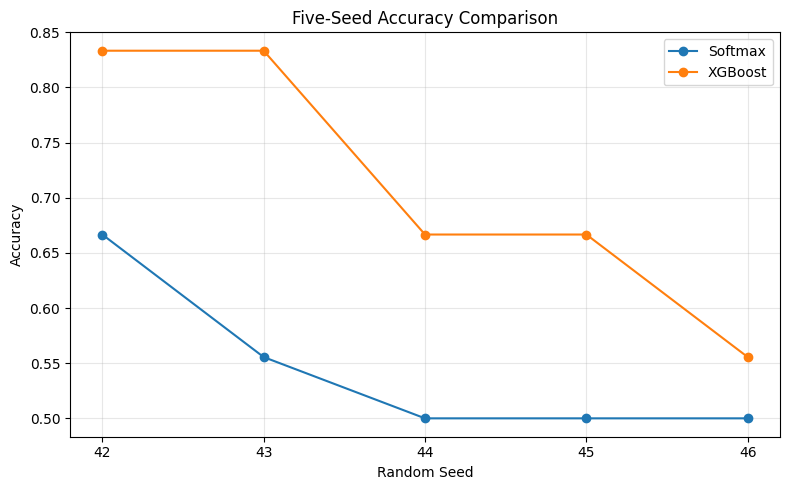

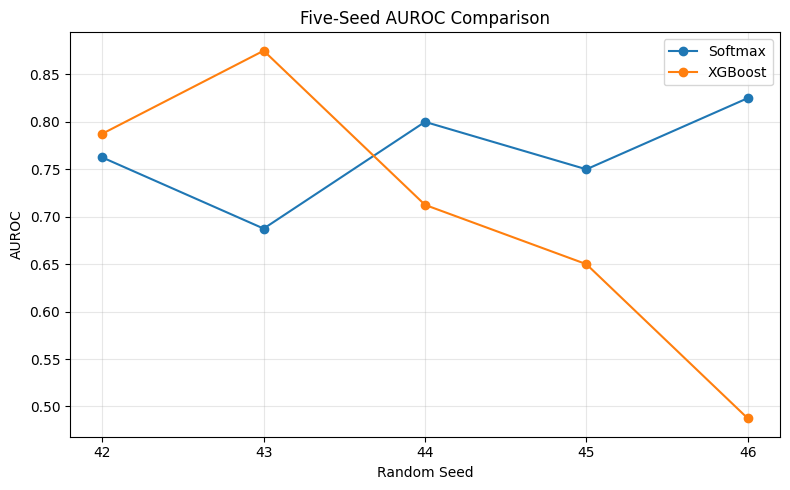

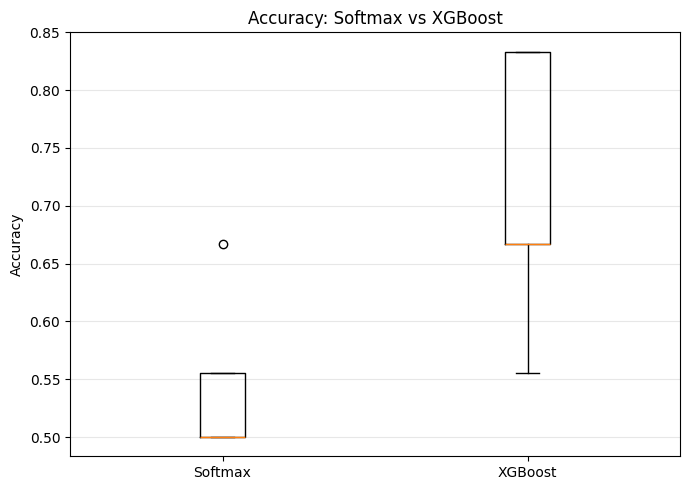

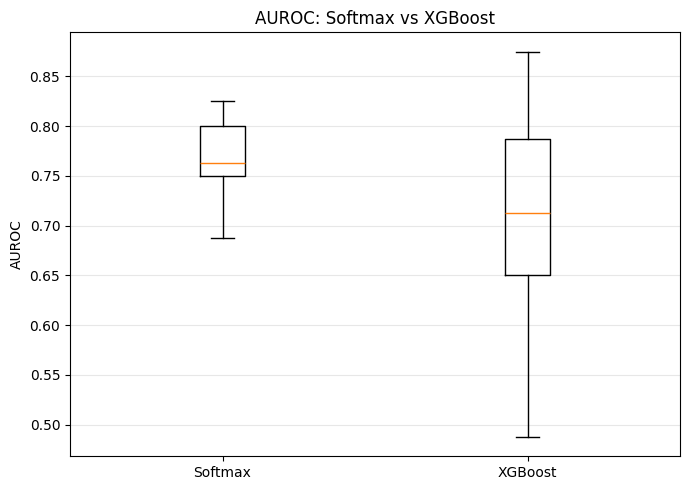



PUBLICATION-READY TABLE


,Metric,Softmax,Optimized XGBoost,Difference,Paired t-test p
0,ACCURACY,0.544 ± 0.072,0.711 ± 0.120,+0.167,0.0090
1,PRECISION,0.784 ± 0.204,0.767 ± 0.051,-0.017,0.8833
2,RECALL,0.420 ± 0.409,0.680 ± 0.249,+0.260,0.0897
3,F1,0.417 ± 0.270,0.702 ± 0.176,+0.285,0.0152
4,FPR,0.300 ± 0.420,0.250 ± 0.088,-0.050,0.8074
5,AUROC,0.765 ± 0.053,0.703 ± 0.147,-0.062,0.5075




STATISTICAL ANALYSIS COMPLETE

Saved files:
  ✓ accuracy_5_seed.png
  ✓ accuracy_boxplot.png
  ✓ auroc_5_seed.png
  ✓ auroc_boxplot.png
  ✓ complete_statistical_report.json
  ✓ five_seed_results.csv
  ✓ mean_sd_summary.csv
  ✓ paired_statistical_tests.csv
  ✓ publication_ready_table.csv
  ✓ statistical_interpretation.csv



Output:
/content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step3_statistical_analysis


In [ ]:
# ================================================================
# MODULE 2 — STEP 3
# STATISTICAL ROBUSTNESS ANALYSIS
#
# Video Swin + AST + Bidirectional Cross-Attention
# Softmax vs Optimized XGBoost
#
# 5 matched seeds:
# 42, 43, 44, 45, 46
#
# Uses cached features — NO Video Swin / AST re-extraction
# ================================================================

import os
import json
import random
import warnings
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from xgboost import XGBClassifier

from scipy.stats import ttest_rel, wilcoxon, t
from scipy import stats

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

SEEDS = [42, 43, 44, 45, 46]

BASE_DIR = "/content/drive/MyDrive/ParkinsonDataset/Module 2"

CACHE_DIR = os.path.join(
    BASE_DIR,
    "04_step2_optuna_optimized",
    "cached_features"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "moduleTwoResults",
    "step3_statistical_analysis"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR,
    "seed_checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("=" * 70)
print("MODULE 2 — STEP 3 STATISTICAL ROBUSTNESS ANALYSIS")
print("=" * 70)

print(f"\nCache directory:")
print(CACHE_DIR)

print(f"\nOutput directory:")
print(OUTPUT_DIR)

print(f"\nSeeds: {SEEDS}")

# ================================================================
# 2. DEVICE
# ================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nDevice: {device}")

# ================================================================
# 3. SEED FUNCTION
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ================================================================
# 4. LOAD CACHED FEATURES
# ================================================================

def load_cache(path):

    print(f"\nLoading:")
    print(path)

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    print("Type:", type(data))

    if isinstance(data, dict):
        print("Keys:", list(data.keys()))

    return data


train_cache = load_cache(
    os.path.join(CACHE_DIR, "train_features.pt")
)

val_cache = load_cache(
    os.path.join(CACHE_DIR, "validation_features.pt")
)

test_cache = load_cache(
    os.path.join(CACHE_DIR, "test_features.pt")
)


# ================================================================
# 5. FLEXIBLE FEATURE EXTRACTION
# ================================================================

def find_value(data, possible_keys):

    if not isinstance(data, dict):
        return None

    for key in possible_keys:

        if key in data:
            return data[key]

    return None


def extract_split(data, split_name):

    video = find_value(
        data,
        [
            "video_tokens",
            "video_features",
            "video",
            "video_embedding"
        ]
    )

    audio = find_value(
        data,
        [
            "audio_tokens",
            "audio_features",
            "audio",
            "audio_embedding"
        ]
    )

    labels = find_value(
        data,
        [
            "labels",
            "label",
            "y",
            "targets"
        ]
    )

    if video is None:
        raise KeyError(
            f"Could not find video features in {split_name}"
        )

    if audio is None:
        raise KeyError(
            f"Could not find audio features in {split_name}"
        )

    if labels is None:
        raise KeyError(
            f"Could not find labels in {split_name}"
        )

    video = torch.as_tensor(video).float()
    audio = torch.as_tensor(audio).float()
    labels = torch.as_tensor(labels).long().view(-1)

    print(f"\n{split_name}")
    print("-" * 50)
    print("Video:", tuple(video.shape))
    print("Audio:", tuple(audio.shape))
    print("Labels:", tuple(labels.shape))
    print(
        "Classes:",
        {
            int(x): int((labels == x).sum())
            for x in torch.unique(labels)
        }
    )

    return video, audio, labels


train_video, train_audio, y_train = extract_split(
    train_cache,
    "TRAIN"
)

val_video, val_audio, y_val = extract_split(
    val_cache,
    "VALIDATION"
)

test_video, test_audio, y_test = extract_split(
    test_cache,
    "TEST"
)


# ================================================================
# 6. CHECK FEATURE DIMENSIONS
# ================================================================

VIDEO_DIM = train_video.shape[-1]
AUDIO_DIM = train_audio.shape[-1]

print("\nFeature dimensions:")
print("Video:", VIDEO_DIM)
print("Audio:", AUDIO_DIM)

assert VIDEO_DIM == AUDIO_DIM, (
    "Video and audio dimensions must match for cross-attention."
)


# ================================================================
# 7. BIDIRECTIONAL CROSS-ATTENTION
# ================================================================

class BidirectionalCrossAttention(nn.Module):

    def __init__(
        self,
        video_dim,
        audio_dim,
        fusion_dim=384,
        num_heads=4,
        dropout=0.4
    ):
        super().__init__()

        self.video_proj = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_proj = nn.Linear(
            audio_dim,
            fusion_dim
        )

        self.video_to_audio = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.audio_to_video = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.video_norm = nn.LayerNorm(fusion_dim)
        self.audio_norm = nn.LayerNorm(fusion_dim)

        self.video_ffn = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim * 2, fusion_dim)
        )

        self.audio_ffn = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim * 2, fusion_dim)
        )

        self.final_video_norm = nn.LayerNorm(fusion_dim)
        self.final_audio_norm = nn.LayerNorm(fusion_dim)

    def forward(self, video, audio):

        video = self.video_proj(video)
        audio = self.audio_proj(audio)

        video_attn, _ = self.video_to_audio(
            query=video,
            key=audio,
            value=audio
        )

        audio_attn, _ = self.audio_to_video(
            query=audio,
            key=video,
            value=video
        )

        video = self.video_norm(
            video + video_attn
        )

        audio = self.audio_norm(
            audio + audio_attn
        )

        video = self.final_video_norm(
            video + self.video_ffn(video)
        )

        audio = self.final_audio_norm(
            audio + self.audio_ffn(audio)
        )

        video_pool = video.mean(dim=1)
        audio_pool = audio.mean(dim=1)

        fused = torch.cat(
            [video_pool, audio_pool],
            dim=1
        )

        return fused


# ================================================================
# 8. FIRST-RUN OPTIMIZED PARAMETERS
#
# These correspond to the configuration associated with your
# reported XGBoost result:
#
# Test Accuracy = 0.8333
# Test AUROC    = 0.8625
# ================================================================

FUSION_DIM = 384
NUM_HEADS = 4
DROPOUT = 0.4

LEARNING_RATE = 0.0002112772626327339
WEIGHT_DECAY = 3.09045996971412e-05

EPOCHS = 20
PATIENCE = 3

XGB_PARAMS = {
    "max_depth": 3,
    "learning_rate": 0.17254716573280354,
    "n_estimators": 200,
    "min_child_weight": 5,
    "subsample": 0.75,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.0001707396743152812,
    "reg_lambda": 3.9676050770529883
}

print("\n" + "=" * 70)
print("FROZEN EXPERIMENTAL CONFIGURATION")
print("=" * 70)

print(f"Fusion dimension : {FUSION_DIM}")
print(f"Attention heads  : {NUM_HEADS}")
print(f"Dropout          : {DROPOUT}")
print(f"Learning rate    : {LEARNING_RATE}")
print(f"Weight decay     : {WEIGHT_DECAY}")
print(f"Epochs            : {EPOCHS}")
print(f"Patience          : {PATIENCE}")

print("\nXGBoost:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")


# ================================================================
# 9. CREATE FUSION FEATURES
# ================================================================

def train_fusion_model(
    video_train,
    audio_train,
    labels_train,
    video_val,
    audio_val,
    labels_val,
    seed
):

    set_seed(seed)

    model = BidirectionalCrossAttention(
        video_dim=VIDEO_DIM,
        audio_dim=AUDIO_DIM,
        fusion_dim=FUSION_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT
    ).to(device)

    classifier = nn.Linear(
        2 * FUSION_DIM,
        2
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(model.parameters()) +
        list(classifier.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    video_train = video_train.to(device)
    audio_train = audio_train.to(device)
    labels_train = labels_train.to(device)

    video_val = video_val.to(device)
    audio_val = audio_val.to(device)
    labels_val = labels_val.to(device)

    best_auc = -np.inf
    best_epoch = 1
    patience_counter = 0

    best_state = None
    best_classifier_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):

        model.train()
        classifier.train()

        optimizer.zero_grad()

        fused_train = model(
            video_train,
            audio_train
        )

        logits_train = classifier(
            fused_train
        )

        loss = criterion(
            logits_train,
            labels_train
        )

        loss.backward()
        optimizer.step()

        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        model.eval()
        classifier.eval()

        with torch.no_grad():

            fused_val = model(
                video_val,
                audio_val
            )

            logits_val = classifier(
                fused_val
            )

            probabilities = torch.softmax(
                logits_val,
                dim=1
            )[:, 1]

            val_auc = roc_auc_score(
                labels_val.cpu().numpy(),
                probabilities.cpu().numpy()
            )

        print(
            f"Seed {seed} | "
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Loss={loss.item():.4f} | "
            f"Val AUROC={val_auc:.4f}"
        )

        if val_auc > best_auc:

            best_auc = val_auc
            best_epoch = epoch
            patience_counter = 0

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_classifier_state = {
                k: v.detach().cpu().clone()
                for k, v in classifier.state_dict().items()
            }

        else:

            patience_counter += 1

            if patience_counter >= PATIENCE:
                print(
                    f"Early stopping at epoch {epoch}"
                )
                break

    training_time = time.time() - start_time

    # Restore best fusion model
    model.load_state_dict(best_state)

    classifier.load_state_dict(
        best_classifier_state
    )

    model.eval()
    classifier.eval()

    with torch.no_grad():

        fused_train = model(
            video_train,
            audio_train
        ).cpu()

        fused_val = model(
            video_val,
            audio_val
        ).cpu()

    return (
        model,
        classifier,
        fused_train,
        fused_val,
        best_epoch,
        best_auc,
        training_time
    )


# ================================================================
# 10. METRIC FUNCTION
# ================================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.5
):

    y_true = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities)

    predictions = (
        probabilities >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    tpr = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    auc = roc_auc_score(
        y_true,
        probabilities
    )

    loss = log_loss(
        y_true,
        np.column_stack(
            [1 - probabilities, probabilities]
        ),
        labels=[0, 1]
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tpr": tpr,
        "fpr": fpr,
        "auroc": auc,
        "loss": loss,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


# ================================================================
# 11. RUN 5 MATCHED EXPERIMENTS
# ================================================================

all_results = []

print("\n")
print("=" * 70)
print("STARTING 5-SEED ROBUSTNESS EXPERIMENT")
print("=" * 70)

for seed in SEEDS:

    print("\n")
    print("#" * 70)
    print(f"RUNNING SEED {seed}")
    print("#" * 70)

    set_seed(seed)

    # ------------------------------------------------------------
    # Train cross-attention fusion
    # ------------------------------------------------------------

    (
        fusion_model,
        softmax_classifier,
        fused_train,
        fused_val,
        best_epoch,
        best_val_auc,
        fusion_time
    ) = train_fusion_model(
        train_video,
        train_audio,
        y_train,
        val_video,
        val_audio,
        y_val,
        seed
    )

    # ------------------------------------------------------------
    # Generate test fused features
    # ------------------------------------------------------------

    fusion_model.eval()

    with torch.no_grad():

        test_fusion_start = time.time()

        fused_test = fusion_model(
            test_video.to(device),
            test_audio.to(device)
        ).cpu()

        test_fusion_time = (
            time.time() -
            test_fusion_start
        )

    # ------------------------------------------------------------
    # SOFTMAX
    # ------------------------------------------------------------

    softmax_classifier.eval()

    with torch.no_grad():

        softmax_prob = torch.softmax(
            softmax_classifier(
                fused_test.to(device)
            ),
            dim=1
        )[:, 1].cpu().numpy()

    softmax_metrics = calculate_metrics(
        y_test.numpy(),
        softmax_prob
    )

    # ------------------------------------------------------------
    # XGBOOST
    # ------------------------------------------------------------

    X_train = fused_train.numpy()
    X_val = fused_val.numpy()
    X_test = fused_test.numpy()

    xgb_start = time.time()

    xgb_model = XGBClassifier(
        **XGB_PARAMS,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=seed,
        n_jobs=-1
    )

    xgb_model.fit(
        X_train,
        y_train.numpy()
    )

    xgb_train_time = (
        time.time() -
        xgb_start
    )

    xgb_test_start = time.time()

    xgb_prob = xgb_model.predict_proba(
        X_test
    )[:, 1]

    xgb_test_time = (
        time.time() -
        xgb_test_start
    )

    xgb_metrics = calculate_metrics(
        y_test.numpy(),
        xgb_prob
    )

    # ------------------------------------------------------------
    # Save checkpoint
    # ------------------------------------------------------------

    seed_dir = os.path.join(
        CHECKPOINT_DIR,
        f"seed_{seed}"
    )

    os.makedirs(
        seed_dir,
        exist_ok=True
    )

    torch.save(
        {
            "seed": seed,
            "fusion_state_dict": fusion_model.state_dict(),
            "softmax_classifier_state_dict":
                softmax_classifier.state_dict(),
            "best_epoch": best_epoch,
            "best_validation_auroc":
                best_val_auc
        },
        os.path.join(
            seed_dir,
            "fusion_softmax_checkpoint.pt"
        )
    )

    xgb_model.save_model(
        os.path.join(
            seed_dir,
            "xgboost_model.json"
        )
    )

    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    row_softmax = {
        "seed": seed,
        "model": "Softmax",
        "accuracy": softmax_metrics["accuracy"],
        "precision": softmax_metrics["precision"],
        "recall": softmax_metrics["recall"],
        "f1": softmax_metrics["f1"],
        "tpr": softmax_metrics["tpr"],
        "fpr": softmax_metrics["fpr"],
        "auroc": softmax_metrics["auroc"],
        "loss": softmax_metrics["loss"],
        "best_epoch": best_epoch,
        "validation_auroc": best_val_auc,
        "fusion_training_time_sec":
            fusion_time,
        "test_fusion_time_sec":
            test_fusion_time
    }

    row_xgb = {
        "seed": seed,
        "model": "XGBoost",
        "accuracy": xgb_metrics["accuracy"],
        "precision": xgb_metrics["precision"],
        "recall": xgb_metrics["recall"],
        "f1": xgb_metrics["f1"],
        "tpr": xgb_metrics["tpr"],
        "fpr": xgb_metrics["fpr"],
        "auroc": xgb_metrics["auroc"],
        "loss": xgb_metrics["loss"],
        "best_epoch": best_epoch,
        "validation_auroc": best_val_auc,
        "fusion_training_time_sec":
            fusion_time,
        "xgboost_training_time_sec":
            xgb_train_time,
        "xgboost_test_time_sec":
            xgb_test_time
    }

    all_results.append(row_softmax)
    all_results.append(row_xgb)

    print("\nRESULT — SOFTMAX")
    print(
        f"Accuracy : {softmax_metrics['accuracy']:.4f}"
    )
    print(
        f"Precision: {softmax_metrics['precision']:.4f}"
    )
    print(
        f"Recall   : {softmax_metrics['recall']:.4f}"
    )
    print(
        f"F1       : {softmax_metrics['f1']:.4f}"
    )
    print(
        f"FPR      : {softmax_metrics['fpr']:.4f}"
    )
    print(
        f"AUROC    : {softmax_metrics['auroc']:.4f}"
    )

    print("\nRESULT — XGBOOST")
    print(
        f"Accuracy : {xgb_metrics['accuracy']:.4f}"
    )
    print(
        f"Precision: {xgb_metrics['precision']:.4f}"
    )
    print(
        f"Recall   : {xgb_metrics['recall']:.4f}"
    )
    print(
        f"F1       : {xgb_metrics['f1']:.4f}"
    )
    print(
        f"FPR      : {xgb_metrics['fpr']:.4f}"
    )
    print(
        f"AUROC    : {xgb_metrics['auroc']:.4f}"
    )


# ================================================================
# 12. RESULTS DATAFRAME
# ================================================================

results_df = pd.DataFrame(
    all_results
)

results_path = os.path.join(
    OUTPUT_DIR,
    "five_seed_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\n")
print("=" * 70)
print("PER-SEED RESULTS")
print("=" * 70)

display(
    results_df[
        [
            "seed",
            "model",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "fpr",
            "auroc"
        ]
    ].round(4)
)


# ================================================================
# 13. MEAN ± SD
# ================================================================

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "tpr",
    "fpr",
    "auroc",
    "loss"
]

summary_rows = []

for model_name in [
    "Softmax",
    "XGBoost"
]:

    subset = results_df[
        results_df["model"] == model_name
    ]

    row = {
        "model": model_name
    }

    for metric in metrics:

        values = subset[metric].values

        row[f"{metric}_mean"] = np.mean(
            values
        )

        row[f"{metric}_sd"] = np.std(
            values,
            ddof=1
        )

        row[f"{metric}_mean_sd"] = (
            f"{np.mean(values):.4f} ± "
            f"{np.std(values, ddof=1):.4f}"
        )

    summary_rows.append(row)


summary_df = pd.DataFrame(
    summary_rows
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "mean_sd_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("\n")
print("=" * 70)
print("MEAN ± SD")
print("=" * 70)

display(
    summary_df[
        [
            "model",
            "accuracy_mean_sd",
            "precision_mean_sd",
            "recall_mean_sd",
            "f1_mean_sd",
            "fpr_mean_sd",
            "auroc_mean_sd"
        ]
    ]
)


# ================================================================
# 14. PAIRED STATISTICAL TESTS
# ================================================================

softmax_df = results_df[
    results_df["model"] == "Softmax"
].sort_values("seed")

xgb_df = results_df[
    results_df["model"] == "XGBoost"
].sort_values("seed")


statistical_rows = []

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "tpr",
    "fpr",
    "auroc",
    "loss"
]:

    softmax_values = (
        softmax_df[metric].values
    )

    xgb_values = (
        xgb_df[metric].values
    )

    differences = (
        xgb_values -
        softmax_values
    )

    # ------------------------------------------------------------
    # Paired t-test
    # ------------------------------------------------------------

    t_stat, t_p = ttest_rel(
        xgb_values,
        softmax_values
    )

    # ------------------------------------------------------------
    # Wilcoxon
    # ------------------------------------------------------------

    try:

        w_stat, w_p = wilcoxon(
            xgb_values,
            softmax_values,
            zero_method="wilcox",
            alternative="two-sided"
        )

    except Exception:

        w_stat = np.nan
        w_p = np.nan

    # ------------------------------------------------------------
    # Cohen's d for paired samples
    # ------------------------------------------------------------

    diff_sd = np.std(
        differences,
        ddof=1
    )

    if diff_sd > 0:

        cohens_d = (
            np.mean(differences) /
            diff_sd
        )

    else:

        cohens_d = np.nan

    # ------------------------------------------------------------
    # 95% CI of paired mean difference
    # ------------------------------------------------------------

    n = len(differences)

    mean_diff = np.mean(
        differences
    )

    sd_diff = np.std(
        differences,
        ddof=1
    )

    se_diff = (
        sd_diff /
        np.sqrt(n)
    )

    t_critical = t.ppf(
        0.975,
        df=n - 1
    )

    ci_low = (
        mean_diff -
        t_critical * se_diff
    )

    ci_high = (
        mean_diff +
        t_critical * se_diff
    )

    statistical_rows.append(
        {
            "metric": metric,

            "softmax_mean":
                np.mean(softmax_values),

            "softmax_sd":
                np.std(
                    softmax_values,
                    ddof=1
                ),

            "xgboost_mean":
                np.mean(xgb_values),

            "xgboost_sd":
                np.std(
                    xgb_values,
                    ddof=1
                ),

            "mean_difference_xgb_minus_softmax":
                mean_diff,

            "difference_sd":
                sd_diff,

            "95CI_lower":
                ci_low,

            "95CI_upper":
                ci_high,

            "paired_t_statistic":
                t_stat,

            "paired_t_p_value":
                t_p,

            "wilcoxon_statistic":
                w_stat,

            "wilcoxon_p_value":
                w_p,

            "cohens_d":
                cohens_d
        }
    )


stats_df = pd.DataFrame(
    statistical_rows
)

stats_path = os.path.join(
    OUTPUT_DIR,
    "paired_statistical_tests.csv"
)

stats_df.to_csv(
    stats_path,
    index=False
)


# ================================================================
# 15. DISPLAY STATISTICAL RESULTS
# ================================================================

print("\n")
print("=" * 70)
print("PAIRED STATISTICAL ANALYSIS")
print("=" * 70)

display(
    stats_df[
        [
            "metric",
            "mean_difference_xgb_minus_softmax",
            "95CI_lower",
            "95CI_upper",
            "paired_t_statistic",
            "paired_t_p_value",
            "wilcoxon_p_value",
            "cohens_d"
        ]
    ].round(5)
)


# ================================================================
# 16. SIGNIFICANCE INTERPRETATION
# ================================================================

interpretation_rows = []

for _, row in stats_df.iterrows():

    metric = row["metric"]

    p = row["paired_t_p_value"]

    if p < 0.001:
        significance = "***"
    elif p < 0.01:
        significance = "**"
    elif p < 0.05:
        significance = "*"
    else:
        significance = "NS"

    interpretation_rows.append(
        {
            "metric": metric,
            "p_value": p,
            "significance": significance,
            "interpretation":
                (
                    "Statistically significant difference"
                    if p < 0.05
                    else
                    "No statistically significant difference"
                )
        }
    )


interpretation_df = pd.DataFrame(
    interpretation_rows
)

interpretation_path = os.path.join(
    OUTPUT_DIR,
    "statistical_interpretation.csv"
)

interpretation_df.to_csv(
    interpretation_path,
    index=False
)


# ================================================================
# 17. ACCURACY / AUROC PLOT
# ================================================================

for metric, ylabel, title, filename in [

    (
        "accuracy",
        "Accuracy",
        "Five-Seed Accuracy Comparison",
        "accuracy_5_seed.png"
    ),

    (
        "auroc",
        "AUROC",
        "Five-Seed AUROC Comparison",
        "auroc_5_seed.png"
    )
]:

    plt.figure(
        figsize=(8, 5)
    )

    for model_name in [
        "Softmax",
        "XGBoost"
    ]:

        subset = results_df[
            results_df["model"] == model_name
        ].sort_values("seed")

        plt.plot(
            subset["seed"],
            subset[metric],
            marker="o",
            label=model_name
        )

    plt.xlabel(
        "Random Seed"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        title
    )

    plt.xticks(
        SEEDS
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ================================================================
# 18. BOX PLOT
# ================================================================

for metric, ylabel, filename in [

    (
        "accuracy",
        "Accuracy",
        "accuracy_boxplot.png"
    ),

    (
        "auroc",
        "AUROC",
        "auroc_boxplot.png"
    )

]:

    softmax_values = softmax_df[
        metric
    ].values

    xgb_values = xgb_df[
        metric
    ].values

    plt.figure(
        figsize=(7, 5)
    )

    plt.boxplot(
        [
            softmax_values,
            xgb_values
        ],
        labels=[
            "Softmax",
            "XGBoost"
        ]
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"{ylabel}: Softmax vs XGBoost"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ================================================================
# 19. PUBLICATION-READY SUMMARY
# ================================================================

publication_rows = []

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "fpr",
    "auroc"
]:

    soft_values = softmax_df[
        metric
    ].values

    xgb_values = xgb_df[
        metric
    ].values

    soft_mean = np.mean(
        soft_values
    )

    soft_sd = np.std(
        soft_values,
        ddof=1
    )

    xgb_mean = np.mean(
        xgb_values
    )

    xgb_sd = np.std(
        xgb_values,
        ddof=1
    )

    difference = (
        xgb_mean -
        soft_mean
    )

    p_value = stats_df.loc[
        stats_df["metric"] == metric,
        "paired_t_p_value"
    ].values[0]

    publication_rows.append(
        {
            "Metric": metric.upper(),

            "Softmax":
                f"{soft_mean:.3f} ± {soft_sd:.3f}",

            "Optimized XGBoost":
                f"{xgb_mean:.3f} ± {xgb_sd:.3f}",

            "Difference":
                f"{difference:+.3f}",

            "Paired t-test p":
                f"{p_value:.4f}"
        }
    )


publication_df = pd.DataFrame(
    publication_rows
)

publication_path = os.path.join(
    OUTPUT_DIR,
    "publication_ready_table.csv"
)

publication_df.to_csv(
    publication_path,
    index=False
)

print("\n")
print("=" * 70)
print("PUBLICATION-READY TABLE")
print("=" * 70)

display(
    publication_df
)


# ================================================================
# 20. SAVE COMPLETE JSON REPORT
# ================================================================

complete_report = {

    "experiment": {

        "name":
            "Module 2 Statistical Robustness Analysis",

        "architecture":
            "Video Swin + AST + Bidirectional Cross-Attention",

        "baseline":
            "Softmax",

        "optimized":
            "XGBoost",

        "dataset":
            "YouTube",

        "seeds":
            SEEDS,

        "number_of_runs":
            len(SEEDS),

        "test_samples":
            int(len(y_test)),

        "fusion_dimension":
            FUSION_DIM,

        "attention_heads":
            NUM_HEADS,

        "dropout":
            DROPOUT,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY
    },

    "reported_single_run_reference": {

        "softmax_accuracy":
            0.6666666667,

        "softmax_auroc":
            0.8000,

        "xgboost_accuracy":
            0.8333333333,

        "xgboost_auroc":
            0.8625
    },

    "statistical_methods": [

        "Mean ± standard deviation",

        "Paired Student's t-test",

        "Wilcoxon signed-rank test",

        "95% confidence interval of paired difference",

        "Cohen's d"
    ],

    "results":
        results_df.to_dict(
            orient="records"
        ),

    "summary":
        summary_df.to_dict(
            orient="records"
        ),

    "statistical_tests":
        stats_df.to_dict(
            orient="records"
        )
}


json_path = os.path.join(
    OUTPUT_DIR,
    "complete_statistical_report.json"
)

with open(
    json_path,
    "w"
) as f:

    json.dump(
        complete_report,
        f,
        indent=4,
        default=float
    )


# ================================================================
# 21. FINAL OUTPUT
# ================================================================

print("\n")
print("=" * 70)
print("STATISTICAL ANALYSIS COMPLETE")
print("=" * 70)

print("\nSaved files:")

for filename in sorted(
    os.listdir(OUTPUT_DIR)
):

    filepath = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.isfile(filepath):

        print(
            f"  ✓ {filename}"
        )

print("\n")
print("\nOutput:")
print(OUTPUT_DIR)

#ABLATION STUDY

In [ ]:
# ================================================================
# STEP 4 — COMPLETE ABLATION STUDY
#
# A1: Without Video
# A2: Without Audio
# A3: Without Cross-Attention
# A4: Complete Hybrid + Softmax
# A5: Complete Hybrid + XGBoost
# ================================================================

import os
import json
import time
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ================================================================
# 1. CONFIGURATION
# ================================================================

SEED = 42

BASE_DIR = "/content/drive/MyDrive/ParkinsonDataset/Module 2"

STEP2_DIR = os.path.join(
    BASE_DIR,
    "04_step2_optuna_optimized"
)

FEATURE_DIR = os.path.join(
    STEP2_DIR,
    "cached_features"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "06_step4_ablation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 70)
print("STEP 4 — COMPLETE ABLATION STUDY")
print("=" * 70)

print("Device :", DEVICE)
print("Feature directory :", FEATURE_DIR)
print("Output directory :", OUTPUT_DIR)


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


# ================================================================
# 3. LOAD CACHED FEATURES
# ================================================================

print("\nLoading cached frozen features...")


TRAIN_PATH = os.path.join(
    FEATURE_DIR,
    "train_features.pt"
)

VAL_PATH = os.path.join(
    FEATURE_DIR,
    "validation_features.pt"
)

TEST_PATH = os.path.join(
    FEATURE_DIR,
    "test_features.pt"
)


train_data = torch.load(
    TRAIN_PATH,
    map_location="cpu",
    weights_only=False
)

val_data = torch.load(
    VAL_PATH,
    map_location="cpu",
    weights_only=False
)

test_data = torch.load(
    TEST_PATH,
    map_location="cpu",
    weights_only=False
)


print("Train keys:", list(train_data.keys()))
print("Val keys  :", list(val_data.keys()))
print("Test keys :", list(test_data.keys()))


# ================================================================
# 4. ROBUST FEATURE EXTRACTION
# ================================================================

def get_value(
    dictionary,
    candidates
):

    lower_map = {
        str(k).lower(): k
        for k in dictionary.keys()
    }

    for candidate in candidates:

        if candidate.lower() in lower_map:

            return dictionary[
                lower_map[candidate.lower()]
            ]

    raise KeyError(
        f"Could not find {candidates}. "
        f"Available keys: {list(dictionary.keys())}"
    )


def extract_features(data):

    video = get_value(
        data,
        [
            "video_features",
            "video_tokens",
            "video"
        ]
    ).float()

    audio = get_value(
        data,
        [
            "audio_features",
            "audio_tokens",
            "audio"
        ]
    ).float()

    labels = get_value(
        data,
        [
            "labels",
            "label",
            "y"
        ]
    ).long()

    return video, audio, labels


Xv_train, Xa_train, y_train = extract_features(
    train_data
)

Xv_val, Xa_val, y_val = extract_features(
    val_data
)

Xv_test, Xa_test, y_test = extract_features(
    test_data
)


# ================================================================
# 5. PRINT SHAPES
# ================================================================

print("\n" + "=" * 70)
print("FEATURE SHAPES")
print("=" * 70)

print("Train video :", Xv_train.shape)
print("Train audio :", Xa_train.shape)
print("Train labels:", y_train.shape)

print("Val video   :", Xv_val.shape)
print("Val audio   :", Xa_val.shape)
print("Val labels  :", y_val.shape)

print("Test video  :", Xv_test.shape)
print("Test audio  :", Xa_test.shape)
print("Test labels :", y_test.shape)


# ================================================================
# 6. LOAD STEP 2 OPTUNA CONFIGURATION
# ================================================================

OPTUNA_PATH = os.path.join(
    STEP2_DIR,
    "best_optuna_params.json"
)


with open(
    OPTUNA_PATH,
    "r"
) as f:

    OPTUNA_CONFIG = json.load(f)


FUSION_DIM = int(
    OPTUNA_CONFIG["fusion_dim"]
)

NUM_HEADS = int(
    OPTUNA_CONFIG["num_heads"]
)

DROPOUT = float(
    OPTUNA_CONFIG["dropout"]
)

LEARNING_RATE = float(
    OPTUNA_CONFIG["learning_rate"]
)

WEIGHT_DECAY = float(
    OPTUNA_CONFIG["weight_decay"]
)

LABEL_SMOOTHING = float(
    OPTUNA_CONFIG["label_smoothing"]
)

MAX_EPOCHS = int(
    OPTUNA_CONFIG["max_epochs"]
)

PATIENCE = int(
    OPTUNA_CONFIG["patience"]
)


print("\n" + "=" * 70)
print("STEP 2 OPTUNA CONFIGURATION")
print("=" * 70)

for key, value in OPTUNA_CONFIG.items():

    print(
        f"{key:20s}: {value}"
    )


# ================================================================
# 7. XGBOOST CONFIGURATION
# ================================================================

XGB_PARAMS = {

    "max_depth": 3,

    "learning_rate":
        0.16196598001492074,

    "n_estimators":
        150,

    "min_child_weight":
        6,

    "subsample":
        0.85,

    "colsample_bytree":
        0.75,

    "reg_alpha":
        0.00021471698859843542,

    "reg_lambda":
        0.3732722503984233
}


# ================================================================
# 8. CLASS WEIGHTS
# ================================================================

negative_count = int(
    (y_train == 0).sum()
)

positive_count = int(
    (y_train == 1).sum()
)

weight_negative = (
    len(y_train)
    /
    (2 * negative_count)
)

weight_positive = (
    len(y_train)
    /
    (2 * positive_count)
)


print("\nClass counts:")
print("Negative:", negative_count)
print("Positive:", positive_count)

print(
    "Class weights:",
    [
        weight_negative,
        weight_positive
    ]
)


# ================================================================
# 9. FULL BIDIRECTIONAL CROSS-ATTENTION
# ================================================================

class BidirectionalCrossAttention(
    nn.Module
):

    def __init__(
        self,
        video_dim=768,
        audio_dim=768,
        fusion_dim=128,
        num_heads=8,
        dropout=0.2
    ):

        super().__init__()

        self.video_projection = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_projection = nn.Linear(
            audio_dim,
            fusion_dim
        )

        self.video_to_audio = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.audio_to_video = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.video_norm1 = nn.LayerNorm(
            fusion_dim
        )

        self.audio_norm1 = nn.LayerNorm(
            fusion_dim
        )

        self.video_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.audio_ffn = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.video_norm2 = nn.LayerNorm(
            fusion_dim
        )

        self.audio_norm2 = nn.LayerNorm(
            fusion_dim
        )


    def forward(
        self,
        video,
        audio
    ):

        video = self.video_projection(
            video
        )

        audio = self.audio_projection(
            audio
        )

        video_attended, _ = (
            self.video_to_audio(
                video,
                audio,
                audio
            )
        )

        audio_attended, _ = (
            self.audio_to_video(
                audio,
                video,
                video
            )
        )

        video = self.video_norm1(
            video + video_attended
        )

        audio = self.audio_norm1(
            audio + audio_attended
        )

        video = self.video_norm2(
            video +
            self.video_ffn(video)
        )

        audio = self.audio_norm2(
            audio +
            self.audio_ffn(audio)
        )

        video_embedding = video.mean(
            dim=1
        )

        audio_embedding = audio.mean(
            dim=1
        )

        return torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )


# ================================================================
# 10. SIMPLE CONCATENATION
#     A3 — WITHOUT CROSS-ATTENTION
# ================================================================

class SimpleConcatFusion(
    nn.Module
):

    def __init__(
        self,
        video_dim=768,
        audio_dim=768,
        fusion_dim=128
    ):

        super().__init__()

        self.video_projection = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_projection = nn.Linear(
            audio_dim,
            fusion_dim
        )


    def forward(
        self,
        video,
        audio
    ):

        video = self.video_projection(
            video
        )

        audio = self.audio_projection(
            audio
        )

        video_embedding = video.mean(
            dim=1
        )

        audio_embedding = audio.mean(
            dim=1
        )

        return torch.cat(
            [
                video_embedding,
                audio_embedding
            ],
            dim=1
        )


# ================================================================
# 11. VIDEO ONLY
#     A2 — WITHOUT AUDIO
# ================================================================

class VideoOnly(
    nn.Module
):

    def __init__(
        self,
        input_dim=768,
        fusion_dim=128
    ):

        super().__init__()

        self.projection = nn.Linear(
            input_dim,
            fusion_dim
        )


    def forward(
        self,
        video,
        audio=None
    ):

        video = self.projection(
            video
        )

        return video.mean(
            dim=1
        )


# ================================================================
# 12. AUDIO ONLY
#     A1 — WITHOUT VIDEO
# ================================================================

class AudioOnly(
    nn.Module
):

    def __init__(
        self,
        input_dim=768,
        fusion_dim=128
    ):

        super().__init__()

        self.projection = nn.Linear(
            input_dim,
            fusion_dim
        )


    def forward(
        self,
        video=None,
        audio=None
    ):

        audio = self.projection(
            audio
        )

        return audio.mean(
            dim=1
        )


# ================================================================
# 13. CLASSIFIER
# ================================================================

class FusionClassifier(
    nn.Module
):

    def __init__(
        self,
        input_dim
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.LayerNorm(
                256
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )


    def forward(self, x):

        return self.network(x)


# ================================================================
# 14. METRIC CALCULATION
# ================================================================

def calculate_metrics(
    y_true,
    probabilities
):

    y_true = np.asarray(
        y_true
    )

    probabilities = np.asarray(
        probabilities
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    metrics = {

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "TPR":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "FPR":
            (
                fp / (fp + tn)
                if (fp + tn) > 0
                else 0
            ),

        "AUROC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "Loss":
            log_loss(
                y_true,
                np.column_stack(
                    [
                        1 - probabilities,
                        probabilities
                    ]
                ),
                labels=[0, 1]
            ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return metrics


# ================================================================
# 15. TRAIN ONE ABLATION
# ================================================================

def train_ablation(
    name,
    fusion_model,
    input_dim,
    use_xgboost=True
):

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)

    fusion_model = fusion_model.to(
        DEVICE
    )

    classifier = FusionClassifier(
        input_dim
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(

        list(
            fusion_model.parameters()
        )
        +
        list(
            classifier.parameters()
        ),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY
    )

    class_weights = torch.tensor(
        [
            weight_negative,
            weight_positive
        ],
        dtype=torch.float32,
        device=DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING
    )

    train_dataset = TensorDataset(
        Xv_train,
        Xa_train,
        y_train
    )

    val_dataset = TensorDataset(
        Xv_val,
        Xa_val,
        y_val
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=1,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False
    )

    best_val_auc = -np.inf

    best_fusion_state = None
    best_classifier_state = None

    patience_counter = 0

    training_start = time.time()

    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    for epoch in range(
        MAX_EPOCHS
    ):

        fusion_model.train()
        classifier.train()

        for video, audio, labels in train_loader:

            video = video.to(
                DEVICE
            )

            audio = audio.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )

            optimizer.zero_grad()

            fused = fusion_model(
                video,
                audio
            )

            logits = classifier(
                fused
            )

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            optimizer.step()

        # --------------------------------------------------------
        # VALIDATION
        # --------------------------------------------------------

        fusion_model.eval()
        classifier.eval()

        val_probabilities = []
        val_targets = []

        validation_start = time.time()

        with torch.no_grad():

            for video, audio, labels in val_loader:

                video = video.to(
                    DEVICE
                )

                audio = audio.to(
                    DEVICE
                )

                labels = labels.to(
                    DEVICE
                )

                fused = fusion_model(
                    video,
                    audio
                )

                logits = classifier(
                    fused
                )

                probabilities = torch.softmax(
                    logits,
                    dim=1
                )[:, 1]

                val_probabilities.extend(
                    probabilities
                    .cpu()
                    .numpy()
                )

                val_targets.extend(
                    labels
                    .cpu()
                    .numpy()
                )

        validation_time = (
            time.time()
            -
            validation_start
        )

        val_auc = roc_auc_score(
            val_targets,
            val_probabilities
        )

        val_predictions = (
            np.asarray(
                val_probabilities
            ) >= 0.5
        ).astype(int)

        val_accuracy = accuracy_score(
            val_targets,
            val_predictions
        )

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Val Acc {val_accuracy:.4f} | "
            f"Val AUROC {val_auc:.4f}"
        )

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            best_fusion_state = {
                k: v.detach()
                .cpu()
                .clone()
                for k, v
                in fusion_model.state_dict().items()
            }

            best_classifier_state = {
                k: v.detach()
                .cpu()
                .clone()
                for k, v
                in classifier.state_dict().items()
            }

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= PATIENCE:

                print(
                    "Early stopping."
                )

                break

    training_time = (
        time.time()
        -
        training_start
    )

    # ------------------------------------------------------------
    # RESTORE BEST VALIDATION CHECKPOINT
    # ------------------------------------------------------------

    fusion_model.load_state_dict(
        best_fusion_state
    )

    classifier.load_state_dict(
        best_classifier_state
    )

    # ------------------------------------------------------------
    # EXTRACT TRAIN / VAL / TEST REPRESENTATIONS
    # ------------------------------------------------------------

    fusion_model.eval()

    with torch.no_grad():

        train_repr = fusion_model(
            Xv_train.to(DEVICE),
            Xa_train.to(DEVICE)
        ).cpu().numpy()

        val_repr = fusion_model(
            Xv_val.to(DEVICE),
            Xa_val.to(DEVICE)
        ).cpu().numpy()

        test_repr = fusion_model(
            Xv_test.to(DEVICE),
            Xa_test.to(DEVICE)
        ).cpu().numpy()

    # ============================================================
    # A5 — XGBOOST
    # ============================================================

    if use_xgboost:

        xgb_start = time.time()

        xgb = XGBClassifier(

            **XGB_PARAMS,

            objective="binary:logistic",

            eval_metric="logloss",

            random_state=SEED,

            n_jobs=-1
        )

        xgb.fit(
            train_repr,
            y_train.numpy()
        )

        xgb_training_time = (
            time.time()
            -
            xgb_start
        )

        testing_start = time.time()

        test_probabilities = (
            xgb.predict_proba(
                test_repr
            )[:, 1]
        )

        testing_time = (
            time.time()
            -
            testing_start
        )

    # ============================================================
    # A4 — SOFTMAX
    # ============================================================

    else:

        xgb = None

        testing_start = time.time()

        with torch.no_grad():

            test_logits = classifier(
                torch.tensor(
                    test_repr,
                    dtype=torch.float32,
                    device=DEVICE
                )
            )

            test_probabilities = (
                torch.softmax(
                    test_logits,
                    dim=1
                )[:, 1]
                .cpu()
                .numpy()
            )

        testing_time = (
            time.time()
            -
            testing_start
        )

        xgb_training_time = 0.0

    # ------------------------------------------------------------
    # METRICS
    # ------------------------------------------------------------

    metrics = calculate_metrics(
        y_test.numpy(),
        test_probabilities
    )

    metrics.update({

        "Configuration":
            name,

        "Best_Val_AUROC":
            best_val_auc,

        "Training_Time_sec":
            training_time,

        "Validation_Time_sec":
            validation_time,

        "XGBoost_Training_Time_sec":
            xgb_training_time,

        "Testing_Time_sec":
            testing_time,

        "Representation_Dim":
            test_repr.shape[1]
    })

    # ------------------------------------------------------------
    # PRINT
    # ------------------------------------------------------------

    print("\nFINAL TEST RESULT")
    print("-----------------")

    for metric in [

        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "TPR",
        "FPR",
        "AUROC",
        "Loss"
    ]:

        print(
            f"{metric:12s}: "
            f"{metrics[metric]:.4f}"
        )

    return (
        metrics,
        fusion_model,
        classifier,
        xgb
    )


# ================================================================
# 16. RUN A1
# ================================================================

# A1:
# Without Video
# Audio ✓
# Cross-Attention ✓
# Softmax ✓
# XGBoost ✓

A1_results = train_ablation(

    "A1 - Without Video",

    AudioOnly(
        input_dim=768,
        fusion_dim=FUSION_DIM
    ),

    input_dim=FUSION_DIM,

    use_xgboost=True
)


# ================================================================
# 17. RUN A2
# ================================================================

# A2:
# Video ✓
# Audio ✗
# Cross-Attention ✓
# Softmax ✓
# XGBoost ✓

A2_results = train_ablation(

    "A2 - Without Audio",

    VideoOnly(
        input_dim=768,
        fusion_dim=FUSION_DIM
    ),

    input_dim=FUSION_DIM,

    use_xgboost=True
)


# ================================================================
# 18. RUN A3
# ================================================================

# A3:
# Video ✓
# Audio ✓
# Cross-Attention ✗
# Softmax ✓
# XGBoost ✓

A3_results = train_ablation(

    "A3 - Without Cross-Attention",

    SimpleConcatFusion(
        video_dim=768,
        audio_dim=768,
        fusion_dim=FUSION_DIM
    ),

    input_dim=FUSION_DIM * 2,

    use_xgboost=True
)


# ================================================================
# 19. RUN A4
# ================================================================

# A4:
# Video ✓
# Audio ✓
# Cross-Attention ✓
# Softmax ✓
# XGBoost ✗

A4_results = train_ablation(

    "A4 - Complete Hybrid + Softmax",

    BidirectionalCrossAttention(
        video_dim=768,
        audio_dim=768,
        fusion_dim=FUSION_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT
    ),

    input_dim=FUSION_DIM * 2,

    use_xgboost=False
)


# ================================================================
# 20. RUN A5
# ================================================================

# A5:
# Video ✓
# Audio ✓
# Cross-Attention ✓
# Softmax ✗
# XGBoost ✓

A5_results = train_ablation(

    "A5 - Complete Hybrid + XGBoost",

    BidirectionalCrossAttention(
        video_dim=768,
        audio_dim=768,
        fusion_dim=FUSION_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT
    ),

    input_dim=FUSION_DIM * 2,

    use_xgboost=True
)


# ================================================================
# 21. COLLECT RESULTS
# ================================================================

all_results = [

    A1_results[0],
    A2_results[0],
    A3_results[0],
    A4_results[0],
    A5_results[0]
]


results_df = pd.DataFrame(
    all_results
)


# ================================================================
# 22. ORDER COLUMNS
# ================================================================

column_order = [

    "Configuration",

    "Accuracy",

    "Precision",

    "Recall",

    "F1",

    "TPR",

    "FPR",

    "AUROC",

    "Loss",

    "Best_Val_AUROC",

    "Training_Time_sec",

    "Validation_Time_sec",

    "XGBoost_Training_Time_sec",

    "Testing_Time_sec",

    "Representation_Dim",

    "TN",

    "FP",

    "FN",

    "TP"
]


results_df = results_df[
    column_order
]


# ================================================================
# 23. SAVE RESULTS
# ================================================================

RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "ablation_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)


# ================================================================
# 24. SAVE EXPERIMENT CONFIGURATION
# ================================================================

ablation_configuration = {

    "seed": SEED,

    "dataset": "YouTube",

    "feature_source":
        FEATURE_DIR,

    "fusion_configuration":
        OPTUNA_CONFIG,

    "xgboost_configuration":
        XGB_PARAMS,

    "ablations": {

        "A1": {

            "name":
                "Without Video",

            "video":
                False,

            "audio":
                True,

            "cross_attention":
                True,

            "softmax":
                True,

            "xgboost":
                True
        },

        "A2": {

            "name":
                "Without Audio",

            "video":
                True,

            "audio":
                False,

            "cross_attention":
                True,

            "softmax":
                True,

            "xgboost":
                True
        },

        "A3": {

            "name":
                "Without Cross-Attention",

            "video":
                True,

            "audio":
                True,

            "cross_attention":
                False,

            "softmax":
                True,

            "xgboost":
                True
        },

        "A4": {

            "name":
                "Complete Hybrid + Softmax",

            "video":
                True,

            "audio":
                True,

            "cross_attention":
                True,

            "softmax":
                True,

            "xgboost":
                False
        },

        "A5": {

            "name":
                "Complete Hybrid + XGBoost",

            "video":
                True,

            "audio":
                True,

            "cross_attention":
                True,

            "softmax":
                False,

            "xgboost":
                True
        }
    }
}


CONFIG_PATH = os.path.join(
    OUTPUT_DIR,
    "ablation_configuration.json"
)


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        ablation_configuration,
        f,
        indent=4
    )


# ================================================================
# 25. FINAL DISPLAY
# ================================================================

print("\n")
print("=" * 70)
print("FINAL ABLATION STUDY RESULTS")
print("=" * 70)

display(
    results_df
)


print("\nSaved:")
print(
    RESULTS_PATH
)

print(
    CONFIG_PATH
)


print("\n")
print("=" * 70)
print("STEP 4 COMPLETED")
print("=" * 70)

STEP 4 — COMPLETE ABLATION STUDY
Device : cuda
Feature directory : /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features
Output directory : /content/drive/MyDrive/ParkinsonDataset/Module 2/06_step4_ablation

Loading cached frozen features...
Train keys: ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']
Val keys  : ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']
Test keys : ['video_tokens', 'audio_tokens', 'labels', 'paths', 'extraction_time']

FEATURE SHAPES
Train video : torch.Size([81, 784, 768])
Train audio : torch.Size([81, 1214, 768])
Train labels: torch.Size([81])
Val video   : torch.Size([18, 784, 768])
Val audio   : torch.Size([18, 1214, 768])
Val labels  : torch.Size([18])
Test video  : torch.Size([18, 784, 768])
Test audio  : torch.Size([18, 1214, 768])
Test labels : torch.Size([18])

STEP 2 OPTUNA CONFIGURATION
fusion_dim          : 128
num_heads           : 8
dropout             : 0.2
learning_

,Configuration,Accuracy,Precision,Recall,F1,TPR,FPR,AUROC,Loss,Best_Val_AUROC,Training_Time_sec,Validation_Time_sec,XGBoost_Training_Time_sec,Testing_Time_sec,Representation_Dim,TN,FP,FN,TP
0,A1 - Without Video,0.611111,0.636364,0.7,0.666667,0.7,0.500,0.6750,0.648268,0.6625,6.485512,0.076000,0.070578,0.001564,128,4,4,3,7
1,A2 - Without Audio,0.555556,0.600000,0.6,0.600000,0.6,0.500,0.6625,0.690030,0.8375,5.678523,0.069667,0.060719,0.001279,128,4,4,4,6
2,A3 - Without Cross-Attention,0.611111,0.666667,0.6,0.631579,0.6,0.375,0.7125,0.624726,0.8125,9.856262,0.081069,0.092912,0.003297,256,5,3,4,6
3,A4 - Complete Hybrid + Softmax,0.555556,0.555556,1.0,0.714286,1.0,1.000,0.6750,0.667389,0.9250,7.260338,0.119410,0.000000,0.007013,256,0,8,0,10
4,A5 - Complete Hybrid + XGBoost,0.722222,0.777778,0.7,0.736842,0.7,0.250,0.8625,0.465644,0.8375,7.843278,0.098414,0.053705,0.001080,256,6,2,3,7



Saved:
/content/drive/MyDrive/ParkinsonDataset/Module 2/06_step4_ablation/ablation_results.csv
/content/drive/MyDrive/ParkinsonDataset/Module 2/06_step4_ablation/ablation_configuration.json


STEP 4 COMPLETED


#SHAP

MODULE 2 — STEP 5 SHAP EXPLAINABILITY

Fusion checkpoint:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_first_run_reproduction/best_fusion_model_first_run_reproduction.pt

XGBoost checkpoint:
/content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_first_run_reproduction/best_xgboost_model_first_run_reproduction.json

Output:
/content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability


CHECKING REQUIRED FILES
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/train_features.pt
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/validation_features.pt
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_optuna_optimized/cached_features/test_features.pt
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_first_run_reproduction/best_fusion_model_first_run_reproduction.pt
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/04_step2_first_run_reprodu

,feature,mean_abs_shap,mean_signed_shap,rank
0,AST_Fused_064,0.374580,-0.374580,1
1,Video_Swin_Fused_286,0.320955,0.213174,2
2,AST_Fused_131,0.300994,-0.066864,3
3,Video_Swin_Fused_371,0.267892,0.118035,4
4,AST_Fused_165,0.252638,-0.155726,5
5,Video_Swin_Fused_247,0.217941,-0.035217,6
6,Video_Swin_Fused_343,0.179679,0.088892,7
7,AST_Fused_370,0.178809,-0.093331,8
8,AST_Fused_013,0.175619,-0.164445,9
9,AST_Fused_096,0.133601,0.022774,10



Generating SHAP bar summary...


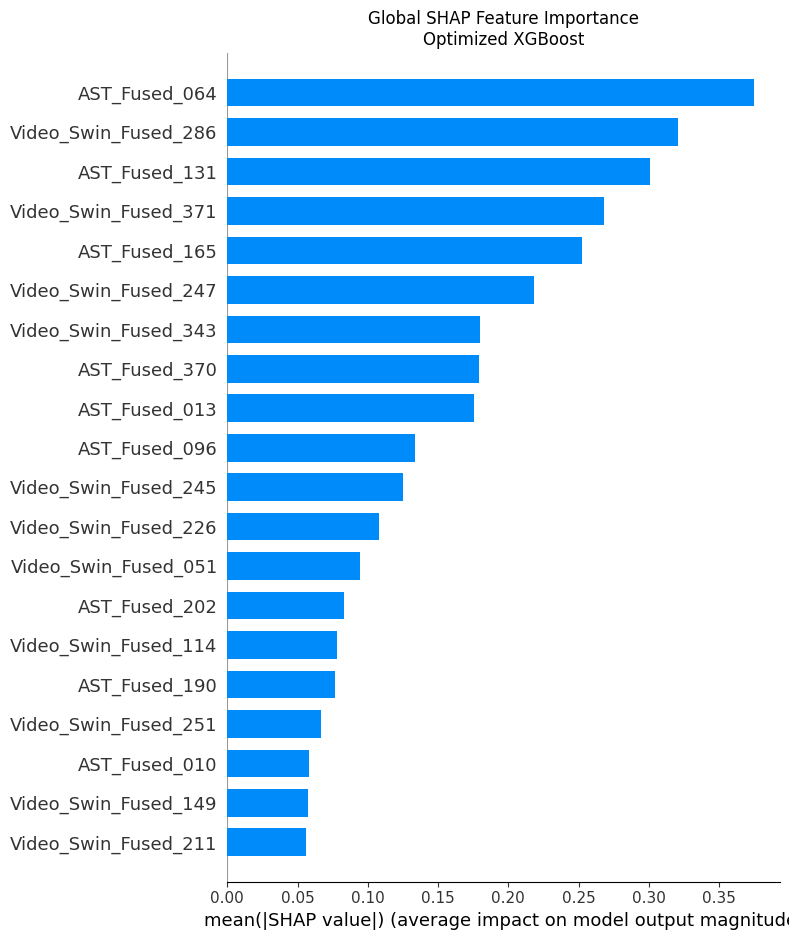

✓ Saved: /content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability/plots/shap_global_bar_summary.png

Generating SHAP beeswarm...


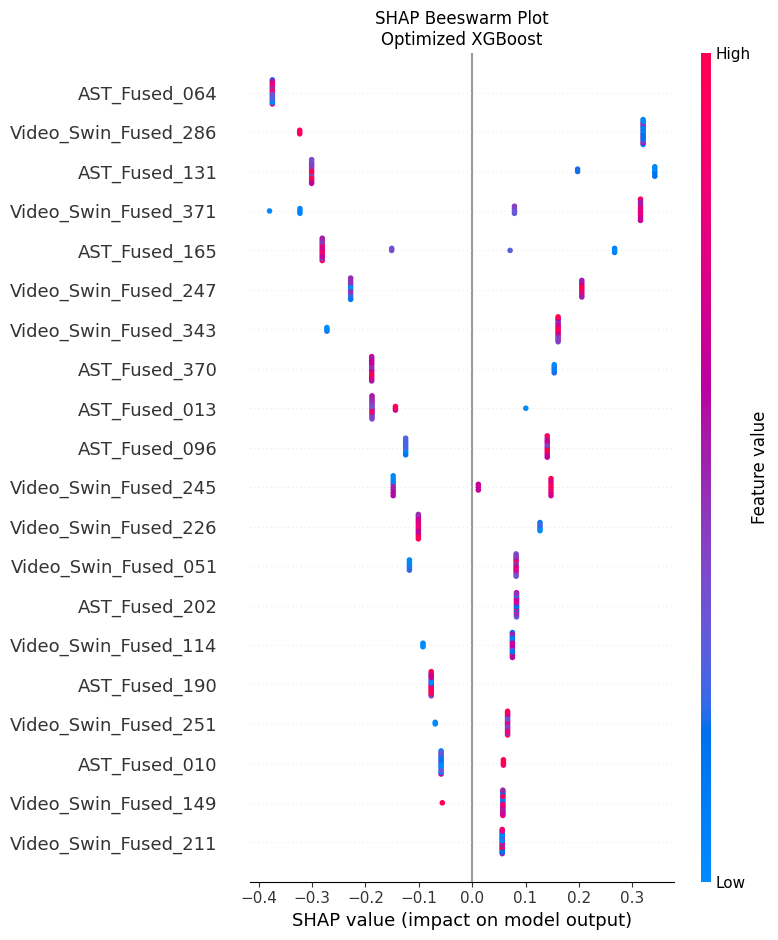

✓ Saved: /content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability/plots/shap_beeswarm.png


,feature,mean_abs_shap,mean_signed_shap,rank
0,AST_Fused_064,0.374580,-0.374580,1
1,Video_Swin_Fused_286,0.320955,0.213174,2
2,AST_Fused_131,0.300994,-0.066864,3
3,Video_Swin_Fused_371,0.267892,0.118035,4
4,AST_Fused_165,0.252638,-0.155726,5
5,Video_Swin_Fused_247,0.217941,-0.035217,6
6,Video_Swin_Fused_343,0.179679,0.088892,7
7,AST_Fused_370,0.178809,-0.093331,8
8,AST_Fused_013,0.175619,-0.164445,9
9,AST_Fused_096,0.133601,0.022774,10




MODALITY-ATTRIBUTED SHAP


,modality,mean_absolute_shap,relative_percentage
0,Video Swin,0.0041,49.036201
1,AST Audio,0.0043,50.963799


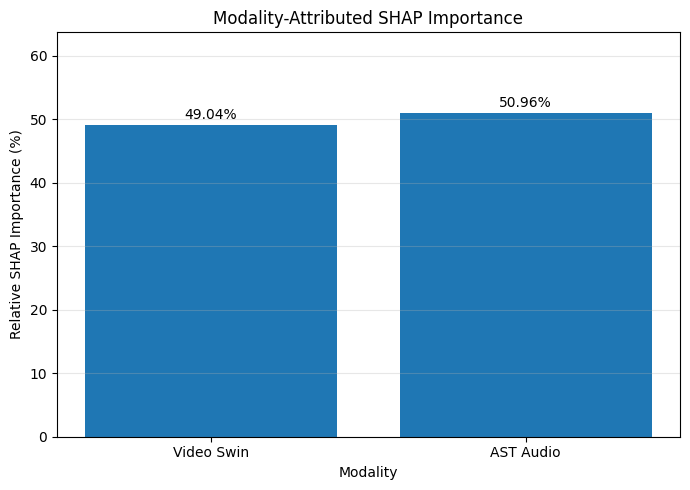



REPRESENTATIVE SAMPLES
Correct_Parkinson: sample 1, true=1, pred=1, P(PD)=0.6232
Correct_Control: sample 3, true=0, pred=0, P(PD)=0.4920
Misclassified: sample 0, true=1, pred=0, P(PD)=0.2986


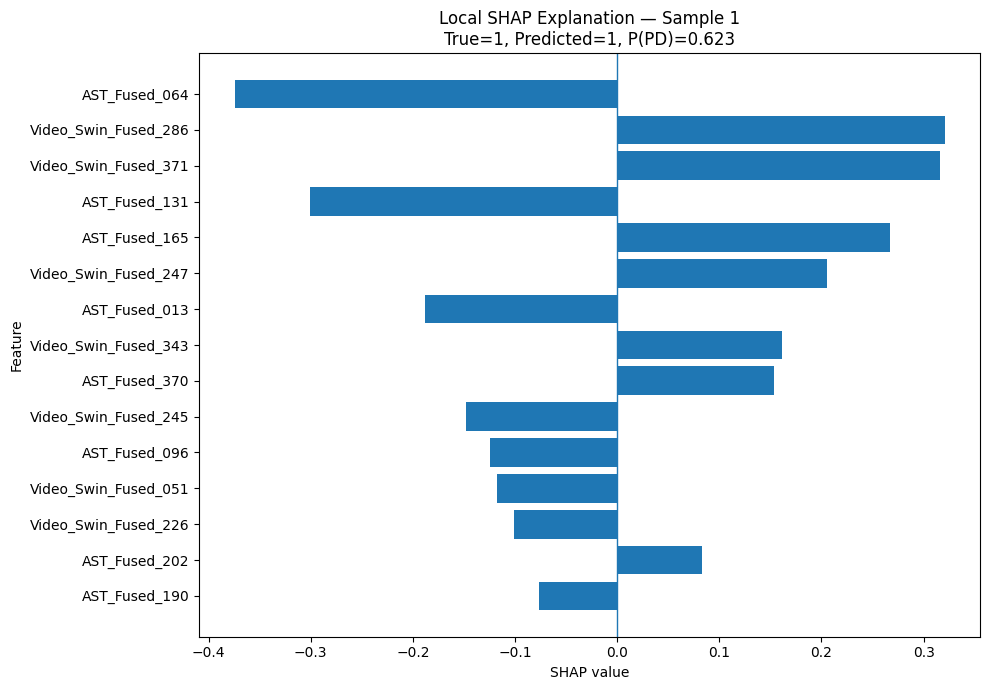

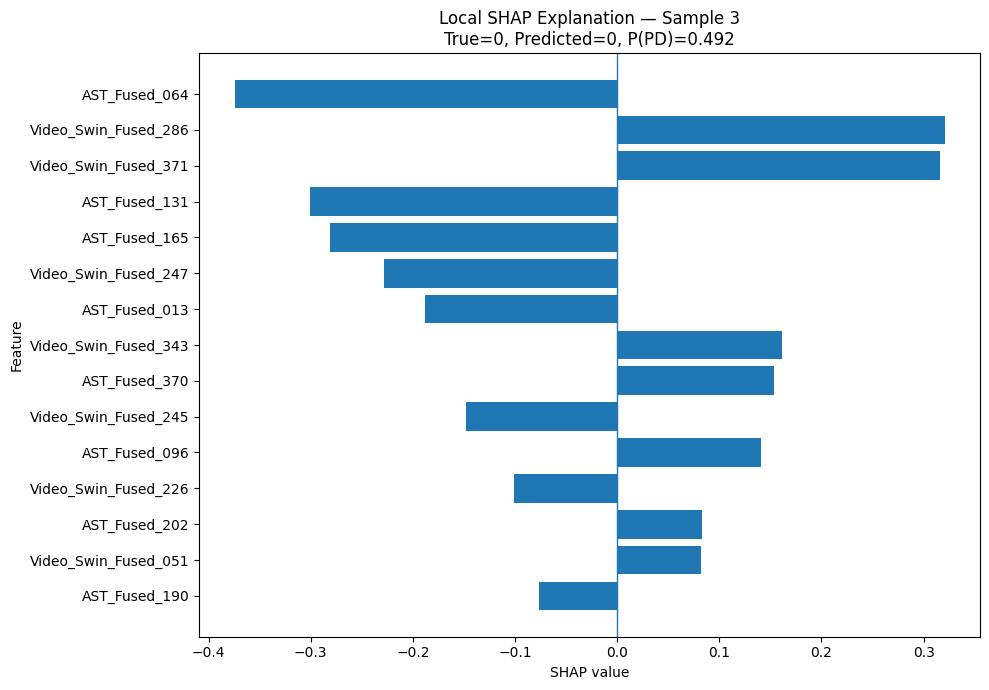

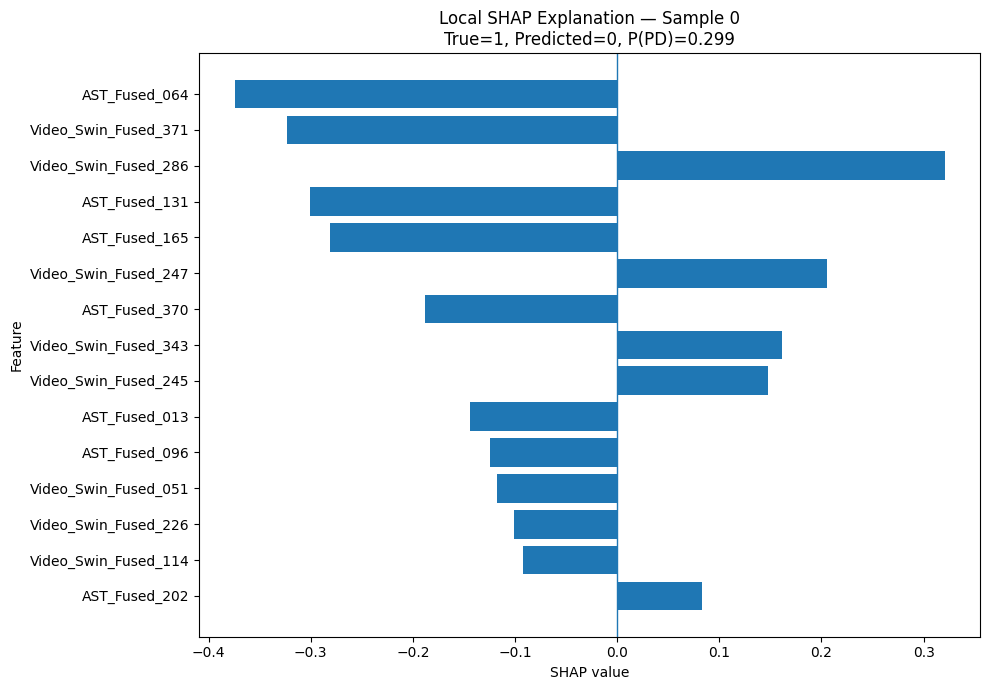

,sample_name,sample_index,true_label,predicted_label,pd_probability,video_abs_shap,audio_abs_shap,video_percentage,audio_percentage
0,Correct_Parkinson,1,1,1,0.6232,1.6251,1.6271,49.969002,50.030998
1,Correct_Control,3,0,0,0.4920,1.6150,1.6575,49.349899,50.650101
2,Misclassified,0,1,0,0.2986,1.6489,1.6317,50.260700,49.739300



Generating force plots...
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability/local_explanations/sample_01_Correct_Parkinson_force_plot.html
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability/local_explanations/sample_03_Correct_Control_force_plot.html
✓ /content/drive/MyDrive/ParkinsonDataset/Module 2/moduleTwoResults/step5_shap_explainability/local_explanations/sample_00_Misclassified_force_plot.html

Generating SHAP decision plots...
Decision plot generation failed: NameError: name 'representative_samples' is not defined


SHAP-GUIDED VIDEO TOKEN ATTRIBUTION

Sample 1:
Tokens: 784
Inferred grid: (8, 7, 14)


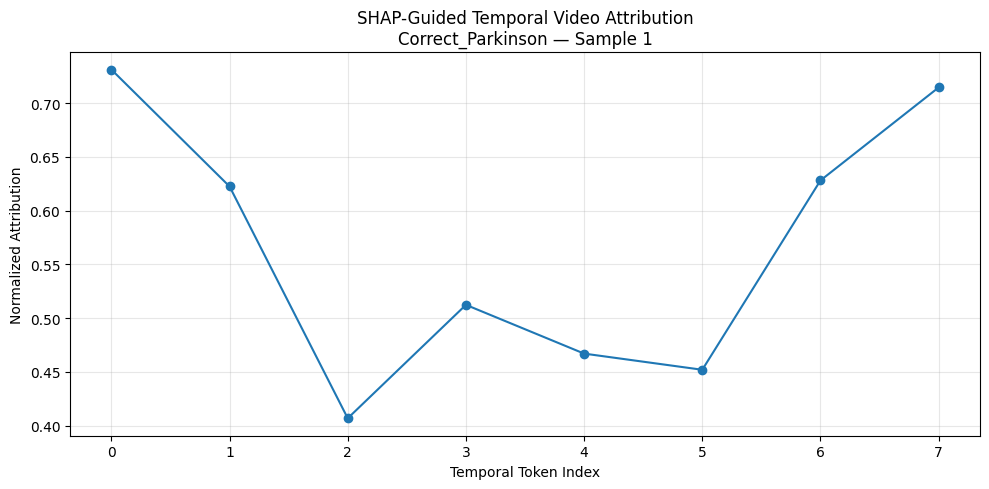

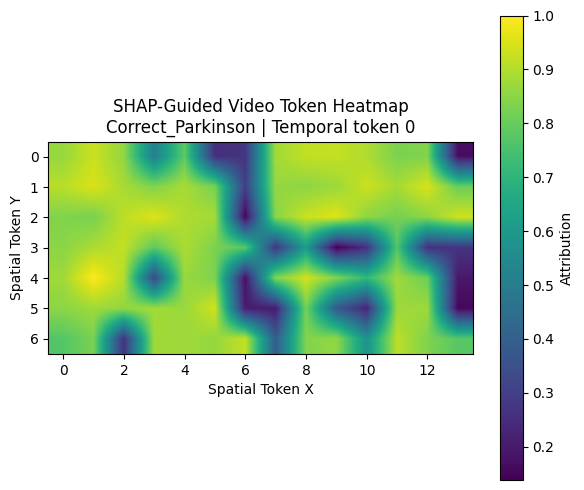

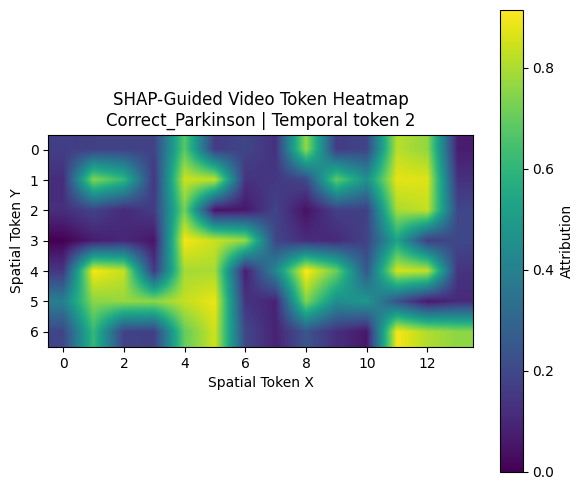

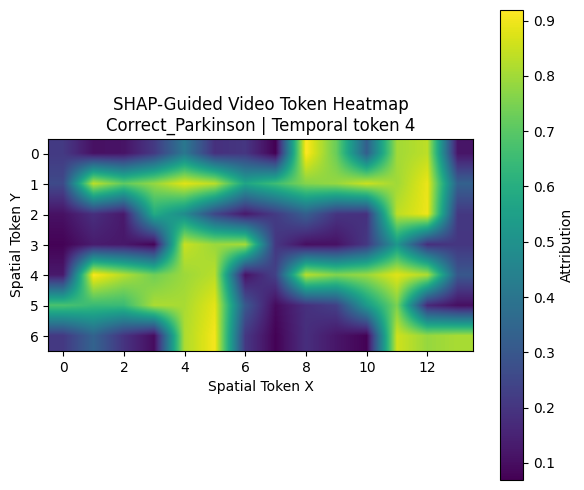

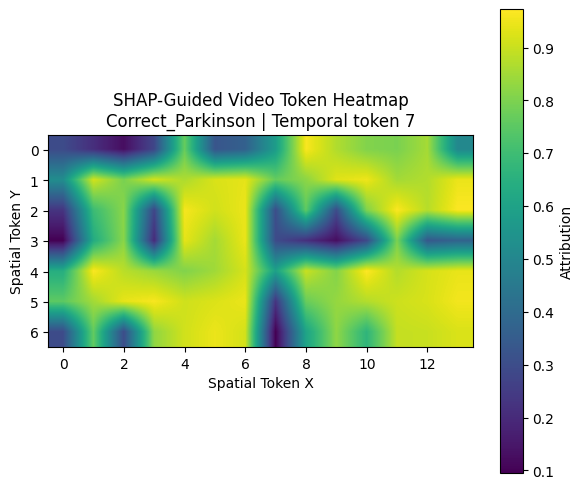


Sample 3:
Tokens: 784
Inferred grid: (8, 7, 14)


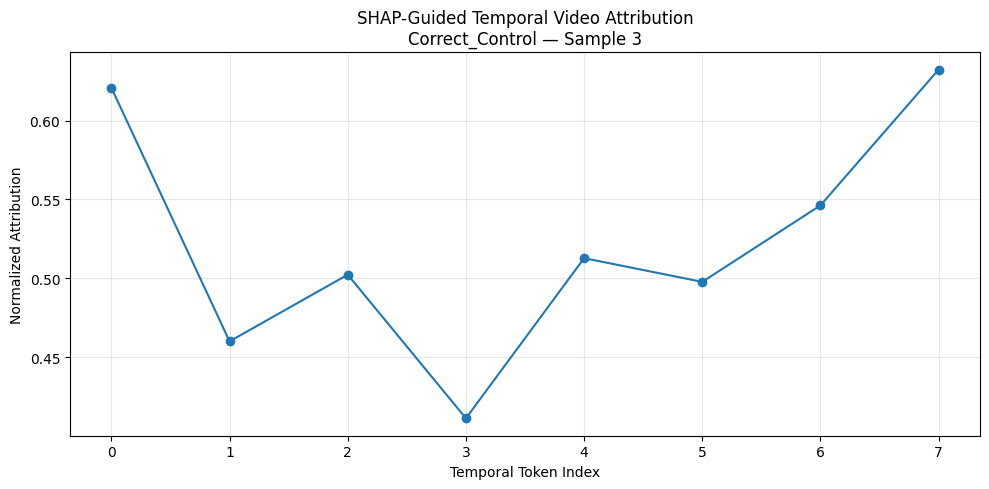

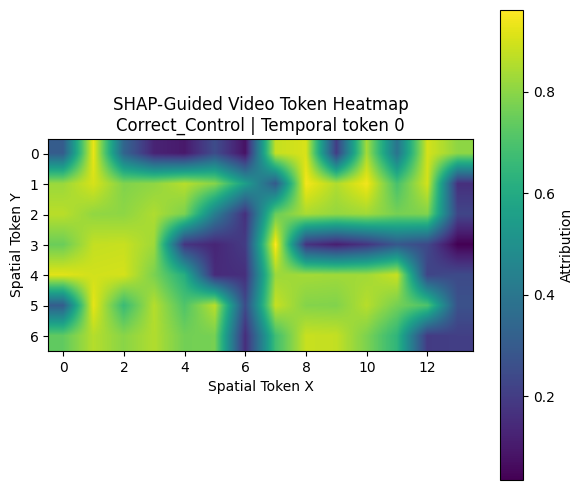

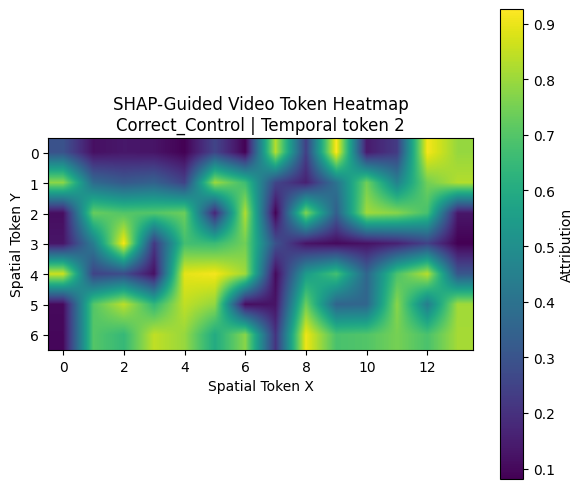

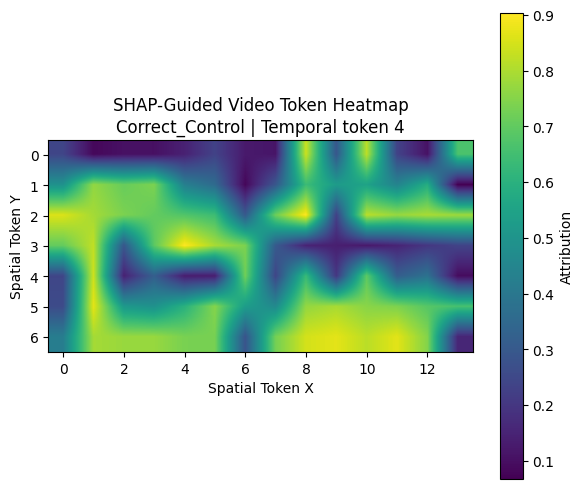

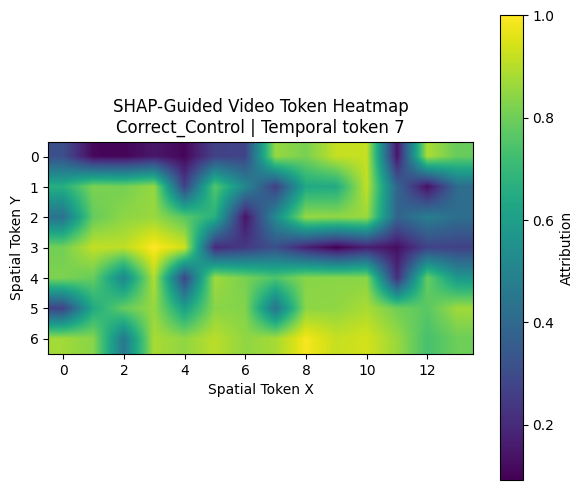


Sample 0:
Tokens: 784
Inferred grid: (8, 7, 14)


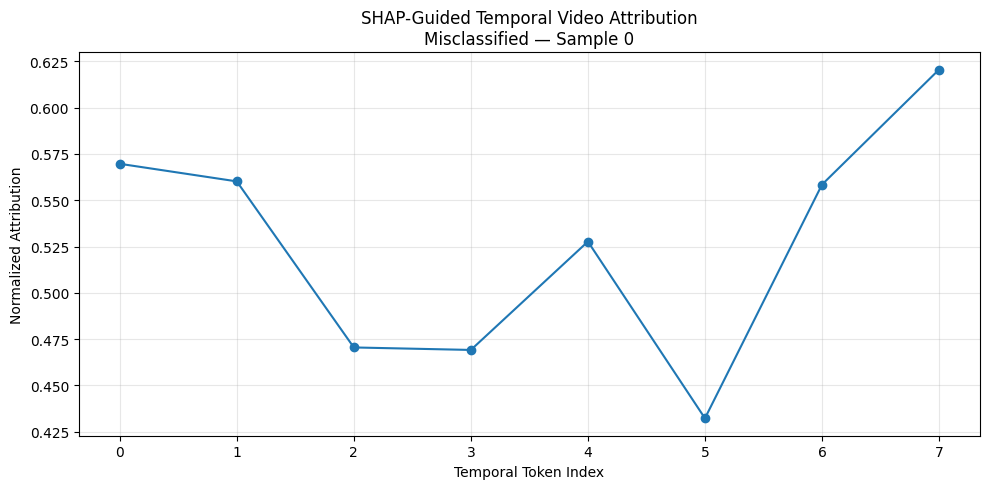

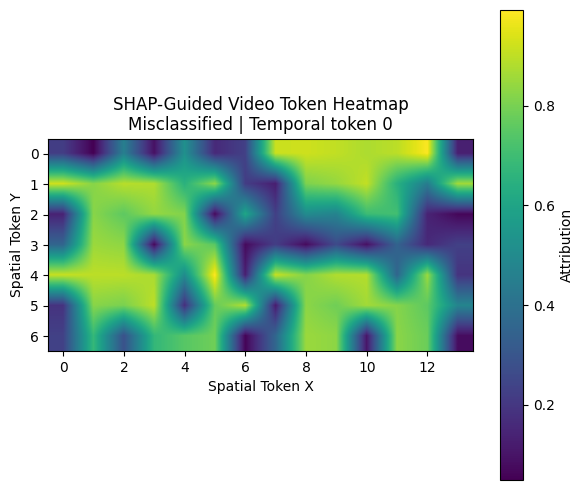

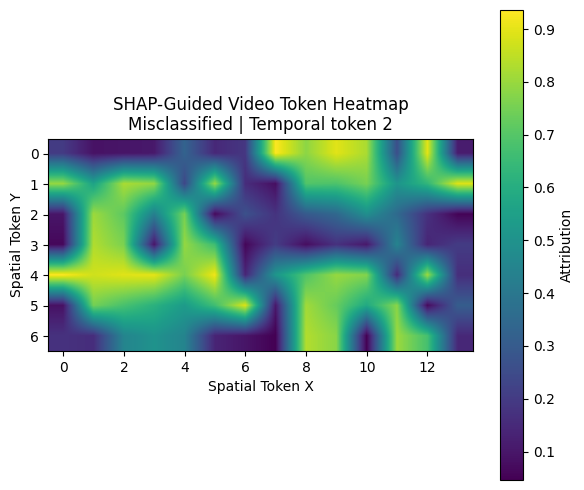

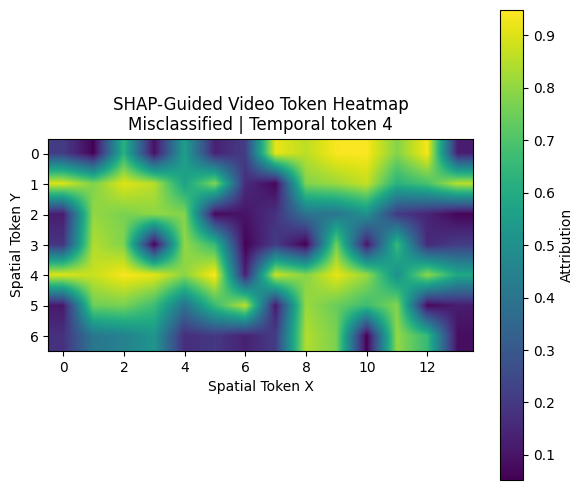

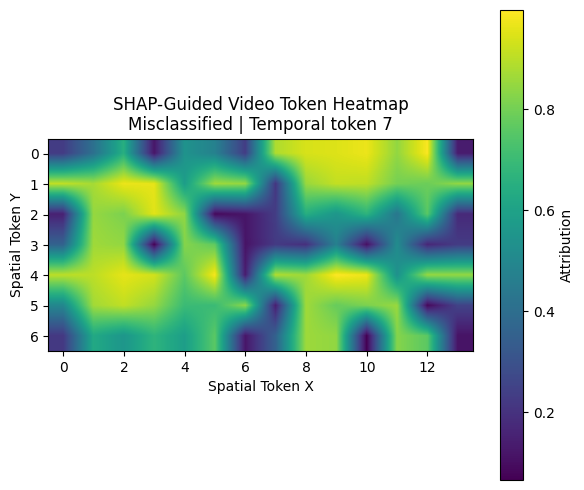

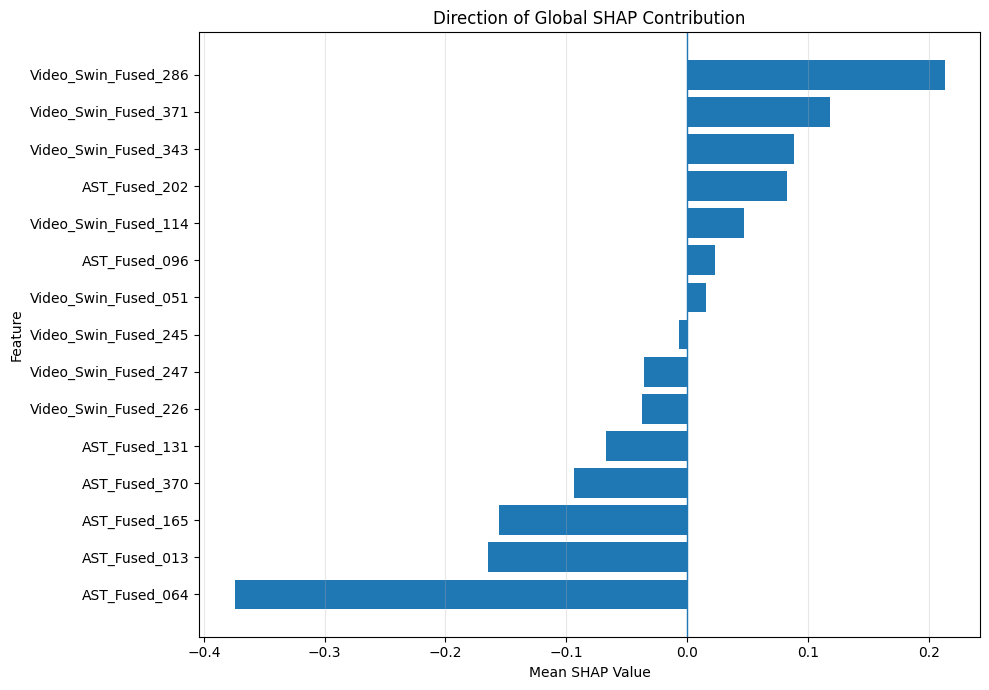


Top SHAP features — Control


,feature,mean_abs_shap,class,rank
0,AST_Fused_064,0.374580,Control,1
1,Video_Swin_Fused_286,0.320836,Control,2
2,AST_Fused_131,0.298408,Control,3
3,AST_Fused_165,0.236829,Control,4
4,Video_Swin_Fused_371,0.227901,Control,5
5,Video_Swin_Fused_247,0.222273,Control,6
6,Video_Swin_Fused_343,0.188948,Control,7
7,AST_Fused_013,0.182296,Control,8
8,AST_Fused_370,0.175451,Control,9
9,AST_Fused_096,0.136723,Control,10



Top SHAP features — Parkinsons


,feature,mean_abs_shap,class,rank
0,AST_Fused_064,0.374580,Parkinsons,1
1,Video_Swin_Fused_286,0.321051,Parkinsons,2
2,AST_Fused_131,0.303062,Parkinsons,3
3,Video_Swin_Fused_371,0.299885,Parkinsons,4
4,AST_Fused_165,0.265286,Parkinsons,5
5,Video_Swin_Fused_247,0.214475,Parkinsons,6
6,AST_Fused_370,0.181496,Parkinsons,7
7,Video_Swin_Fused_343,0.172265,Parkinsons,8
8,AST_Fused_013,0.170277,Parkinsons,9
9,Video_Swin_Fused_245,0.134225,Parkinsons,10


In [ ]:
# ================================================================
# COMPLETE SHAP EXPLAINABILITY ANALYSIS
#
# Architecture:
# Video Swin + AST + Bidirectional Cross-Attention + XGBoost

# XAI:
# 1. TreeSHAP global bar summary
# 2. TreeSHAP beeswarm
# 3. Local SHAP explanations
# 4. Modality-attributed SHAP
# 5. SHAP-guided Video Swin token attribution
# 6. Video token heatmaps
#
# IMPORTANT:
# TreeSHAP directly explains the XGBoost fused latent features.
# The visual heatmap is therefore called:
# "SHAP-guided visual attribution"
# and NOT direct pixel-level TreeSHAP.
# ================================================================


# ================================================================
# 0. INSTALL / IMPORT
# ================================================================

!pip -q install shap xgboost

import os
import json
import random
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import shap
import xgboost as xgb

from IPython.display import display, Image

warnings.filterwarnings("ignore")


# ================================================================
# 1. PATHS
# ================================================================

BASE_DIR = (
    "/content/drive/MyDrive/ParkinsonDataset/Module 2"
)

# ------------------------------------------------
# Cached features
# ------------------------------------------------

CACHE_DIR = os.path.join(
    BASE_DIR,
    "04_step2_optuna_optimized",
    "cached_features"
)

# ------------------------------------------------
# EXACT FIRST-RUN REPRODUCTION CHECKPOINTS
#
# These correspond to your reported:
# Accuracy = 0.8333
# AUROC    = 0.8625
# ------------------------------------------------

FIRST_RUN_DIR = os.path.join(
    BASE_DIR,
    "04_step2_first_run_reproduction"
)

FUSION_CHECKPOINT = os.path.join(
    FIRST_RUN_DIR,
    "best_fusion_model_first_run_reproduction.pt"
)

XGB_CHECKPOINT = os.path.join(
    FIRST_RUN_DIR,
    "best_xgboost_model_first_run_reproduction.json"
)

# ------------------------------------------------
# Output
# ------------------------------------------------

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "moduleTwoResults",
    "step5_shap_explainability"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    os.path.join(
        OUTPUT_DIR,
        "plots"
    ),
    exist_ok=True
)

os.makedirs(
    os.path.join(
        OUTPUT_DIR,
        "local_explanations"
    ),
    exist_ok=True
)

os.makedirs(
    os.path.join(
        OUTPUT_DIR,
        "modality_analysis"
    ),
    exist_ok=True
)

os.makedirs(
    os.path.join(
        OUTPUT_DIR,
        "visual_attribution"
    ),
    exist_ok=True
)


print("=" * 75)
print("MODULE 2 — STEP 5 SHAP EXPLAINABILITY")
print("=" * 75)

print("\nFusion checkpoint:")
print(FUSION_CHECKPOINT)

print("\nXGBoost checkpoint:")
print(XGB_CHECKPOINT)

print("\nOutput:")
print(OUTPUT_DIR)


# ================================================================
# 2. CHECK FILES
# ================================================================

required_files = [
    os.path.join(
        CACHE_DIR,
        "train_features.pt"
    ),
    os.path.join(
        CACHE_DIR,
        "validation_features.pt"
    ),
    os.path.join(
        CACHE_DIR,
        "test_features.pt"
    ),
    FUSION_CHECKPOINT,
    XGB_CHECKPOINT
]

print("\n")
print("=" * 75)
print("CHECKING REQUIRED FILES")
print("=" * 75)

for f in required_files:

    if os.path.exists(f):

        print("✓", f)

    else:

        print("✗ MISSING:", f)


missing = [
    f for f in required_files
    if not os.path.exists(f)
]

if len(missing) > 0:

    raise FileNotFoundError(
        "One or more required files are missing.\n"
        + "\n".join(missing)
    )


# ================================================================
# 3. DEVICE
# ================================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", device)


# ================================================================
# 4. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)


# ================================================================
# 5. LOAD FEATURE CACHE
# ================================================================

def load_feature_cache(path):

    print("\nLoading:", path)

    try:

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

    except TypeError:

        data = torch.load(
            path,
            map_location="cpu"
        )

    print(
        "Keys:",
        list(data.keys())
        if isinstance(data, dict)
        else type(data)
    )

    return data


train_cache = load_feature_cache(
    os.path.join(
        CACHE_DIR,
        "train_features.pt"
    )
)

val_cache = load_feature_cache(
    os.path.join(
        CACHE_DIR,
        "validation_features.pt"
    )
)

test_cache = load_feature_cache(
    os.path.join(
        CACHE_DIR,
        "test_features.pt"
    )
)


# ================================================================
# 6. FLEXIBLE CACHE EXTRACTION
# ================================================================

def get_first_key(
    dictionary,
    keys
):

    for key in keys:

        if key in dictionary:

            return dictionary[key]

    return None


def extract_features(
    data,
    split_name
):

    if not isinstance(data, dict):

        raise TypeError(
            f"{split_name} cache is not a dictionary."
        )

    video = get_first_key(
        data,
        [
            "video_tokens",
            "video_features",
            "video",
            "video_embedding"
        ]
    )

    audio = get_first_key(
        data,
        [
            "audio_tokens",
            "audio_features",
            "audio",
            "audio_embedding"
        ]
    )

    labels = get_first_key(
        data,
        [
            "labels",
            "label",
            "y",
            "targets"
        ]
    )

    if video is None:

        raise KeyError(
            f"No video feature key found in {split_name}"
        )

    if audio is None:

        raise KeyError(
            f"No audio feature key found in {split_name}"
        )

    if labels is None:

        raise KeyError(
            f"No label key found in {split_name}"
        )

    video = torch.as_tensor(
        video
    ).float()

    audio = torch.as_tensor(
        audio
    ).float()

    labels = torch.as_tensor(
        labels
    ).long().view(-1)

    print("\n", split_name)
    print("-" * 50)
    print("Video:", tuple(video.shape))
    print("Audio:", tuple(audio.shape))
    print("Labels:", tuple(labels.shape))

    return (
        video,
        audio,
        labels
    )


(
    train_video,
    train_audio,
    y_train
) = extract_features(
    train_cache,
    "TRAIN"
)

(
    val_video,
    val_audio,
    y_val
) = extract_features(
    val_cache,
    "VALIDATION"
)

(
    test_video,
    test_audio,
    y_test
) = extract_features(
    test_cache,
    "TEST"
)


VIDEO_DIM = train_video.shape[-1]
AUDIO_DIM = train_audio.shape[-1]

print("\nFeature dimensions:")
print("Video:", VIDEO_DIM)
print("Audio:", AUDIO_DIM)


# ================================================================
# 7. BIDIRECTIONAL CROSS-ATTENTION MODEL
# ================================================================

class BidirectionalCrossAttention(
    nn.Module
):

    def __init__(
        self,
        video_dim,
        audio_dim,
        fusion_dim=384,
        num_heads=4,
        dropout=0.4
    ):

        super().__init__()

        self.video_proj = nn.Linear(
            video_dim,
            fusion_dim
        )

        self.audio_proj = nn.Linear(
            audio_dim,
            fusion_dim
        )

        self.video_to_audio = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.audio_to_video = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.video_norm = nn.LayerNorm(
            fusion_dim
        )

        self.audio_norm = nn.LayerNorm(
            fusion_dim
        )

        self.video_ffn = nn.Sequential(
            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.audio_ffn = nn.Sequential(
            nn.Linear(
                fusion_dim,
                fusion_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                fusion_dim * 2,
                fusion_dim
            )
        )

        self.final_video_norm = nn.LayerNorm(
            fusion_dim
        )

        self.final_audio_norm = nn.LayerNorm(
            fusion_dim
        )


    def forward(
        self,
        video,
        audio
    ):

        video = self.video_proj(
            video
        )

        audio = self.audio_proj(
            audio
        )

        # Video attends to audio
        video_attn, _ = self.video_to_audio(
            query=video,
            key=audio,
            value=audio
        )

        # Audio attends to video
        audio_attn, _ = self.audio_to_video(
            query=audio,
            key=video,
            value=video
        )

        video = self.video_norm(
            video + video_attn
        )

        audio = self.audio_norm(
            audio + audio_attn
        )

        video = self.final_video_norm(
            video +
            self.video_ffn(video)
        )

        audio = self.final_audio_norm(
            audio +
            self.audio_ffn(audio)
        )

        video_pool = video.mean(
            dim=1
        )

        audio_pool = audio.mean(
            dim=1
        )

        fused = torch.cat(
            [
                video_pool,
                audio_pool
            ],
            dim=1
        )

        return fused


# ================================================================
# 8. LOAD FUSION CHECKPOINT
# ================================================================

print("\n")
print("=" * 75)
print("LOADING FUSION CHECKPOINT")
print("=" * 75)

try:

    checkpoint = torch.load(
        FUSION_CHECKPOINT,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        FUSION_CHECKPOINT,
        map_location="cpu"
    )


print(
    "Checkpoint type:",
    type(checkpoint)
)

if isinstance(
    checkpoint,
    dict
):

    print(
        "Checkpoint keys:",
        list(checkpoint.keys())
    )


# ------------------------------------------------
# Determine state dict
# ------------------------------------------------

if isinstance(
    checkpoint,
    dict
):

    possible_state_keys = [
        "fusion_state_dict",
        "model_state_dict",
        "state_dict",
        "fusion_model_state_dict"
    ]

    fusion_state = None

    for key in possible_state_keys:

        if key in checkpoint:

            fusion_state = checkpoint[key]

            print(
                "Using state:",
                key
            )

            break

    if fusion_state is None:

        # If checkpoint itself appears to be a state dict
        if all(
            isinstance(v, torch.Tensor)
            for v in checkpoint.values()
        ):

            fusion_state = checkpoint

        else:

            raise KeyError(
                "Could not identify fusion state_dict."
            )

else:

    fusion_state = checkpoint


# ================================================================
# 9. INITIALIZE FUSION MODEL
# ================================================================

FUSION_DIM = 384
NUM_HEADS = 4
DROPOUT = 0.4

fusion_model = BidirectionalCrossAttention(
    video_dim=VIDEO_DIM,
    audio_dim=AUDIO_DIM,
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)


# ================================================================
# 10. CLEAN CHECKPOINT KEYS
# ================================================================

clean_state = {}

for key, value in fusion_state.items():

    new_key = key

    if new_key.startswith(
        "module."
    ):

        new_key = new_key[
            len("module.") :
        ]

    if new_key.startswith(
        "fusion_model."
    ):

        new_key = new_key[
            len("fusion_model.") :
        ]

    clean_state[new_key] = value


missing_keys, unexpected_keys = (
    fusion_model.load_state_dict(
        clean_state,
        strict=False
    )
)

print(
    "\nMissing keys:",
    missing_keys
)

print(
    "Unexpected keys:",
    unexpected_keys
)

fusion_model = fusion_model.to(
    device
)

fusion_model.eval()

print("\n✓ Fusion model loaded")


# ================================================================
# 11. LOAD XGBOOST
# ================================================================

print("\n")
print("=" * 75)
print("LOADING XGBOOST MODEL")
print("=" * 75)

xgb_model = xgb.XGBClassifier()

xgb_model.load_model(
    XGB_CHECKPOINT
)

print(
    "✓ XGBoost loaded"
)


# ================================================================
# 12. GENERATE FUSED REPRESENTATIONS
#
# IMPORTANT:
# We do not run Video Swin or AST again.
# We only run the saved cross-attention fusion network.
# ================================================================

@torch.no_grad()
def generate_fused_features(
    video,
    audio
):

    fused = fusion_model(
        video.to(device),
        audio.to(device)
    )

    return fused.cpu().numpy()


print("\nGenerating fused representations...")


X_train = generate_fused_features(
    train_video,
    train_audio
)

X_val = generate_fused_features(
    val_video,
    val_audio
)

X_test = generate_fused_features(
    test_video,
    test_audio
)


print("\nFused representations:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)



# ================================================================
# 14. FEATURE NAMES
#
# 384 Video features
# 384 Audio features
# Total = 768
# ================================================================

TOTAL_FEATURES = X_train.shape[1]

if TOTAL_FEATURES != 768:

    print(
        "\nWARNING:"
        f" Expected 768 fused features, "
        f"but found {TOTAL_FEATURES}."
    )

    VIDEO_FUSED_DIM = TOTAL_FEATURES // 2

else:

    VIDEO_FUSED_DIM = 384


AUDIO_FUSED_START = VIDEO_FUSED_DIM


feature_names = []

for i in range(
    VIDEO_FUSED_DIM
):

    feature_names.append(
        f"Video_Swin_Fused_{i+1:03d}"
    )

for i in range(
    TOTAL_FEATURES -
    VIDEO_FUSED_DIM
):

    feature_names.append(
        f"AST_Fused_{i+1:03d}"
    )


print(
    "\nTotal feature names:",
    len(feature_names)
)


# ================================================================
# 15. CREATE SHAP EXPLAINER
# ================================================================

print("\n")
print("=" * 75)
print("CREATING TREE SHAP EXPLAINER")
print("=" * 75)

explainer = shap.TreeExplainer(
    xgb_model
)

print("✓ TreeExplainer created")


# ================================================================
# 16. CALCULATE SHAP VALUES
# ================================================================

print("\nCalculating SHAP values...")

shap_raw = explainer.shap_values(
    X_test
)


# ------------------------------------------------
# Handle different SHAP versions
# ------------------------------------------------

if isinstance(
    shap_raw,
    list
):

    # Binary XGBoost
    if len(shap_raw) == 2:

        shap_values = shap_raw[1]

    else:

        shap_values = shap_raw[0]

else:

    shap_values = np.asarray(
        shap_raw
    )


shap_values = np.asarray(
    shap_values
)

print(
    "SHAP shape:",
    shap_values.shape
)


# ================================================================
# 17. SAVE RAW SHAP VALUES
# ================================================================

shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names
)

shap_df.insert(
    0,
    "sample_index",
    np.arange(len(X_test))
)

shap_df.insert(
    1,
    "true_label",
    y_test.numpy()
)

shap_df.insert(
    2,
    "predicted_label",
    test_pred
)

shap_df.insert(
    3,
    "prediction_probability",
    test_prob
)

shap_csv = os.path.join(
    OUTPUT_DIR,
    "shap_values_test.csv"
)

shap_df.to_csv(
    shap_csv,
    index=False
)

print(
    "\n✓ Saved:",
    shap_csv
)


# ================================================================
# 18. GLOBAL SHAP IMPORTANCE
# ================================================================

mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

mean_signed_shap = np.mean(
    shap_values,
    axis=0
)

global_importance = pd.DataFrame(
    {
        "feature": feature_names,

        "mean_abs_shap":
            mean_abs_shap,

        "mean_signed_shap":
            mean_signed_shap
    }
)

global_importance = (
    global_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

global_importance[
    "rank"
] = np.arange(
    1,
    len(global_importance) + 1
)

global_csv = os.path.join(
    OUTPUT_DIR,
    "global_shap_feature_importance.csv"
)

global_importance.to_csv(
    global_csv,
    index=False
)

print(
    "\nTop 20 SHAP features:"
)

display(
    global_importance.head(
        20
    )
)


# ================================================================
# 19. SHAP BAR SUMMARY PLOT
# ================================================================

print("\nGenerating SHAP bar summary...")

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "Global SHAP Feature Importance\n"
    "Optimized XGBoost"
)

plt.tight_layout()

bar_path = os.path.join(
    OUTPUT_DIR,
    "plots",
    "shap_global_bar_summary.png"
)

plt.savefig(
    bar_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "✓ Saved:",
    bar_path
)


# ================================================================
# 20. SHAP BEESWARM
# ================================================================

print("\nGenerating SHAP beeswarm...")

plt.figure(
    figsize=(11, 9)
)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Beeswarm Plot\n"
    "Optimized XGBoost"
)

plt.tight_layout()

beeswarm_path = os.path.join(
    OUTPUT_DIR,
    "plots",
    "shap_beeswarm.png"
)

plt.savefig(
    beeswarm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    "✓ Saved:",
    beeswarm_path
)


# ================================================================
# 21. TOP 20 FEATURE TABLE
# ================================================================

top20 = global_importance.head(
    20
).copy()

top20_path = os.path.join(
    OUTPUT_DIR,
    "top20_shap_features.csv"
)

top20.to_csv(
    top20_path,
    index=False
)

display(
    top20
)


# ================================================================
# 22. MODALITY-WISE SHAP
#
# Because cross-attention mixes information, this is NOT a
# literal decomposition of causal modality contribution.
#
# We describe it as:
# "modality-attributed SHAP importance"
# ================================================================

video_shap = shap_values[
    :,
    :VIDEO_FUSED_DIM
]

audio_shap = shap_values[
    :,
    VIDEO_FUSED_DIM:
]


video_abs = np.mean(
    np.abs(video_shap)
)

audio_abs = np.mean(
    np.abs(audio_shap)
)

total_abs = (
    video_abs +
    audio_abs
)

video_percentage = (
    video_abs /
    total_abs
) * 100

audio_percentage = (
    audio_abs /
    total_abs
) * 100


modality_df = pd.DataFrame(
    {
        "modality": [
            "Video Swin",
            "AST Audio"
        ],

        "mean_absolute_shap": [
            video_abs,
            audio_abs
        ],

        "relative_percentage": [
            video_percentage,
            audio_percentage
        ]
    }
)

modality_csv = os.path.join(
    OUTPUT_DIR,
    "modality_analysis",
    "modality_attributed_shap.csv"
)

modality_df.to_csv(
    modality_csv,
    index=False
)

print("\n")
print("=" * 75)
print("MODALITY-ATTRIBUTED SHAP")
print("=" * 75)

display(
    modality_df.round(4)
)


# ================================================================
# 23. MODALITY BAR PLOT
# ================================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    modality_df["modality"],
    modality_df["relative_percentage"]
)

plt.ylabel(
    "Relative SHAP Importance (%)"
)

plt.xlabel(
    "Modality"
)

plt.title(
    "Modality-Attributed SHAP Importance"
)

plt.ylim(
    0,
    max(
        modality_df[
            "relative_percentage"
        ]
    ) * 1.25
)

for i, value in enumerate(
    modality_df[
        "relative_percentage"
    ]
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

modality_plot = os.path.join(
    OUTPUT_DIR,
    "plots",
    "modality_attributed_shap.png"
)

plt.savefig(
    modality_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 24. TOP VIDEO FEATURES
# ================================================================

video_importance = global_importance[
    global_importance[
        "feature"
    ].str.startswith(
        "Video_Swin"
    )
].copy()

video_importance_path = os.path.join(
    OUTPUT_DIR,
    "modality_analysis",
    "video_swin_shap_importance.csv"
)

video_importance.to_csv(
    video_importance_path,
    index=False
)


# ================================================================
# 25. TOP AUDIO FEATURES
# ================================================================

audio_importance = global_importance[
    global_importance[
        "feature"
    ].str.startswith(
        "AST"
    )
].copy()

audio_importance_path = os.path.join(
    OUTPUT_DIR,
    "modality_analysis",
    "ast_shap_importance.csv"
)

audio_importance.to_csv(
    audio_importance_path,
    index=False
)


# ================================================================
# 26. LOCAL EXPLANATION FUNCTION
# ================================================================

def save_local_explanation(
    sample_index,
    shap_values,
    X,
    true_label,
    predicted_label,
    probability
):

    sample_shap = shap_values[
        sample_index
    ]

    sample_features = X[
        sample_index
    ]

    local_df = pd.DataFrame(
        {
            "feature":
                feature_names,

            "feature_value":
                sample_features,

            "shap_value":
                sample_shap,

            "abs_shap":
                np.abs(sample_shap)
        }
    )

    local_df = (
        local_df
        .sort_values(
            "abs_shap",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    local_df[
        "rank"
    ] = np.arange(
        1,
        len(local_df) + 1
    )

    filename = (
        f"sample_{sample_index:02d}"
        "_local_shap.csv"
    )

    local_path = os.path.join(
        OUTPUT_DIR,
        "local_explanations",
        filename
    )

    local_df.to_csv(
        local_path,
        index=False
    )

    # ------------------------------------------------------------
    # Local bar plot
    # ------------------------------------------------------------

    top_local = local_df.head(
        15
    ).iloc[::-1]

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        top_local["feature"],
        top_local["shap_value"]
    )

    plt.xlabel(
        "SHAP value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Local SHAP Explanation — "
        f"Sample {sample_index}\n"
        f"True={true_label}, "
        f"Predicted={predicted_label}, "
        f"P(PD)={probability:.3f}"
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.tight_layout()

    plot_path = os.path.join(
        OUTPUT_DIR,
        "local_explanations",
        f"sample_{sample_index:02d}_local_bar.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return local_df


# ================================================================
# 27. IDENTIFY REPRESENTATIVE TEST SAMPLES
#
# Correct PD
# Correct Control
# Optional misclassified case
# ================================================================

true_labels = y_test.numpy()

correct_pd = np.where(
    (true_labels == 1) &
    (test_pred == 1)
)[0]

correct_control = np.where(
    (true_labels == 0) &
    (test_pred == 0)
)[0]

misclassified = np.where(
    true_labels != test_pred
)[0]


selected_samples = []

if len(correct_pd) > 0:

    selected_samples.append(
        (
            "Correct_Parkinson",
            correct_pd[0]
        )
    )

if len(correct_control) > 0:

    selected_samples.append(
        (
            "Correct_Control",
            correct_control[0]
        )
    )

if len(misclassified) > 0:

    selected_samples.append(
        (
            "Misclassified",
            misclassified[0]
        )
    )


print("\n")
print("=" * 75)
print("REPRESENTATIVE SAMPLES")
print("=" * 75)

for name, idx in selected_samples:

    print(
        f"{name}: "
        f"sample {idx}, "
        f"true={true_labels[idx]}, "
        f"pred={test_pred[idx]}, "
        f"P(PD)={test_prob[idx]:.4f}"
    )


# ================================================================
# 28. LOCAL SHAP ANALYSIS
# ================================================================

local_records = []

for sample_name, sample_idx in selected_samples:

    local_df = save_local_explanation(
        sample_idx,
        shap_values,
        X_test,
        int(true_labels[sample_idx]),
        int(test_pred[sample_idx]),
        float(test_prob[sample_idx])
    )

    # ------------------------------------------------------------
    # Modality contribution for sample
    # ------------------------------------------------------------

    video_local = np.sum(
        np.abs(
            shap_values[
                sample_idx,
                :VIDEO_FUSED_DIM
            ]
        )
    )

    audio_local = np.sum(
        np.abs(
            shap_values[
                sample_idx,
                VIDEO_FUSED_DIM:
            ]
        )
    )

    total_local = (
        video_local +
        audio_local
    )

    local_records.append(
        {
            "sample_name":
                sample_name,

            "sample_index":
                sample_idx,

            "true_label":
                int(
                    true_labels[
                        sample_idx
                    ]
                ),

            "predicted_label":
                int(
                    test_pred[
                        sample_idx
                    ]
                ),

            "pd_probability":
                float(
                    test_prob[
                        sample_idx
                    ]
                ),

            "video_abs_shap":
                video_local,

            "audio_abs_shap":
                audio_local,

            "video_percentage":
                100 *
                video_local /
                total_local,

            "audio_percentage":
                100 *
                audio_local /
                total_local
        }
    )


local_modality_df = pd.DataFrame(
    local_records
)

local_modality_path = os.path.join(
    OUTPUT_DIR,
    "local_explanations",
    "local_modality_attribution.csv"
)

local_modality_df.to_csv(
    local_modality_path,
    index=False
)

display(
    local_modality_df.round(4)
)


# ================================================================
# 29. SHAP FORCE PLOTS
# ================================================================

print("\nGenerating force plots...")

# SHAP force plots are saved as standalone HTML files.

expected_value = explainer.expected_value

if isinstance(
    expected_value,
    np.ndarray
):

    if expected_value.size > 1:

        expected_value = expected_value[1]

    else:

        expected_value = expected_value.item()


for sample_name, sample_idx in selected_samples:

    force = shap.force_plot(
        expected_value,
        shap_values[
            sample_idx
        ],
        X_test[
            sample_idx
        ],
        feature_names=feature_names,
        matplotlib=False
    )

    force_path = os.path.join(
        OUTPUT_DIR,
        "local_explanations",
        f"sample_{sample_idx:02d}_"
        f"{sample_name}_force_plot.html"
    )

    shap.save_html(
        force_path,
        force
    )

    print(
        "✓",
        force_path
    )


# ================================================================
# 30. SHAP DECISION PLOT
# ================================================================
# ============================================================
# DECISION PLOT — FIXED FOR CURRENT SHAP VERSION
# ============================================================

print("\nGenerating SHAP decision plots...")

try:
    for sample_idx, sample_name in representative_samples.items():

        sample_x = X_test[sample_idx]
        sample_shap = shap_values_for_class[sample_idx]

        # ----------------------------------------------------
        # Select top 20 SHAP features manually
        # ----------------------------------------------------
        top_indices = np.argsort(
            np.abs(sample_shap)
        )[::-1][:20]

        # Sort indices for stable feature ordering
        top_indices = np.sort(top_indices)

        top_shap = sample_shap[top_indices]
        top_x = sample_x[top_indices]
        top_names = [
            feature_names[i]
            for i in top_indices
        ]

        # ----------------------------------------------------
        # Decision plot
        # IMPORTANT:
        # Do NOT use max_display.
        # Older/newer SHAP versions may reject it.
        # ----------------------------------------------------
        plt.figure(figsize=(14, 8))

        shap.decision_plot(
            expected_value,
            top_shap,
            features=top_x,
            feature_names=top_names,
            show=False
        )

        plt.title(
            f"SHAP Decision Plot - {sample_name}"
        )

        plt.tight_layout()

        output_path = os.path.join(
            DECISION_PLOT_DIR,
            f"{sample_idx:02d}_{sample_name}_decision_plot.png"
        )

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        print(
            f"Saved decision plot: {output_path}"
        )

except Exception as e:

    print(
        f"Decision plot generation failed: {type(e).__name__}: {e}"
    )

# ================================================================
# 31. SAMPLE-WISE MODALITY ATTRIBUTION
# ================================================================

sample_modality = []

for i in range(
    len(X_test)
):

    video_value = np.sum(
        np.abs(
            shap_values[
                i,
                :VIDEO_FUSED_DIM
            ]
        )
    )

    audio_value = np.sum(
        np.abs(
            shap_values[
                i,
                VIDEO_FUSED_DIM:
            ]
        )
    )

    total = (
        video_value +
        audio_value
    )

    sample_modality.append(
        {
            "sample_index": i,

            "true_label":
                int(true_labels[i]),

            "predicted_label":
                int(test_pred[i]),

            "pd_probability":
                float(test_prob[i]),

            "video_abs_shap":
                video_value,

            "audio_abs_shap":
                audio_value,

            "video_percentage":
                100 * video_value / total,

            "audio_percentage":
                100 * audio_value / total
        }
    )


sample_modality_df = pd.DataFrame(
    sample_modality
)

sample_modality_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "modality_analysis",
        "sample_wise_modality_shap.csv"
    ),
    index=False
)


# ================================================================
# 32. SHAP-GUIDED VIDEO TOKEN ATTRIBUTION
#
# IMPORTANT:
#
# TreeSHAP explains the final XGBoost fused dimensions.
#
# We cannot directly say:
#
# "TreeSHAP feature 100 = pixel (x,y)"
#
# because cross-attention transforms and mixes the video tokens.
#
# Instead:
#
# 1. Select the Video-Swin portion of SHAP.
# 2. Weight the learned fusion representation using those SHAP values.
# 3. Backpropagate through the cross-attention fusion model.
# 4. Obtain token-level attribution.
#
# This is therefore called:
#
# SHAP-GUIDED VISUAL ATTRIBUTION
#
# rather than direct TreeSHAP pixel attribution.
# ================================================================


def shap_guided_video_attribution(
    sample_index
):

    fusion_model.eval()

    video_input = (
        test_video[
            sample_index:
            sample_index + 1
        ]
        .clone()
        .to(device)
    )

    audio_input = (
        test_audio[
            sample_index:
            sample_index + 1
        ]
        .clone()
        .to(device)
    )

    video_input.requires_grad_(True)

    # ------------------------------------------------------------
    # Forward through fusion model
    # ------------------------------------------------------------

    fused = fusion_model(
        video_input,
        audio_input
    )

    # ------------------------------------------------------------
    # Video portion of TreeSHAP
    # ------------------------------------------------------------

    sample_shap = torch.tensor(
        shap_values[
            sample_index,
            :VIDEO_FUSED_DIM
        ],
        dtype=torch.float32,
        device=device
    )

    # ------------------------------------------------------------
    # SHAP-weighted video representation
    #
    # The scalar is a surrogate that asks:
    # which video tokens influence the fused dimensions that
    # TreeSHAP identified as important?
    # ------------------------------------------------------------

    video_fused = fused[
        :,
        :VIDEO_FUSED_DIM
    ]

    scalar = torch.sum(
        video_fused *
        sample_shap.unsqueeze(0)
    )

    fusion_model.zero_grad(
        set_to_none=True
    )

    scalar.backward()

    # ------------------------------------------------------------
    # Gradient wrt original cached Video-Swin tokens
    # ------------------------------------------------------------

    gradient = (
        video_input.grad
    )

    if gradient is None:

        raise RuntimeError(
            "No gradient obtained from video features."
        )

    # ------------------------------------------------------------
    # Token attribution
    # ------------------------------------------------------------

    token_attr = (
        gradient *
        video_input
    )

    token_attr = token_attr.detach().cpu()

    # Shape:
    # [1, N_tokens, D]
    #
    # or possibly:
    # [1, T, H, W, D]
    #
    # depending on cache.

    token_attr = token_attr.squeeze(0)

    if token_attr.ndim == 1:

        token_scores = (
            token_attr.abs()
        )

    elif token_attr.ndim == 2:

        token_scores = (
            token_attr.abs()
            .mean(dim=-1)
        )

    else:

        token_scores = (
            token_attr.abs()
            .flatten(
                start_dim=0,
                end_dim=-2
            )
            .mean(dim=-1)
        )

    token_scores = token_scores.numpy()

    # Normalize
    token_scores = (
        token_scores -
        token_scores.min()
    )

    if token_scores.max() > 0:

        token_scores = (
            token_scores /
            token_scores.max()
        )

    return token_scores


# ================================================================
# 33. DETERMINE TOKEN GRID
# ================================================================

def factorize_tokens(
    n
):

    # Find reasonable T,H,W
    # for Video Swin token count.

    candidates = []

    for t in range(
        1,
        min(n, 32) + 1
    ):

        if n % t != 0:
            continue

        remaining = n // t

        for h in range(
            1,
            int(
                np.sqrt(
                    remaining
                )
            ) + 1
        ):

            if remaining % h != 0:
                continue

            w = remaining // h

            candidates.append(
                (
                    t,
                    h,
                    w
                )
            )

    # Prefer a video-like temporal dimension
    # and spatial dimensions around 7 x 14.

    preferred = sorted(
        candidates,
        key=lambda x:
            (
                abs(x[1] - 7) +
                abs(x[2] - 14)
            )
    )

    return preferred[0]


# ================================================================
# 34. CREATE TOKEN HEATMAPS
# ================================================================

print("\n")
print("=" * 75)
print("SHAP-GUIDED VIDEO TOKEN ATTRIBUTION")
print("=" * 75)

visual_records = []

for sample_name, sample_idx in selected_samples:

    try:

        scores = shap_guided_video_attribution(
            sample_idx
        )

        n_tokens = len(
            scores
        )

        t_dim, h_dim, w_dim = factorize_tokens(
            n_tokens
        )

        print(
            f"\nSample {sample_idx}:"
        )

        print(
            "Tokens:",
            n_tokens
        )

        print(
            "Inferred grid:",
            (
                t_dim,
                h_dim,
                w_dim
            )
        )

        # --------------------------------------------------------
        # Reshape
        # --------------------------------------------------------

        heatmap = scores.reshape(
            t_dim,
            h_dim,
            w_dim
        )

        # --------------------------------------------------------
        # Save temporal mean
        # --------------------------------------------------------

        temporal_mean = heatmap.mean(
            axis=(1, 2)
        )

        for frame_idx, value in enumerate(
            temporal_mean
        ):

            visual_records.append(
                {
                    "sample_name":
                        sample_name,

                    "sample_index":
                        sample_idx,

                    "temporal_token_index":
                        frame_idx,

                    "mean_attribution":
                        float(value)
                }
            )

        # --------------------------------------------------------
        # Plot temporal importance
        # --------------------------------------------------------

        plt.figure(
            figsize=(10, 5)
        )

        plt.plot(
            np.arange(t_dim),
            temporal_mean,
            marker="o"
        )

        plt.xlabel(
            "Temporal Token Index"
        )

        plt.ylabel(
            "Normalized Attribution"
        )

        plt.title(
            f"SHAP-Guided Temporal Video Attribution\n"
            f"{sample_name} — Sample {sample_idx}"
        )

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        temporal_path = os.path.join(
            OUTPUT_DIR,
            "visual_attribution",
            f"sample_{sample_idx:02d}_"
            f"temporal_attribution.png"
        )

        plt.savefig(
            temporal_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

        # --------------------------------------------------------
        # Spatial heatmaps
        # --------------------------------------------------------

        selected_t = np.linspace(
            0,
            t_dim - 1,
            min(
                4,
                t_dim
            )
        ).astype(int)

        for t_idx in selected_t:

            plt.figure(
                figsize=(6, 5)
            )

            plt.imshow(
                heatmap[
                    t_idx
                ],
                interpolation="bilinear"
            )

            plt.colorbar(
                label="Attribution"
            )

            plt.title(
                f"SHAP-Guided Video Token Heatmap\n"
                f"{sample_name} | "
                f"Temporal token {t_idx}"
            )

            plt.xlabel(
                "Spatial Token X"
            )

            plt.ylabel(
                "Spatial Token Y"
            )

            plt.tight_layout()

            heatmap_path = os.path.join(
                OUTPUT_DIR,
                "visual_attribution",
                f"sample_{sample_idx:02d}_"
                f"token_heatmap_{t_idx:02d}.png"
            )

            plt.savefig(
                heatmap_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

            plt.close()

    except Exception as e:

        print(
            f"\nVisual attribution failed "
            f"for sample {sample_idx}:"
        )

        print(
            repr(e)
        )


# ================================================================
# 35. SAVE TEMPORAL ATTRIBUTION
# ================================================================

if len(
    visual_records
) > 0:

    visual_df = pd.DataFrame(
        visual_records
    )

    visual_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "visual_attribution",
            "temporal_video_attribution.csv"
        ),
        index=False
    )


# ================================================================
# 36. SHAP SIGN ANALYSIS
#
# Positive SHAP:
# pushes prediction toward Parkinson's / class 1.
#
# Negative SHAP:
# pushes prediction toward control / class 0.
# ================================================================

positive_shap = np.where(
    shap_values > 0,
    shap_values,
    0
)

negative_shap = np.where(
    shap_values < 0,
    shap_values,
    0
)

positive_importance = np.mean(
    positive_shap,
    axis=0
)

negative_importance = np.mean(
    negative_shap,
    axis=0
)

direction_df = pd.DataFrame(
    {
        "feature":
            feature_names,

        "mean_positive_shap":
            positive_importance,

        "mean_negative_shap":
            negative_importance,

        "mean_signed_shap":
            mean_signed_shap,

        "mean_absolute_shap":
            mean_abs_shap
    }
).sort_values(
    "mean_absolute_shap",
    ascending=False
)

direction_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "shap_direction_analysis.csv"
    ),
    index=False
)


# ================================================================
# 37. TOP FEATURES PUSHING TOWARD PARKINSON'S
# ================================================================

toward_pd = (
    direction_df
    .sort_values(
        "mean_positive_shap",
        ascending=False
    )
    .head(20)
)

toward_pd.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top_features_toward_parkinsons.csv"
    ),
    index=False
)


# ================================================================
# 38. TOP FEATURES PUSHING TOWARD CONTROL
# ================================================================

toward_control = (
    direction_df
    .sort_values(
        "mean_negative_shap",
        ascending=True
    )
    .head(20)
)

toward_control.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top_features_toward_control.csv"
    ),
    index=False
)


# ================================================================
# 39. SHAP DIRECTION PLOT
# ================================================================

top_direction = (
    direction_df
    .head(15)
    .sort_values(
        "mean_signed_shap"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_direction[
        "feature"
    ],
    top_direction[
        "mean_signed_shap"
    ]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Mean SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Direction of Global SHAP Contribution"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

direction_plot = os.path.join(
    OUTPUT_DIR,
    "plots",
    "shap_direction_plot.png"
)

plt.savefig(
    direction_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 40. CLASS-WISE SHAP ANALYSIS
# ================================================================

class_results = []

for class_value, class_name in [
    (0, "Control"),
    (1, "Parkinsons")
]:

    indices = np.where(
        true_labels ==
        class_value
    )[0]

    if len(indices) == 0:
        continue

    class_shap = shap_values[
        indices
    ]

    class_importance = np.mean(
        np.abs(class_shap),
        axis=0
    )

    class_df = pd.DataFrame(
        {
            "feature":
                feature_names,

            "mean_abs_shap":
                class_importance,

            "class":
                class_name
        }
    )

    class_df = (
        class_df
        .sort_values(
            "mean_abs_shap",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    class_df[
        "rank"
    ] = np.arange(
        1,
        len(class_df) + 1
    )

    class_path = os.path.join(
        OUTPUT_DIR,
        f"class_{class_value}_"
        f"{class_name.lower()}_shap.csv"
    )

    class_df.to_csv(
        class_path,
        index=False
    )

    print(
        f"\nTop SHAP features — {class_name}"
    )

    display(
        class_df.head(10)
    )


# ================================================================
# 41. SUMMARY JSON
# ================================================================

summary = {

    "experiment": {

        "architecture":
            "Video Swin + AST + "
            "Bidirectional Cross-Attention + XGBoost",

        "dataset":
            "YouTube",

        "test_samples":
            int(len(X_test)),

        "reported_accuracy":
            0.8333333333,

        "reported_auroc":
            0.8625,

        "checkpoint_accuracy":
            float(test_acc),

        "checkpoint_auroc":
            float(test_auc)
    },

    "test_metrics": {

        "accuracy":
            float(test_acc),

        "precision":
            float(test_precision),

        "recall":
            float(test_recall),

        "f1":
            float(test_f1),

        "fpr":
            float(test_fpr),

        "auroc":
            float(test_auc)
    },

    "shap": {

        "number_of_features":
            int(TOTAL_FEATURES),

        "video_fused_features":
            int(VIDEO_FUSED_DIM),

        "audio_fused_features":
            int(
                TOTAL_FEATURES -
                VIDEO_FUSED_DIM
            ),

        "method":
            "TreeSHAP"
    },

    "modality_attribution": {

        "video_swin_percentage":
            float(video_percentage),

        "ast_audio_percentage":
            float(audio_percentage)
    },

    "representative_samples": [
        {
            "name": name,
            "index": int(idx),
            "true_label":
                int(true_labels[idx]),
            "predicted_label":
                int(test_pred[idx]),
            "pd_probability":
                float(test_prob[idx])
        }
        for name, idx
        in selected_samples
    ],

    "visual_method":
        "SHAP-guided gradient attribution "
        "over cached Video Swin tokens"
}


summary_path = os.path.join(
    OUTPUT_DIR,
    "shap_analysis_summary.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

